# Building Agentic Knowledge Graphs for 40 Million Documents
### Provenance-Enforced Retrieval: Grounded Answers at Scale, or None at All

A single, end-to-end, **fully-local** agentic knowledge-graph pipeline on one
**NVIDIA H100 80GB**. We go from the raw PubMed baseline → a 929-million-edge
knowledge graph → an agent that **traverses**, **cites a path**, **verifies every
claim**, and **refuses** when no path supports the answer — then we *measure* each
layer separately against expert-curated ground truth.

**The core idea.** You cannot make a generative model *never* hallucinate. You *can*
build a system in which every emitted claim resolves to a traversable path in a
curated graph, and which **refuses** otherwise. That converts hallucination into
abstention — a safe, measurable failure mode.

**Why this is not just GraphRAG.** Microsoft's GraphRAG costs ~**$33,000** in LLM
calls to index a *single* dataset, ~75% of it graph extraction. That is why every
GraphRAG demo stops at a few thousand documents. We build the graph with **zero LLM
calls** — every edge is a field NLM already published — so the graph becomes
affordable at 40M documents. The graph is what makes refusal *enforceable* rather
than *hoped for*.

**What is deliberately NOT claimed.** We do not claim "zero hallucination"; that is
unfalsifiable. We claim enforced attribution with honest abstention, and we report
the price of the gate alongside its benefit. Section 13 contains a **negative
result** that bounds the claim further.

## 0 · Setup, GPU/VRAM check & global config

**Theory.** On a single GPU, VRAM is a hard budget, not a runtime surprise. This
notebook is *artifact-driven*: every expensive stage (50 GiB download, 40M-record
parse, 28M-abstract embedding) writes checkpoints, and re-running loads them in
milliseconds. That is what makes a 40M-document pipeline something you can iterate
on rather than something you run once and pray over. Every knob lives in one
papermill `parameters` cell so headless runs are reproducible; `SMOKE_TEST` shrinks
the whole pipeline so code paths can be validated before spending GPU time.

In [1]:
SMOKE_TEST = False           # tiny end-to-end run to catch code errors cheaply

# paths (all artifacts live under DATA_DIR)
DATA_DIR = "/mnt/data"
RAW_DIR = "/mnt/data/raw"
PQ_DIR = "/mnt/data/parquet"
GRAPH_DIR = "/mnt/data/graph"
EMB_DIR = "/mnt/data/emb"
EVAL_DIR = "/mnt/data/eval"
OUT_DIR = "/mnt/data/out"

# models (all local, no API calls)
EMBED_MODEL = "BAAI/bge-small-en-v1.5"      # 384-dim, chosen by measurement (§11)
VERIFIER_BASE = "cross-encoder/nli-deberta-v3-base"
VERIFIER_TUNED = "/mnt/data/models/scifact-verifier"

# corpus
PUBMED_FILES = 1334          # 2026 annual baseline
EMBED_MAXLEN = 512
EMBED_BATCH = 768
EMBED_WORKERS = 12

# graph / agent knobs
MAX_SEED = 1200              # articles sampled per concept when bridging
MAX_PATHS = 200              # candidate paths per question
# min_paths shipped at 3 by intuition. Two curves have since moved it:
#   16.7  k=3 answers 16.8% of IMPOSSIBLE questions; k=8 cuts that to 6.9%
#   19.2  with hybrid grounding the MARGIN (coverage - leak) peaks at k=12
# The value is set by the curve, not by taste, and it changed twice as the
# evidence changed. That is the intended behaviour.
MIN_PATHS = 12               # refusal gate: fewer usable paths than this -> refuse
TAU_NEUTRAL = 0.90           # gate 6: neutrality above this = unsupported (§12)
CHECK_TAG_MAX = 1_500_000    # descriptors above this many articles are check tags

SEED = 42

In [2]:
# ---- resolve the SMOKE profile: one place that shrinks everything ------------
import os
from pathlib import Path

if SMOKE_TEST:
    PUBMED_FILES = 12
    MAX_SEED = 200
    MAX_PATHS = 40

for d in (OUT_DIR, f"{OUT_DIR}/figures"):
    Path(d).mkdir(parents=True, exist_ok=True)

os.environ.setdefault("HF_HOME", f"{DATA_DIR}/hf")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")   # see §11: fork deadlock

print(f"profile={'SMOKE' if SMOKE_TEST else 'FULL'}  files={PUBMED_FILES}  "
      f"artifacts={DATA_DIR}")

profile=FULL  files=1334  artifacts=/mnt/data


In [3]:
# ---- imports + determinism ---------------------------------------------------
import gzip
import json
import random
import re
import subprocess
import time
from collections import Counter
from dataclasses import dataclass, field, asdict

import numpy as np


def set_determinism(seed: int) -> None:
    """Seed every RNG we touch so runs are reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    except Exception:
        pass


set_determinism(SEED)
print(f"determinism seeded @ {SEED}")

determinism seeded @ 42


In [4]:
# ---- GPU / VRAM probes -------------------------------------------------------
def _smi(query: str) -> list:
    out = subprocess.run(
        ["nvidia-smi", f"--query-gpu={query}", "--format=csv,noheader,nounits"],
        capture_output=True, text=True, check=True).stdout.strip()
    return [x.strip() for x in out.splitlines()]


def gpu_report() -> dict:
    """Return GPU name / memory / driver and assert we are on an 80GB H100."""
    try:
        rep = {"name": _smi("name")[0],
               "total_gb": round(float(_smi("memory.total")[0]) / 1024, 1),
               "free_gb": round(float(_smi("memory.free")[0]) / 1024, 1),
               "driver": _smi("driver_version")[0]}
    except Exception as e:
        print(f"[gpu] nvidia-smi unavailable ({e}); are you on the GPU VM?")
        return {}
    print(json.dumps(rep, indent=2))
    if not SMOKE_TEST:
        assert "H100" in rep["name"], f"expected H100, got {rep['name']}"
        assert rep["total_gb"] >= 79, f"expected ~80GB, got {rep['total_gb']}"
    return rep


def vram_snapshot(tag: str) -> dict:
    """Log GPU-wide and kernel-only VRAM after a load step."""
    kernel = float("nan")
    try:
        import torch
        if torch.cuda.is_available():
            kernel = round(torch.cuda.memory_allocated() / 1024**3, 2)
    except Exception:
        pass
    used = round(float(_smi("memory.used")[0]) / 1024, 2)
    print(f"[vram] {tag:22} gpu_used={used}GB  kernel={kernel}GB")
    return {"tag": tag, "gpu_used_gb": used, "kernel_gb": kernel}


GPU = gpu_report()

{
  "name": "NVIDIA H100 PCIe",
  "total_gb": 79.6,
  "free_gb": 79.2,
  "driver": "570.195.03"
}


**Note the driver: `570.195.03` = CUDA 12.8.** This is not cosmetic. The current
PyTorch and vLLM wheels are built for **CUDA 13** (`libcudart.so.13`) and import
cleanly but report `torch.cuda.is_available() == False`, or fail at first use. The
cu128 wheel index tops out at **torch 2.11.0**, so the entire stack is pinned there.
A mixed cu12/cu13 environment produces a *silent* failure, which is the worst kind.

In [5]:
import torch

print(f"  torch          {torch.__version__}")
print(f"  cuda available {torch.cuda.is_available()}")
assert torch.cuda.is_available(), "CUDA unavailable - check the cu128 pin"
p = torch.cuda.get_device_properties(0)
print(f"  device         {p.name}  sm{p.major}{p.minor}  "
      f"{p.total_memory/1024**3:.1f} GiB  {p.multi_processor_count} SMs")

# prove the GPU actually computes, rather than merely reporting itself present
x = torch.randn(8192, 8192, device="cuda", dtype=torch.float16)
torch.cuda.synchronize()
_t = time.time()
for _ in range(30):
    y = x @ x
torch.cuda.synchronize()
_dt = time.time() - _t
print(f"  fp16 matmul    {30*2*8192**3/_dt/1e12:.1f} TFLOP/s")
del x, y
torch.cuda.empty_cache()

  torch          2.11.0+cu128
  cuda available True
  device         NVIDIA H100 PCIe  sm90  79.2 GiB  114 SMs


  fp16 matmul    195.1 TFLOP/s


## 1 · The corpus: PubMed 2026 baseline

**Theory.** The corpus choice is the architecture. We need (a) tens of millions of
real documents, free and bulk-downloadable with no login, (b) **native curated
edges** so the graph needs zero LLM extraction, and (c) independent expert ground
truth for *every layer* we intend to claim — entity, retrieval, answer, abstention,
verifier. PubMed is the only corpus that satisfies all three simultaneously.

One correction we make loudly, because it is a thesis-level fact: **MEDLINE MeSH
indexing has been machine-assigned since mid-2022** (NLM's MTIA), with human
curation narrowed to genes/proteins, ambiguity cases and trials. So the honest
claim is **"curated, non-generative, versioned"** — a frozen, auditable classifier
resolving into a curated ontology — *not* "human-curated". The genuinely
NLM-curated edge families are the **MeSH tree hierarchy**, the **citation links**,
and **CommentsCorrections** (retractions, errata, expressions of concern).

In [6]:
import glob

files = sorted(glob.glob(f"{RAW_DIR}/pubmed/pubmed26n*.xml.gz"))
total_gb = sum(os.path.getsize(f) for f in files) / 1024**3
print(f"[corpus] baseline files present : {len(files)} / {PUBMED_FILES}")
print(f"[corpus] compressed on disk     : {total_gb:.1f} GiB")
print(f"[corpus] mean file size         : {total_gb*1024/max(len(files),1):.1f} MiB")
missing = [i for i in range(1, PUBMED_FILES + 1)
           if f"{RAW_DIR}/pubmed/pubmed26n{i:04d}.xml.gz" not in set(files)]
print(f"[corpus] missing                : {missing if missing else 'none'}")

[corpus] baseline files present : 1334 / 1334
[corpus] compressed on disk     : 50.5 GiB
[corpus] mean file size         : 38.8 MiB
[corpus] missing                : none


In [7]:
# ---- peek at one record: everything we will build the graph from is visible here
from lxml import etree

with gzip.open(files[0], "rb") as fh:
    for _, art in etree.iterparse(fh, events=("end",), tag="PubmedArticle"):
        pmid = art.findtext(".//MedlineCitation/PMID")
        title = (art.findtext(".//Article/ArticleTitle") or "")[:72]
        mesh = [(d.get("UI"), d.get("MajorTopicYN"), d.text)
                for d in art.findall(".//MeshHeadingList/MeshHeading/DescriptorName")]
        refs = art.findall(".//ReferenceList//Reference//ArticleId[@IdType='pubmed']")
        cc = [(c.get("RefType"), c.findtext("PMID"))
              for c in art.findall(".//CommentsCorrectionsList/CommentsCorrections")]
        print(f"  PMID          : {pmid}")
        print(f"  Title         : {title}...")
        print(f"  Has abstract  : {art.find('.//Article/Abstract/AbstractText') is not None}")
        print(f"  MeSH headings : {len(mesh)}")
        for ui, major, name in mesh[:5]:
            print(f"      {ui}  major={major}  {name}")
        print(f"  PubMed refs   : {len(refs)}")
        print(f"  Corrections   : {cc if cc else 'none'}")
        break

  PMID          : 1
  Title         : Formate assay in body fluids: application in methanol poisoning....
  Has abstract  : False
  MeSH headings : 12
      D000445  major=N  Aldehyde Oxidoreductases
      D000818  major=N  Animals
      D001826  major=N  Body Fluids
      D002245  major=N  Carbon Dioxide
      D005561  major=N  Formates
  PubMed refs   : 0
  Corrections   : none


Every field above is published by NLM. **No model produced any of it.** The MeSH
headings become the entity layer, the `Reference/ArticleId[@IdType="pubmed"]`
entries become the citation edges, and `CommentsCorrections` becomes the
supersession layer that makes the retraction gate real rather than synthetic.

One subtlety worth stating: PubMed only records a reference when NLM has already
**resolved it to a PMID**. The edges arrive pre-resolved by the curator — which is
why, in §4, in-corpus citation retention turns out to be 100%.

## 1b · Acquiring the data — every byte, reproducibly

**Theory.** A notebook that starts from a pre-built artifact is a demo, not a
pipeline. This section is the real acquisition path: five sources, all free, all
bulk, **none requiring a login or a licence agreement**. That last constraint did
real work — it eliminated UMLS, SemMedDB, DrugBank and DisGeNET, which between
them hold most of the "rich" biomedical relations. A reader who cannot run the
cell cannot check the claim, so a licence gate is a correctness problem, not an
inconvenience.

| source | what it provides | size | licence |
|---|---|---|---|
| PubMed 2026 baseline | 40M records: MeSH, citations, corrections | 50.5 GiB | public, no login |
| MeSH `desc2026` | 31,110 descriptors + tree + allowable pairs | 16 MiB | public |
| MeSH `qual2026` | 76 qualifiers | 0.3 MiB | public |
| MeSH `supp2026` | 324,046 supplementary concepts | 45 MiB | public |
| eval sets | PubMedQA · SciFact · MedREQAL · BEIR · BC5CDR | ~90 MiB | mixed, see §1c |

**On being a good citizen.** The first download attempt used 12 parallel jobs × 4
connections = 48 concurrent requests and NCBI returned **HTTP 503** after 58 files.
That was our fault, not theirs. The fetcher below uses 4 connections total with
backoff, and loops until every file is present.

In [8]:
import subprocess

BASE = "https://ftp.ncbi.nlm.nih.gov/pubmed/baseline"
MESH_BASE = "https://nlmpubs.nlm.nih.gov/projects/mesh/MESH_FILES/xmlmesh"

FETCH = r"""#!/bin/bash
# Polite, resumable PubMed baseline fetcher.
#   * 4 concurrent connections total (NCBI 503s well below the naive setting)
#   * recomputes the MISSING set each pass, so it resumes after any interruption
#   * loops until complete - a spot VM can vanish mid-download
DIR=%s
BASE=%s
mkdir -p "$DIR"
for attempt in $(seq 1 40); do
  python3 - <<PY
import os
missing = []
for i in range(1, %d + 1):
    n = f"pubmed26n{i:04d}.xml.gz"
    p = os.path.join("$DIR", n)
    if (not os.path.exists(p)) or os.path.getsize(p) < 1_000_000:
        missing.append(f"$BASE/{n}\n  dir=$DIR\n")
open("$DIR/missing.txt", "w").writelines(missing)
print(f"pass $attempt: {len(missing)} files missing")
PY
  N=$(grep -c '^https' "$DIR/missing.txt" || echo 0)
  [ "$N" -eq 0 ] && { echo "ALL PRESENT"; break; }
  aria2c -i "$DIR/missing.txt" -j 4 -x 1 -s 1 --continue=true \
         --auto-file-renaming=false --max-tries=5 --retry-wait=10 \
         --console-log-level=error --summary-interval=0
  sleep 15
done
""" % (f"{RAW_DIR}/pubmed", BASE, PUBMED_FILES)

script = Path(f"{DATA_DIR}/fetch_pubmed.sh")
script.write_text(FETCH)
script.chmod(0o755)
print(f"[fetch] wrote {script}")
print(f"[fetch] 4 concurrent connections, resumable, loops until complete")


def ensure_corpus():
    """Idempotent: returns immediately if the corpus is already complete."""
    have = sorted(glob.glob(f"{RAW_DIR}/pubmed/pubmed26n*.xml.gz"))
    have = [f for f in have if os.path.getsize(f) > 1_000_000]
    if len(have) >= PUBMED_FILES:
        gb = sum(os.path.getsize(f) for f in have) / 1024**3
        print(f"[fetch] corpus already complete: {len(have)} files, {gb:.1f} GiB")
        return have
    print(f"[fetch] {PUBMED_FILES - len(have)} files missing - running fetcher "
          f"(this takes ~9 min on a good link)")
    subprocess.run([str(script)], check=False)
    return sorted(glob.glob(f"{RAW_DIR}/pubmed/pubmed26n*.xml.gz"))


files = ensure_corpus()

[fetch] wrote /mnt/data/fetch_pubmed.sh
[fetch] 4 concurrent connections, resumable, loops until complete
[fetch] corpus already complete: 1334 files, 50.5 GiB


In [9]:
# ---- MeSH: three files, small, no login --------------------------------------
def ensure_mesh():
    out = {}
    Path(f"{RAW_DIR}/mesh").mkdir(parents=True, exist_ok=True)
    for fn in ("desc2026.gz", "qual2026.xml", "supp2026.gz"):
        p = f"{RAW_DIR}/mesh/{fn}"
        if not os.path.exists(p):
            subprocess.run(["curl", "-sS", "-o", p, f"{MESH_BASE}/{fn}"], check=False)
        out[fn] = os.path.getsize(p) / 1024**2
    return out


for fn, mb in ensure_mesh().items():
    print(f"[mesh] {fn:<16} {mb:>7.1f} MiB")

[mesh] desc2026.gz         16.0 MiB
[mesh] qual2026.xml         0.3 MiB
[mesh] supp2026.gz         45.1 MiB


In [10]:
# ---- integrity: never trust a download you have not checked ------------------
def verify_corpus(sample_n=10):
    total = sum(os.path.getsize(f) for f in files)
    idx = set(os.path.basename(f) for f in files)
    missing = [i for i in range(1, PUBMED_FILES + 1)
               if f"pubmed26n{i:04d}.xml.gz" not in idx]
    print(f"  files          {len(files)} / {PUBMED_FILES}")
    print(f"  total          {total/1024**3:.1f} GiB")
    print(f"  missing        {missing if missing else 'none'}")
    bad = []
    step = max(1, len(files) // sample_n)
    for f in files[::step][:sample_n]:
        if subprocess.run(["gzip", "-t", f], capture_output=True).returncode != 0:
            bad.append(f)
    print(f"  gzip-checked   {min(sample_n, len(files))} sampled files, "
          f"{len(bad)} corrupt")
    assert not missing and not bad, "corpus incomplete or corrupt"
    return total


CORPUS_BYTES = verify_corpus()
print("\n  corpus verified")

  files          1334 / 1334
  total          50.5 GiB
  missing        none


  gzip-checked   10 sampled files, 0 corrupt

  corpus verified


## 1c · The evaluation stack — and the loaders that no longer work

**Theory.** Our claim spans five layers (entity, retrieval, answer, abstention,
verifier), so we need independent expert ground truth for each. The obstacle was
not availability — it was that **`datasets>=4.5` removed dataset scripts**, which
silently killed a large fraction of the canonical HuggingFace paths for biomedical
benchmarks. Every one of these raised `RuntimeError: Dataset scripts are no longer
supported`:

```
allenai/scifact           bigbio/bioasq_task_b        bigbio/bc5cdr
allenai/scifact_entailment                            hpi-dhc/MedREQAL (404)
```

The fix is direct downloads, and the working sources are recorded below so the
notebook does not rot the next time a loader is deprecated.

In [11]:
EVAL_SOURCES = [
    ("PubMedQA expert", "answer", "HF qiaojin/PubMedQA:pqa_labeled", "1,000", "MIT"),
    ("PubMedQA artificial", "answer", "HF qiaojin/PubMedQA:pqa_artificial", "211,269", "MIT"),
    ("MedMCQA", "answer", "HF openlifescienceai/medmcqa", "193,155", "Apache-2.0"),
    ("SciFact", "verifier", "S3 scifact.s3-us-west-2.../data.tar.gz", "1,409 claims", "CC BY-NC 2.0"),
    ("MedREQAL", "abstention", "HF lavita/MedREQAL", "2,786", "research"),
    ("BEIR NFCorpus", "retrieval", "HF BeIR/nfcorpus", "3,633", "open"),
    ("BEIR TREC-COVID", "retrieval", "HF BeIR/trec-covid", "171,332", "agreement"),
    ("BC5CDR", "entity", "FTP ncbi.nlm.nih.gov/pub/lu/BC5CDR", "1,500 abstracts", "public domain"),
]
print(f"  {'dataset':<22}{'layer':<12}{'rows':>14}  licence")
print("  " + "-" * 72)
for name, layer, src, rows, lic in EVAL_SOURCES:
    print(f"  {name:<22}{layer:<12}{rows:>14}  {lic}")
print("\n  LICENCE FLAG: SciFact is CC BY-NC 2.0 - fine for this notebook and for a")
print("  research claim, NOT fine inside a commercial product. That distinction")
print("  belongs in the manifest, not in a footnote.")

  dataset               layer                 rows  licence
  ------------------------------------------------------------------------
  PubMedQA expert       answer               1,000  MIT
  PubMedQA artificial   answer             211,269  MIT
  MedMCQA               answer             193,155  Apache-2.0
  SciFact               verifier      1,409 claims  CC BY-NC 2.0
  MedREQAL              abstention           2,786  research
  BEIR NFCorpus         retrieval            3,633  open
  BEIR TREC-COVID       retrieval          171,332  agreement
  BC5CDR                entity      1,500 abstracts  public domain

  LICENCE FLAG: SciFact is CC BY-NC 2.0 - fine for this notebook and for a
  research claim, NOT fine inside a commercial product. That distinction
  belongs in the manifest, not in a footnote.


In [12]:
# ---- what actually landed ----------------------------------------------------
for d in sorted(glob.glob(f"{EVAL_DIR}/*")):
    if os.path.isdir(d):
        n = sum(os.path.getsize(os.path.join(r, f))
                for r, _, fs in os.walk(d) for f in fs) / 1024**2
        print(f"  {os.path.basename(d):<28} {n:>8.1f} MiB")

  PubMedQA_expert                   2.0 MiB
  data                              9.3 MiB


## 2 · Parse 40M records into columnar edge tables

**Theory.** This is the step Microsoft pays $33,000 for, and it is the whole thesis.
We do it with `lxml.iterparse` + `elem.clear()` and one OS process per file — the
1,334 baseline files are independent, so this scales near-linearly across 26 cores.
Six edge families come out, and **not one of them is inferred by a model**:

| table | edge | source field |
|---|---|---|
| `mesh_edges` | `Article --ANNOTATED_AS--> MeSHDescriptor` | `MeshHeadingList` |
| `citations` | `Article --CITES--> Article` | `Reference/ArticleId[pubmed]` |
| `corrections` | `Article --RETRACTED_BY/ERRATUM_FOR--> Article` | `CommentsCorrectionsList` |
| `chemicals` | `Article --HAS_SUBSTANCE--> Chemical` | `ChemicalList` |
| `pubtypes` | `Article --IS_A--> PublicationType` | `PublicationTypeList` |
| `articles` | node table | title/abstract/journal/year |

Memory stays flat regardless of file size because we clear each element *and* prune
its already-processed siblings — without the second step, `iterparse` still
accumulates the whole document.

In [13]:
def parse_stats():
    """Load the parse manifest produced by parse_pubmed.py (artifact-driven)."""
    import pyarrow.parquet as pq
    out = {}
    for t in ("articles", "mesh_edges", "citations", "corrections",
              "chemicals", "pubtypes"):
        fs = glob.glob(f"{PQ_DIR}/{t}/*.parquet")
        if not fs:
            continue
        rows = sum(pq.ParquetFile(f).metadata.num_rows for f in fs)
        size = sum(os.path.getsize(f) for f in fs) / 1024**3
        out[t] = (rows, size, len(fs))
    return out


st = parse_stats()
print(f"  {'table':<14}{'rows':>16}{'GiB':>9}{'shards':>9}")
print("  " + "-" * 48)
tot_rows = 0
for t, (rows, size, n) in st.items():
    tot_rows += rows
    print(f"  {t:<14}{rows:>16,}{size:>9.2f}{n:>9}")
print("  " + "-" * 48)
edges = sum(st[t][0] for t in st if t != "articles")
print(f"  {'NODES':<14}{st['articles'][0]:>16,}")
print(f"  {'EDGES':<14}{edges:>16,}")
print(f"\n  LLM calls used to build any of this: 0")

  table                     rows      GiB   shards
  ------------------------------------------------
  articles            39,994,988    15.43     1334
  mesh_edges         396,187,851     1.08     1334
  citations          397,733,440     1.62     1334
  corrections          2,977,437     0.02     1334
  chemicals           65,594,027     0.31     1334
  pubtypes            67,331,447     0.20     1334
  ------------------------------------------------
  NODES               39,994,988
  EDGES              929,824,202

  LLM calls used to build any of this: 0


**Measured on this box:** 1,334 files → **39,994,988 articles** and
**~929M edges in 10.8 minutes** at 61,449 records/sec, producing 18.7 GiB of
zstd-compressed Parquet. For comparison, the published GraphRAG figure is $33,000
of LLM calls for a *single, much smaller* dataset. The cost difference is not an
optimisation; it is a different architecture.

## 3 · The decision measurement: does multi-hop even exist?

**Theory.** A citation edge is only usable for traversal if **both endpoints are
inside the corpus we index**. This is the single most load-bearing number in the
whole design: if in-corpus retention is low, the graph is a hairball of dangling
stubs, multi-hop paths do not exist, and the traceability thesis dies quietly while
all the other metrics still look fine.

So we measure it *before* committing to an architecture — and we measure what a
smaller corpus would have cost us, because "use 10M documents" was the original
plan and it needed to be tested rather than assumed.

In [14]:
import duckdb

con = duckdb.connect()
con.execute("PRAGMA threads=26")
for t in ("articles", "citations", "mesh_edges", "corrections"):
    con.execute(f"CREATE OR REPLACE VIEW {t} AS "
                f"SELECT * FROM read_parquet('{PQ_DIR}/{t}/*.parquet')")

tot = con.execute("SELECT count(*) FROM citations").fetchone()[0]
ins = con.execute("""
    SELECT count(*) FROM citations c
    WHERE EXISTS (SELECT 1 FROM articles a WHERE a.pmid = c.cited_pmid)""").fetchone()[0]
print(f"  total citation edges       {tot:>14,}")
print(f"  cited_pmid inside corpus   {ins:>14,}   ({100*ins/tot:.1f}%)")
print(f"  dangling                   {tot-ins:>14,}   ({100*(tot-ins)/tot:.1f}%)")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  total citation edges          397,733,440
  cited_pmid inside corpus      397,731,791   (100.0%)
  dangling                            1,649   (0.0%)


In [15]:
# ---- what a smaller corpus would have cost -----------------------------------
print(f"  {'slice':<14}{'outbound':>14}{'induced':>14}{'retained':>10}{'MeSH cov':>10}")
print("  " + "-" * 62)
for n_slice in (5_000_000, 10_000_000, 20_000_000):
    con.execute(f"""CREATE OR REPLACE TEMP VIEW slice AS
                    SELECT pmid FROM articles ORDER BY year DESC NULLS LAST
                    LIMIT {n_slice}""")
    out_e, ind = con.execute("""
        SELECT (SELECT count(*) FROM citations c
                  WHERE EXISTS (SELECT 1 FROM slice s WHERE s.pmid=c.citing_pmid)),
               (SELECT count(*) FROM citations c
                  WHERE EXISTS (SELECT 1 FROM slice s1 WHERE s1.pmid=c.citing_pmid)
                    AND EXISTS (SELECT 1 FROM slice s2 WHERE s2.pmid=c.cited_pmid))
    """).fetchone()
    cov = con.execute("""SELECT avg((n_mesh>0)::int) FROM articles
                         WHERE pmid IN (SELECT pmid FROM slice)""").fetchone()[0]
    print(f"  recent {n_slice//1_000_000:>3}M{out_e:>14,}{ind:>14,}"
          f"{100*ind/max(out_e,1):>9.1f}%{100*cov:>9.1f}%")
print(f"  {'FULL 40M':<14}{tot:>14,}{ins:>14,}{100*ins/tot:>9.1f}%")

  slice               outbound       induced  retained  MeSH cov
  --------------------------------------------------------------


  recent   5M   106,790,051    11,178,083     10.5%     58.0%


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  recent  10M   207,161,067    58,130,371     28.1%     63.6%


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  recent  20M   344,441,335   212,602,515     61.7%     72.4%
  FULL 40M         397,733,440   397,731,791    100.0%


**This table is why the corpus is 40M and not 10M.** A recent-10M slice retains
only **28.1%** of its citation edges and drops MeSH coverage to 63.6%. We would
have built a graph of stubs and then measured its "refusal rate" without ever
discovering that the paths were missing. At the full corpus, retention is
**100.0%** — because, as noted in §1, PubMed only records references it has already
resolved to a PMID.

The era breakdown shows why no slice works: recent papers have abstracts and dense
citations but *sparse* MeSH (2024: 89% abstracts, 21.7 refs, only 61.8% MeSH —
indexing lag), while 1950s papers are the mirror image (98% MeSH, 0.4% abstracts).
**Only the full corpus has both layers.** Going bigger was necessity, not ambition.

In [16]:
rows = con.execute("""
    SELECT (year/10)*10 AS decade, count(*) n, avg((n_mesh>0)::int) mesh,
           avg(has_abstract::int) abst, avg(n_refs) refs
    FROM articles WHERE year BETWEEN 1950 AND 2026 GROUP BY 1 ORDER BY 1""").fetchall()
print(f"  {'decade':<9}{'articles':>12}{'MeSH%':>8}{'abstract%':>11}{'mean refs':>11}")
for d, n, m, a, r in rows[::10]:
    print(f"  {int(d):<9}{n:>12,}{100*m:>7.1f}%{100*a:>10.1f}%{r:>11.1f}")

  decade       articles   MeSH%  abstract%  mean refs
  1950           85,773   98.0%       0.4%        0.1
  1960          112,216   97.0%       1.1%        0.6
  1970          219,422   96.3%       4.1%        0.9
  1980          280,650   97.1%      46.0%        1.6
  1990          410,654   94.5%      69.9%        2.3
  2000          531,678   91.6%      76.4%        2.5
  2010          849,534   89.3%      84.7%       10.1
  2020        1,448,395   71.2%      86.9%       18.1


## 4 · MeSH: the ontology layer

**Theory.** MeSH is not "a vocabulary we picked" — it is a curated, versioned,
hierarchical thesaurus that every MEDLINE record is indexed against. It gives three
things no extraction pipeline can:

1. **`BROADER` edges** from the tree. Tree numbers are *dotted paths*
   (`C14.280.647.500`), so ancestry is an **O(1) string-prefix test**. The obvious
   move — recursive Datalog transitive closure — is orders of magnitude slower and
   buys nothing. Knowing when *not* to reason is part of the engineering.
2. **Allowable descriptor × qualifier pairs** — a hard schema. An edge outside that
   set is *provably* invalid. Cheaper and stronger than SHACL validation.
3. **Entry terms** — every synonym NLM recognises, which is how a free-text question
   is grounded onto graph entry points **deterministically**, rather than asking a
   model for an identifier it could hallucinate.

In [17]:
import pyarrow.parquet as pq

mesh_tbl = {t: pq.read_table(f"{PQ_DIR}/mesh_{t}/part.parquet").num_rows
            for t in ("descriptors", "tree", "broader", "allowable", "terms",
                      "qualifiers")}
for k, v in mesh_tbl.items():
    print(f"  mesh_{k:<12} {v:>9,}")

  mesh_descriptors     31,110
  mesh_tree            65,360
  mesh_broader         42,519
  mesh_allowable      633,885
  mesh_terms          267,012
  mesh_qualifiers          76


In [18]:
# ---- ancestry with no reasoner ----------------------------------------------
tree = pq.read_table(f"{PQ_DIR}/mesh_tree/part.parquet").to_pydict()
desc = pq.read_table(f"{PQ_DIR}/mesh_descriptors/part.parquet").to_pydict()
name_of = dict(zip(desc["ui"], desc["name"]))
tn2ui = dict(zip(tree["tree_number"], tree["ui"]))
ui2tn = {}
for ui, tn in zip(tree["ui"], tree["tree_number"]):
    ui2tn.setdefault(ui, []).append(tn)

probe = next(u for u, n in name_of.items() if n == "Myocardial Infarction")
tn = ui2tn[probe][0]
print(f"  '{name_of[probe]}' ({probe})  tree numbers: {ui2tn[probe]}")
print("  ancestry by STRING PREFIX - no graph walk, no Datalog:")
parts = tn.split(".")
for i in range(1, len(parts) + 1):
    anc = ".".join(parts[:i])
    if anc in tn2ui:
        print(f"      {anc:<20} {name_of.get(tn2ui[anc], '?')}")

  'Myocardial Infarction' (D009203)  tree numbers: ['C14.280.647.500', 'C14.907.585.500', 'C23.550.513.355.750', 'C23.550.717.489.750']
  ancestry by STRING PREFIX - no graph walk, no Datalog:
      C14                  Cardiovascular Diseases
      C14.280              Heart Diseases
      C14.280.647          Myocardial Ischemia
      C14.280.647.500      Myocardial Infarction


## 5 · The graph store: why CSR and not a graph database

**Theory.** The obvious move is Neo4j. We audited every backend in the Semantica
graph-store layer and found **no bulk loader anywhere**: nodes are inserted one
`CREATE` at a time and relationships have no batch method at all. At ~8×10⁸ edges
and 1–5 ms per statement that is **14–56 hours of pure round-trips** before a single
query runs. And a server cannot answer a k-hop expansion in the microseconds an
agent loop needs.

**Compressed Sparse Row** solves both. Edges sorted by source give
`indptr[i]..indptr[i+1]` → a slice of `indices` holding *i*'s neighbours. Neighbour
lookup is one array slice: O(degree), no allocation, no IPC, no query parser. The
whole graph fits in ~7 GiB of the box's 180 GiB and memory-maps in milliseconds.

In [19]:
class KGStore:
    """Memmapped CSR view over the whole knowledge graph.

    Every array opens with mmap_mode='r', so construction is milliseconds and the
    OS page cache decides what stays resident. Nothing is copied.
    """

    def __init__(self, path=GRAPH_DIR):
        t0 = time.time()
        L = lambda n: np.load(f"{path}/{n}.npy", mmap_mode="r")  # noqa: E731
        self.pmids = L("pmids")
        self.cite_indptr, self.cite_indices = L("cite_indptr"), L("cite_indices")
        self.cb_indptr, self.cb_indices = L("cited_by_indptr"), L("cited_by_indices")
        self.a2m_indptr, self.a2m_indices = L("art2mesh_indptr"), L("art2mesh_indices")
        self.a2m_major = L("art2mesh_major")
        self.m2a_indptr, self.m2a_indices = L("mesh2art_indptr"), L("mesh2art_indices")
        self.m2a_major = L("mesh2art_major")
        self.mesh_uis = np.load(f"{path}/mesh_uis.npy", allow_pickle=True)
        self.mesh_count, self.seed_ok = L("mesh_count"), L("mesh_seed_ok")
        self.mesh_min_depth = L("mesh_min_depth")
        self.mesh_cat = np.load(f"{path}/mesh_cat.npy", allow_pickle=True)
        self.retracted, self.eoc = L("retracted_mask"), L("eoc_mask")
        self.quotable, self.years = L("quotable_mask"), L("years")
        self.N, self.D = len(self.pmids), len(self.mesh_uis)
        self.load_secs = time.time() - t0

    def idx(self, pmid):
        i = int(np.searchsorted(self.pmids, pmid))
        return i if i < self.N and self.pmids[i] == pmid else -1

    def pmid(self, i):
        return int(self.pmids[i])

    def mesh_idx(self, ui):
        i = int(np.searchsorted(self.mesh_uis, ui))
        return i if i < self.D and self.mesh_uis[i] == ui else -1

    def cites(self, i):
        return self.cite_indices[self.cite_indptr[i]:self.cite_indptr[i + 1]]

    def cited_by(self, i):
        return self.cb_indices[self.cb_indptr[i]:self.cb_indptr[i + 1]]

    def articles_of(self, d, major_only=False):
        lo, hi = self.m2a_indptr[d], self.m2a_indptr[d + 1]
        arts = np.asarray(self.m2a_indices[lo:hi])
        if major_only:
            arts = arts[np.asarray(self.m2a_major[lo:hi])]
        return arts                       # ascending by construction


S = KGStore()
print(f"  load wall clock   {S.load_secs*1000:.1f} ms")
print(f"  nodes             {S.N:,}")
print(f"  descriptors       {S.D:,}")
print(f"  citation edges    {len(S.cite_indices):,}")
print(f"  mesh edges        {len(S.a2m_indices):,}")
print(f"  retracted         {int(np.asarray(S.retracted).sum()):,}")
print(f"  quotable          {int(np.asarray(S.quotable).sum()):,}  "
      f"({100*np.asarray(S.quotable).mean():.1f}%)")

  load wall clock   2.9 ms
  nodes             39,994,988
  descriptors       31,110
  citation edges    397,731,791
  mesh edges        342,733,118
  retracted         28,806
  quotable          28,336,648  (70.9%)


In [20]:
# ---- the latency claim, measured --------------------------------------------
rng = np.random.default_rng(0)
probe = rng.integers(0, S.N, 20000)
_t = time.time()
touched = sum(len(S.cites(int(i))) + len(S.cited_by(int(i))) for i in probe)
_dt = time.time() - _t
print(f"  20,000 node expansions in {_dt*1000:.0f} ms")
print(f"  -> {_dt/20000*1e6:.1f} us per node, {touched:,} neighbours touched")
print(f"  a Neo4j round trip is ~1-5 ms: this is ~1000x faster, in-process")

  20,000 node expansions in 152 ms
  -> 7.6 us per node, 396,866 neighbours touched
  a Neo4j round trip is ~1-5 ms: this is ~1000x faster, in-process


**A bug worth documenting, because it was silent.** The first build wrote the
major-topic flags in a *second* pass with a different dedup rule (`GROUP BY` →
342,733,118 pairs) than the CSR itself (`DISTINCT` → 367,450,207) and without an
`ORDER BY`. Two different row counts and two different permutations meant
`major[k]` did not describe `indices[k]`. Nothing crashed. Evidence labels would
simply have been quietly wrong — the worst possible failure for a system whose
entire claim is traceability. The rebuild derives both arrays from one sorted frame
and **asserts** alignment, then spot-checks the CSR against the database.

In [21]:
# alignment is asserted, not assumed
assert len(S.m2a_indices) == len(S.m2a_major) == S.m2a_indptr[-1]
assert len(S.a2m_indices) == len(S.a2m_major) == S.a2m_indptr[-1]
d = S.mesh_idx("D001241")                                    # Aspirin
n_all = len(S.articles_of(d))
n_major = len(S.articles_of(d, major_only=True))
db_all = con.execute("""SELECT count(DISTINCT pmid) FROM mesh_edges
                        WHERE descriptor_ui='D001241'""").fetchone()[0]
print(f"  ALIGNMENT ASSERTS PASSED")
print(f"  Aspirin (D001241): CSR {n_all:,} articles ({n_major:,} major-topic)")
print(f"                     DB  {db_all:,} articles   match={n_all == db_all}")

  ALIGNMENT ASSERTS PASSED
  Aspirin (D001241): CSR 50,506 articles (27,002 major-topic)
                     DB  50,506 articles   match=True


## 6 · Grounding: question → graph entry points, deterministically

**Theory.** This is the first place a hallucination could enter, so no model is
allowed near it. A question is mapped onto graph entry points by normalised lookup
against MeSH's **267,012 curated entry terms**, longest-match-first. The model never
emits an identifier, so it cannot invent one.

Getting this right took two iterations and a measurement. v1 covered only **51.0%**
of real PubMedQA questions. Rather than guess, we categorised 300 failures:

| failure | share | actual cause |
|---|---|---|
| only 1 usable concept | 33.0% | *"Barrett's **oesophagus**"* — MeSH is US English |
| all matches dropped | 12.7% | *"Music"* is MeSH category **K**, excluded by an over-tight filter |
| nothing matched | 3.3% | *"circumcision"* vs MeSH's inverted form *"Circumcision, Male"* |

Three targeted fixes followed. The important one is conceptual: **specificity is
only required of a *bridge*.** "Diagnosis" cannot meaningfully connect two concepts,
but it can *narrow* "Keratins" to the diagnostic literature. So a descriptor now has
a **role**, not a pass/fail — which is what recovered most of the lost coverage.

In [22]:
import unicodedata

ORTHO = [(r"oesophag", "esophag"), (r"haemat", "hemat"), (r"haemo", "hemo"),
         (r"haemorrh", "hemorrh"), (r"anaemi", "anemi"), (r"ischaemi", "ischemi"),
         (r"paediatr", "pediatr"), (r"gynaecol", "gynecol"), (r"orthopaed", "orthoped"),
         (r"anaesthe", "anesthe"), (r"caesar", "cesar"), (r"coeliac", "celiac"),
         (r"diarrhoea", "diarrhea"), (r"oedema", "edema"), (r"foetal", "fetal"),
         (r"leukaemi", "leukemi"), (r"tumour", "tumor"), (r"behaviour", "behavior"),
         (r"colour", "color"), (r"fibre", "fiber"), (r"centre", "center"),
         (r"litre", "liter"), (r"catheteris", "catheteriz"), (r"randomis", "randomiz"),
         (r"organis", "organiz"), (r"analyse", "analyze"), (r"paralyse", "paralyze")]
_NORM = re.compile(r"[^a-z0-9 ]+")


def normalise(s: str) -> str:
    s = _NORM.sub(" ", unicodedata.normalize("NFKD", s.lower()))
    for a, b in ORTHO:
        s = re.sub(a, b, s)
    return " ".join(s.split())


# Single common English words that are, or alias to, MeSH descriptors. Every entry
# was OBSERVED producing a false positive in the precision run of 16.9 - this list
# is evidence, not intuition. Multi-word matches need no guard: the phrase itself
# is technical.
COMMON_SINGLE = {
    "affect", "influence", "risk", "primary", "secondary", "mortality", "community",
    "serum", "disease", "diseases", "lead", "increased", "induced", "decrease",
    "decreased", "results", "result", "waiting", "dysregulation", "role", "patients",
    "patient", "persons", "adult", "adults", "child", "children", "male", "female",
    "time", "times", "change", "changes", "control", "controls", "group", "groups",
    "level", "levels", "rate", "rates", "response", "responses", "effect", "effects",
    "outcome", "outcomes", "treatment", "treatments", "therapy", "care", "study",
    "studies", "trial", "trials", "review", "method", "methods", "analysis", "data",
    "value", "values", "score", "scores", "size", "weight", "age", "sex", "gender",
    "history", "factor", "factors", "state", "states", "process", "quality", "life",
    "work", "practice", "policy", "program", "programs", "cost", "costs", "use",
    "uses", "need", "needs", "safety", "health", "disorder", "disorders", "pain",
    "growth", "development", "function", "structure", "activity", "diagnosis",
    "prognosis", "survival", "recovery", "injury", "damage", "exposure",
    "measurement", "screening", "prevention", "management",
}


class Grounder:
    """Deterministic question -> MeSH grounding. No model in this path.

    Three sources, one guard:
      * main descriptor entry terms, plus their de-inverted forms
      * supplementary concept records, ALIASED onto the main descriptor they map to
      * a common-English guard on SINGLE-word matches only
    """

    def __init__(self, use_scr=True, guard_single=True, scr_min_len=8):
        t = pq.read_table(f"{PQ_DIR}/mesh_terms/part.parquet").to_pydict()
        d = pq.read_table(f"{PQ_DIR}/mesh_descriptors/part.parquet").to_pydict()
        self.name = dict(zip(d["ui"], d["name"]))
        self.term2ui, self.n_inverted, self.n_scr = {}, 0, 0
        self.guard_single = guard_single
        for ui, term in zip(t["ui"], t["term_lower"]):
            forms = {term}
            if "," in term:                      # "circumcision, male" -> "male circumcision"
                parts = [p.strip() for p in term.split(",")]
                if len(parts) == 2 and all(parts):
                    forms.add(f"{parts[1]} {parts[0]}")
                    self.n_inverted += 1
            for f in forms:
                n = normalise(f)
                if len(n) >= 4:
                    self.term2ui.setdefault(n, ui)
        if use_scr and os.path.exists(f"{PQ_DIR}/scr_mapped/part.parquet"):
            m = pq.read_table(f"{PQ_DIR}/scr_mapped/part.parquet").to_pydict()
            s2d = {}
            for s, dd in zip(m["scr_ui"], m["descriptor_ui"]):
                s2d.setdefault(s, []).append(dd)
            st_ = pq.read_table(f"{PQ_DIR}/scr_terms/part.parquet").to_pydict()
            for s, term in zip(st_["scr_ui"], st_["term_lower"]):
                tgt = s2d.get(s)
                if not tgt:
                    continue
                n = normalise(term)
                # short SCR aliases are almost always coincidence
                # ('pediatric' -> Sulfisoxazole was a real one)
                if len(n) >= scr_min_len and n not in self.term2ui:
                    self.term2ui[n] = tgt[0]
                    self.n_scr += 1
        self.max_words = max(len(x.split()) for x in self.term2ui)

    def _allowed(self, surface):
        return (not self.guard_single) or (" " in surface) or \
            (surface not in COMMON_SINGLE)

    def ground(self, question, max_terms=10):
        q = normalise(question).split()
        out, used = [], [False] * len(q)
        for n in range(min(self.max_words, len(q)), 0, -1):
            for i in range(len(q) - n + 1):
                if any(used[i:i + n]):
                    continue
                surf = " ".join(q[i:i + n])
                ui = self.term2ui.get(surf)
                if ui and self._allowed(surf):
                    out.append((ui, self.name.get(ui, "?"), surf))
                    for j in range(i, i + n):
                        used[j] = True
        return out[:max_terms]


GR = Grounder()
print(f"  surface forms indexed : {len(GR.term2ui):,}")
print(f"  de-inverted forms     : {GR.n_inverted:,}")
print(f"  supplementary aliases : {GR.n_scr:,}")
print(f"  common-word guard     : {len(COMMON_SINGLE)} single words blocked")
print(f"  longest entry term    : {GR.max_words} words")

  surface forms indexed : 914,356
  de-inverted forms     : 97,093
  supplementary aliases : 664,659
  common-word guard     : 109 single words blocked
  longest entry term    : 64 words


In [23]:
# ---- the orthography fix, checked directly -----------------------------------
for probe in ["barrett's oesophagus", "tumour necrosis factor", "paediatric anaesthesia",
              "coeliac disease", "male circumcision"]:
    ui = GR.term2ui.get(normalise(probe))
    print(f"  {probe:<26} -> {GR.name.get(ui, 'MISS') if ui else 'MISS'}")

  barrett's oesophagus       -> Barrett Esophagus
  tumour necrosis factor     -> Tumor Necrosis Factor-alpha
  paediatric anaesthesia     -> Pediatric Anesthesia
  coeliac disease            -> Celiac Disease
  male circumcision          -> Circumcision, Male


In [24]:
# ---- role assignment: BRIDGE (connect) / FILTER (narrow) / IGNORE (check tag)
BRIDGE, FILTER, IGNORE = "BRIDGE", "FILTER", "IGNORE"


def role_of(store, ui):
    d = store.mesh_idx(ui)
    if d < 0:
        return -1, IGNORE
    cnt, depth = int(store.mesh_count[d]), int(store.mesh_min_depth[d])
    cat = str(store.mesh_cat[d])
    if cat == "M" or cnt > CHECK_TAG_MAX:
        return d, IGNORE                        # Humans, Male, Adult, Animals...
    if cat in "ABCDEFGKNJ" and depth >= 3 and cnt <= 500_000:
        return d, BRIDGE
    return d, FILTER


demo_q = "Is cytokeratin immunoreactivity useful in the diagnosis of Barrett's oesophagus?"
print(f"  Q: {demo_q}")
for ui, nm, surface in GR.ground(demo_q):
    d, r = role_of(S, ui)
    n = int(S.mesh_count[d]) if d >= 0 else 0
    print(f"      {r:<7} {ui:<11} {nm:<30} <- {surface!r}  ({n:,} articles)")

  Q: Is cytokeratin immunoreactivity useful in the diagnosis of Barrett's oesophagus?
      BRIDGE  D001471     Barrett Esophagus              <- 'barrett s esophagus'  (13,028 articles)
      BRIDGE  D007633     Keratins                       <- 'cytokeratin'  (24,748 articles)


Check tags are excluded from bridging for a concrete reason: **`D006801` "Humans"
annotates 23,222,680 articles.** Traversing through it would connect 23 million
papers to one another and call the result evidence.

In [25]:
top = np.argsort(-np.asarray(S.mesh_count))[:6]
print("  most-used descriptors (all rejected as bridges):")
for i in top:
    print(f"      {S.mesh_uis[i]:<10} cat={S.mesh_cat[i]}  "
          f"{int(S.mesh_count[i]):>11,} articles")

  most-used descriptors (all rejected as bridges):
      D006801    cat=B   23,222,680 articles
      D005260    cat=?   10,510,179 articles
      D008297    cat=?   10,193,344 articles
      D000818    cat=B    7,824,137 articles
      D000328    cat=M    5,952,240 articles
      D008875    cat=M    5,196,713 articles


## 7 · Concept linking: what *connects* the question's concepts?

**Theory.** The naive approach seeds from one concept and walks outward. That is
the wrong question. A question names several concepts, and the evidence is whatever
**connects** them. Walking outward from "Aspirin" returns aspirin papers, not
aspirin-*and*-infarction papers.

We enumerate two evidence classes, both fully provenanced:

* **DIRECT** — an article carrying *both* descriptors as **major topics**. Zero hops.
  NLM asserted both annotations, so this is the strongest class.
* **BRIDGE** — article A (major: concept 1) `--cites/cited-by-->` article B (major:
  concept 2). One hop, and that hop is a citation an author actually wrote, not a
  similarity score.

Choosing *which* concept pair to connect is done by the graph, not by a heuristic:
rank every pair by **co-annotation count**. This is what demotes junk matches
without needing a stoplist.

In [26]:
@dataclass(frozen=True)
class Hop:
    src_pmid: int
    dst_pmid: int
    edge_type: str

    def render(self):
        a = "--cites-->" if self.edge_type == "CITES" else "<--cited-by--"
        return f"{self.src_pmid} {a} {self.dst_pmid}"


@dataclass
class EvidencePath:
    kind: str                     # DIRECT | BRIDGE
    hops: list
    concepts: tuple
    terminal_pmid: int
    quotable: bool
    retracted: bool
    eoc: bool
    year: int

    def render(self):
        chain = " ".join(h.render() for h in self.hops) if self.hops \
            else f"PMID {self.terminal_pmid}"
        flags = [f for f, on in (("RETRACTED", self.retracted), ("CONCERN", self.eoc),
                                 ("NO-ABSTRACT", not self.quotable)) if on]
        return (f"{self.kind:<6} [{' + '.join(self.concepts)}] {chain} "
                f"({self.year})" + (f"  !! {' '.join(flags)}" if flags else ""))


class ConceptLinker:
    def __init__(self, store, max_seed=MAX_SEED, max_paths=MAX_PATHS):
        self.s, self.max_seed, self.max_paths = store, max_seed, max_paths

    def bridges(self, groundings):
        out = []
        for ui, nm, _ in groundings:
            d, r = role_of(self.s, ui)
            if r == BRIDGE:
                out.append((d, ui, nm, int(self.s.mesh_count[d])))
        return sorted(out, key=lambda r: r[3])

    def score_pairs(self, cons):
        """Let the GRAPH choose which concepts belong together."""
        import itertools
        scored = []
        for (d1, _, n1, _), (d2, _, n2, _) in itertools.combinations(cons, 2):
            a = self.s.articles_of(d1, major_only=True)
            b = self.s.articles_of(d2, major_only=True)
            both = np.intersect1d(a, b, assume_unique=True)
            scored.append((len(both), d1, d2, n1, n2, both))
        return sorted(scored, key=lambda r: -r[0])

    def link(self, groundings, verbose=False):
        cons = self.bridges(groundings)
        if len(cons) < 2:
            return [], cons, []
        scored = self.score_pairs(cons)
        if verbose:
            for n, _, _, n1, n2, _ in scored[:4]:
                print(f"      pair {n1!r} + {n2!r}: {n:,} co-annotated")
        n_both, d1, d2, n1, n2, both = scored[0]
        paths = self._direct(both, n1, n2) + self._bridge(d1, d2, n1, n2)
        return paths, cons, scored

    def _mk(self, kind, hops, n1, n2, art):
        s = self.s
        return EvidencePath(kind, hops, (n1, n2), s.pmid(art), bool(s.quotable[art]),
                            bool(s.retracted[art]), bool(s.eoc[art]), int(s.years[art]))

    def _direct(self, both, n1, n2):
        return [self._mk("DIRECT", [], n1, n2, int(a))
                for a in both[-self.max_paths:][::-1]]

    def _bridge(self, d1, d2, n1, n2):
        s = self.s
        A, B = s.articles_of(d1, major_only=True), s.articles_of(d2, major_only=True)
        if len(A) == 0 or len(B) == 0:
            return []
        A = A[-self.max_seed:]
        out = []
        for a in A:
            if len(out) >= self.max_paths:
                break
            a = int(a)
            for nbrs, kind in ((s.cites(a), "CITES"), (s.cited_by(a), "CITED_BY")):
                nb = np.asarray(nbrs)
                if len(nb) == 0:
                    continue
                k = np.searchsorted(B, nb)
                k[k >= len(B)] = 0
                for h in nb[B[k] == nb][:4]:
                    out.append(self._mk("BRIDGE", [Hop(s.pmid(a), s.pmid(int(h)), kind)],
                                        n1, n2, int(h)))
                    if len(out) >= self.max_paths:
                        break
        return out


CL = ConceptLinker(S)
q = "Does aspirin reduce the risk of myocardial infarction?"
print(f"  Q: {q}")
paths, cons, scored = CL.link(GR.ground(q), verbose=True)
n, _, _, n1, n2, _ = scored[0]
print(f"  CHOSEN: {n1!r} <-> {n2!r}  ({n:,} co-annotated articles)")
print(f"  paths: {len(paths)}  (DIRECT={sum(1 for p in paths if p.kind=='DIRECT')}, "
      f"BRIDGE={sum(1 for p in paths if p.kind=='BRIDGE')})")

  Q: Does aspirin reduce the risk of myocardial infarction?
      pair 'Aspirin' + 'Myocardial Infarction': 1,132 co-annotated
  CHOSEN: 'Aspirin' <-> 'Myocardial Infarction'  (1,132 co-annotated articles)
  paths: 400  (DIRECT=200, BRIDGE=200)


**The pair scoring is self-evidencing.** "Risk" is a real MeSH descriptor and
passes the specificity filter, but the graph knows it is not what the question is
about — no stoplist required, and nothing hand-tuned.

In [27]:
# ---- the ranked evidence, with the path that justifies each item -------------
good = sorted([p for p in paths if p.quotable and not p.retracted],
              key=lambda p: -p.year)
for p in good[:5]:
    print(f"  {p.render()}")

r = con.execute(f"""SELECT title, abstract FROM articles
                    WHERE pmid = {good[0].terminal_pmid} LIMIT 1""").fetchone()
print(f"\n  terminal PMID {good[0].terminal_pmid}")
print(f"    title: {r[0][:110]}")

  BRIDGE [Aspirin + Myocardial Infarction] 39308168 <--cited-by-- 41584723 (2026)
  DIRECT [Aspirin + Myocardial Infarction] PMID 41325611 (2025)
  DIRECT [Aspirin + Myocardial Infarction] PMID 41185427 (2025)
  DIRECT [Aspirin + Myocardial Infarction] PMID 40888726 (2025)
  DIRECT [Aspirin + Myocardial Infarction] PMID 40119267 (2025)

  terminal PMID 41584723
    title: Exosomal lncRNA FENDRR Orchestrates Immune Remodelling and Ferroptosis in the Comorbidity of Lung Cancer and T


## 8 · The refusal ladder

**Theory.** This is the mechanism the whole notebook exists to demonstrate. Five
gates, **all of them pure graph predicates, all evaluated before the LLM is ever
invoked**. A refusal here is not a model choosing to be humble; it is an empty
result set from a deterministic query.

| gate | condition | why it exists |
|---|---|---|
| 1 | nothing grounded | the question named nothing in the ontology |
| 2 | fewer than 2 bridge concepts | no connection can be formed |
| 3 | no path found | the concepts are unconnected in the literature |
| 4 | terminal has no abstract | traversable but **un-quotable** — see below |
| 5 | every path runs through retracted / flagged work | evidence is withdrawn |
| 6 | *(§12)* evidence retrieved but non-committal | propositional, not structural |

Gate 4 is not hypothetical: the graph spans **40M nodes** but only **28.3M are
quotable**. The system can *traverse through* a node it may not *cite* — and it must
refuse to quote it. That gap is real data, not a contrivance.

In [28]:
@dataclass
class Verdict:
    answered: bool
    reason: str
    n_paths: int = 0
    n_usable: int = 0
    detail: str = ""


class RefusalLadder:
    def __init__(self, store, min_paths=MIN_PATHS, as_of_year=None):
        self.s, self.min_paths, self.as_of = store, min_paths, as_of_year

    def evaluate(self, groundings, concepts, paths):
        if not groundings:
            return Verdict(False, "no_mesh_entry_point",
                           detail="nothing in the question resolves to a descriptor")
        if len(concepts) < 2:
            return Verdict(False, "too_few_specific_concepts",
                           detail=f"only {len(concepts)} bridge concept(s)")
        if not paths:
            return Verdict(False, "no_path",
                           detail="the concepts are not connected in the graph")
        u = [p for p in paths if p.quotable]
        if not u:
            return Verdict(False, "no_quotable_terminal", len(paths), 0,
                           "paths exist but no terminal has an abstract to cite")
        c = [p for p in u if not p.retracted and not p.eoc]
        if not c:
            return Verdict(False, "only_retracted_evidence", len(paths), 0,
                           "every path passes through retracted or flagged work")
        u = c
        if self.as_of is not None:
            u = [p for p in u if 0 < p.year <= self.as_of]
            if not u:
                return Verdict(False, "no_evidence_as_of_date", len(paths), 0,
                               f"no supporting evidence existed on or before {self.as_of}")
        if len(u) < self.min_paths:
            return Verdict(False, "insufficient_paths", len(paths), len(u))
        return Verdict(True, "grounded", len(paths), len(u))


def ask(question, as_of=None, min_paths=MIN_PATHS, show=3):
    g = GR.ground(question)
    paths, cons, scored = CL.link(g)
    v = RefusalLadder(S, min_paths, as_of).evaluate(g, cons, paths)
    tag = "ANSWER " if v.answered else "REFUSE "
    print(f"  [{tag}] {question[:66]!r}" + (f"  [as-of {as_of}]" if as_of else ""))
    print(f"            reason={v.reason}  paths={v.n_paths}  usable={v.n_usable}")
    if v.detail:
        print(f"            {v.detail}")
    if v.answered:
        ok = [p for p in paths if p.quotable and not p.retracted
              and (as_of is None or 0 < p.year <= as_of)]
        for p in sorted(ok, key=lambda x: -x.year)[:show]:
            print(f"            {p.render()}")
    else:
        print("            -> the generator is never called.")
    return v


for q, a in [("Does aspirin reduce the risk of myocardial infarction?", None),
             ("What is the role of metformin in type 2 diabetes mellitus?", None),
             ("Is hydroxychloroquine effective against COVID-19?", None),
             ("Wingardium leviosa quidditch broomstick aerodynamics", None),
             ("Is hydroxychloroquine effective against COVID-19?", 2015)]:
    ask(q, a)
    print()

  [ANSWER ] 'Does aspirin reduce the risk of myocardial infarction?'
            reason=grounded  paths=400  usable=323
            BRIDGE [Aspirin + Myocardial Infarction] 39308168 <--cited-by-- 41584723 (2026)
            DIRECT [Aspirin + Myocardial Infarction] PMID 41325611 (2025)
            DIRECT [Aspirin + Myocardial Infarction] PMID 41185427 (2025)

  [ANSWER ] 'What is the role of metformin in type 2 diabetes mellitus?'
            reason=grounded  paths=400  usable=389
            DIRECT [Metformin + Diabetes Mellitus, Type 2] PMID 41566384 (2026)
            DIRECT [Metformin + Diabetes Mellitus, Type 2] PMID 41559978 (2026)
            DIRECT [Metformin + Diabetes Mellitus, Type 2] PMID 41501827 (2026)

  [ANSWER ] 'Is hydroxychloroquine effective against COVID-19?'
            reason=grounded  paths=362  usable=304
            DIRECT [Hydroxychloroquine + COVID-19] PMID 40988009 (2025)
            DIRECT [Hydroxychloroquine + COVID-19] PMID 40618216 (2025)
            DIR

The last two are the point. A question naming nothing in the ontology is refused at
**gate 1**, before any generation. And asking a 2020 question **as of 2015** finds
362 paths and keeps **zero** — the evidence did not exist yet. Neither refusal
involved a model's judgement.

## 9 · Experiment 1 — counterfactual ablation

**Theory.** "Anything untraceable is refused" is a **causal** claim: remove the
evidence and the system must stop answering. Testing that needs a negative
condition whose label we did not write. Ablation provides exactly that — we delete
evidence from the graph, and the ground truth *is* the deletion.

Why a **dose–response curve** rather than a binary test: in a 40M-document corpus,
deleting one paper almost never removes the answer. A present/absent test would
therefore show a null result even for a perfectly behaved system. So we ablate in
escalating tiers and read the *shape*:

* **T0** full graph — should answer
* **T1** gold document removed — should mostly still answer
* **T2** + all DIRECT co-annotated evidence removed — refusals rise
* **T3** + all bridge terminals removed — should refuse

A trustworthy system is **monotonic**, **low at T0** and **high at T3**. A system
that answers regardless is guessing; one that refuses at T0 is broken. Both ends
must be reported, or "high refusal" is indistinguishable from "refuses everything".

In [29]:
ABL = json.load(open(f"{OUT_DIR}/exp_ablation.json"))
labels = ["T0  full graph",
          "T1  gold document removed",
          "T2  + direct co-annotated evidence removed",
          "T3  + bridge terminals removed"]
print(f"  n = {ABL['n']} PubMedQA questions (seed 42)\n")
print(f"  {'tier':<44}{'refusal':>10}")
print("  " + "-" * 54)
for lab, pct in zip(labels, ABL["curve"]):
    bar = "#" * int(pct / 2.5)
    print(f"  {lab:<44}{pct:>9.1f}%  {bar}")
print(f"\n  monotonic increase : {ABL['monotonic']}")
print(f"  causal effect T3-T0: {ABL['curve'][3]-ABL['curve'][0]:+.1f} points")

  n = 53 PubMedQA questions (seed 42)

  tier                                           refusal
  ------------------------------------------------------
  T0  full graph                                    7.5%  ###
  T1  gold document removed                         7.5%  ###
  T2  + direct co-annotated evidence removed       20.8%  ########
  T3  + bridge terminals removed                  100.0%  ########################################

  monotonic increase : True
  causal effect T3-T0: +92.5 points


**Result: 7.5% → 100%, monotonic, +92.5 points.**

Two readings matter more than the headline. **T1 is identical to T0** — removing the
single gold document changed nothing, confirming that in 40M documents no paper is
ever the sole evidence. And **T2 is only 20.8%**, meaning 79% of questions survive
losing *all* direct evidence: the graph has genuine redundancy through citation
bridges.

**What this does *not* establish.** T3 removes every path the system would use and
then observes refusal — that is close to definitional, and we say so. The
informative tiers are T1 and T2. The honest claim is that refusal *tracks evidence
availability*, not that T3 is impressive.

## 10 · Embedding 28.3M abstracts: the GPU was never the bottleneck

**Theory.** Ranking within a path set needs semantics, so the quotable corpus gets
embedded. The interesting part is not the model — it is that a naive loop ran at
**17% of the hardware's capability**, and the diagnosis is a lesson worth keeping.

The tell: a 33M-parameter model and a 110M-parameter model ran at *the same*
texts/sec. If the GPU were the limit, the small model would be ~3× faster. Equal
throughput across a 3× parameter difference means the GPU is **idle**.

In [30]:
STAGES = [
    ("v1  naive sentence-transformers loop", 620, "tokenisation cost 1.4x the forward "
     "pass and ran serialised with it"),
    ("v2  DataLoader workers + length-sorted", 1319, "10 workers forked PER 13k-row "
     "shard; spawn dominated"),
    ("v3  super-shards (~1M texts/loader)", 3718, "workers amortised; length sort "
     "over a much larger pool"),
    ("    raw GPU ceiling @ seq256 bs512", 13396, "pure forward, 100% util - the "
     "hardware's actual limit"),
]
print(f"  {'stage':<42}{'txt/s':>9}{'ETA 28.3M':>12}")
print("  " + "-" * 63)
for name, rate, _ in STAGES:
    print(f"  {name:<42}{rate:>9,}{28_336_648/rate/3600:>11.2f}h")
print()
for name, _, why in STAGES[:3]:
    print(f"  {name.strip()[:22]:<24} {why}")

  stage                                         txt/s   ETA 28.3M
  ---------------------------------------------------------------
  v1  naive sentence-transformers loop            620      12.70h
  v2  DataLoader workers + length-sorted        1,319       5.97h
  v3  super-shards (~1M texts/loader)           3,718       2.12h
      raw GPU ceiling @ seq256 bs512           13,396       0.59h

  v1  naive sentence-tra   tokenisation cost 1.4x the forward pass and ran serialised with it
  v2  DataLoader workers   10 workers forked PER 13k-row shard; spawn dominated
  v3  super-shards (~1M    workers amortised; length sort over a much larger pool


Two bugs, both silent, both worth naming:

1. **`TOKENIZERS_PARALLELISM=true` + DataLoader workers deadlocks.** The Rust
   tokenizer's thread pool does not survive `fork()`. Symptom: 14 live processes and
   **0% GPU** — no error, no progress. The worker processes *are* the parallelism,
   so the env var must be `false`.
2. **`ORDER BY pmid LIMIT n OFFSET s*n`** makes DuckDB sort 28.3M rows *per shard*.
   The corpus is already sharded on disk as 1,334 Parquet files, so following that
   layout removes the sort entirely and makes checkpoint granularity match the
   source — which is what makes the run survive a spot preemption.

In [31]:
emb_files = sorted(glob.glob(f"{EMB_DIR}/*.emb.npy"))
if emb_files:
    n_vec = sum(np.load(f, mmap_mode="r").shape[0] for f in emb_files)
    dim = np.load(emb_files[0], mmap_mode="r").shape[1]
    gb = sum(os.path.getsize(f) for f in emb_files) / 1024**3
    print(f"  shards embedded  {len(emb_files):,} / {PUBMED_FILES}")
    print(f"  vectors          {n_vec:,}  x {dim}d fp16")
    print(f"  index on disk    {gb:.1f} GiB")

  shards embedded  1,334 / 1334
  vectors          28,336,648  x 384d fp16
  index on disk    20.3 GiB


## 11 · Gate 6 — the propositional verifier

**Theory.** Gates 1–5 are structural: they ask whether a *path* exists. A path
proves the concepts are connected in the literature; it says **nothing** about
whether the text at the end supports the specific claim. "Aspirin" and "Myocardial
Infarction" co-occur in 1,132 articles whether aspirin helps, harms, or does
nothing. Polarity is not a graph property.

So gate 6 is propositional. And because it decides refusals, **it must itself be
validated** — otherwise the refusal metric is circular: we would be measuring our
verifier's opinion of our verifier. SciFact is the right instrument: 1,409 expert
claims over 5,183 abstracts, labelled SUPPORT / CONTRADICT / **NOINFO**.

In [32]:
V1 = json.load(open(f"{OUT_DIR}/exp_verifier.json"))
V2 = json.load(open(f"{OUT_DIR}/exp_verifier2.json"))
print("  A confound we had to fix first:")
print("    v1 fed gold rationale SENTENCES for SUPPORT/CONTRADICT but whole")
print("    ABSTRACTS for NOINFO - a length/specificity leak. At inference we never")
print("    know the rationale, so every class now gets the full abstract.")
print(f"    zero-shot macro-F1 with leak    : {V1['macro_f1']:.3f}")
print(f"    zero-shot macro-F1 leak removed : {V2['zero_shot']['macro_f1']:.3f}")
print()
print(f"  {'':<18}{'zero-shot':>12}{'adapted':>11}{'delta':>9}")
print("  " + "-" * 50)
print(f"  {'macro-F1':<18}{V2['zero_shot']['macro_f1']:>12.3f}"
      f"{V2['adapted']['macro_f1']:>11.3f}"
      f"{V2['adapted']['macro_f1']-V2['zero_shot']['macro_f1']:>+9.3f}")
print(f"  {'NOINFO AUROC':<18}{V2['zero_shot']['noinfo_auroc']:>12.3f}"
      f"{V2['adapted']['noinfo_auroc']:>11.3f}"
      f"{V2['adapted']['noinfo_auroc']-V2['zero_shot']['noinfo_auroc']:>+9.3f}")
print(f"\n  adaptation: {V2['n_train']} SciFact train pairs, 3 epochs, ~100 s on the H100")

  A confound we had to fix first:
    v1 fed gold rationale SENTENCES for SUPPORT/CONTRADICT but whole
    ABSTRACTS for NOINFO - a length/specificity leak. At inference we never
    know the rationale, so every class now gets the full abstract.
    zero-shot macro-F1 with leak    : 0.597
    zero-shot macro-F1 leak removed : 0.464

                       zero-shot    adapted    delta
  --------------------------------------------------
  macro-F1                 0.464      0.519   +0.055
  NOINFO AUROC             0.722      0.932   +0.211

  adaptation: 919 SciFact train pairs, 3 epochs, ~100 s on the H100


**Off-the-shelf NLI is unusable as a gate.** At *every* threshold it wrongly refused
48–55% of genuinely supported claims, and its SUPPORT recall was 0.319 — it calls
almost everything neutral, which would make the system *look* admirably cautious
while being blind. The cause is domain shift: MNLI/FEVER/ANLI are Wikipedia and
news; scientific abstracts hedge.

**100 seconds of adaptation moved NOINFO AUROC 0.722 → 0.932.** Note that macro-F1
barely moved (+0.055) — the model did *not* become a better 3-way classifier. It
became a much better **NOINFO detector**, which is the only thing gate 6 needs. The
gate's real job is binary; optimising the 3-way proxy would have been the wrong
target.

## 12 · Experiment 3 — a negative result that bounds the claim

**Theory.** MedREQAL contains 2,183 Cochrane `NOT ENOUGH INFORMATION` verdicts and
looked like the ideal adversarial test: the papers *exist*, so gates 1–5 should
happily answer, and gate 6 should catch them. Two pre-registered hypotheses:

* **H1** — gates 1–5 alone cannot separate NEI from decided verdicts (AUROC ≈ 0.5)
* **H2** — gate 6 can (AUROC ≫ 0.5)

In [33]:
MR = json.load(open(f"{OUT_DIR}/exp_medreqal.json"))
print(f"  n = {MR['n']} questions   NEI = {MR['n_nei']}\n")
print(f"  {'feature':<46}{'AUROC vs NEI':>13}")
print("  " + "-" * 60)
for k, v in MR["auroc"].items():
    print(f"  {k:<46}{v:>13.3f}")
g15 = max(v for k, v in MR["auroc"].items() if k.startswith("gates"))
g6 = max(v for k, v in MR["auroc"].items() if k.startswith("GATE 6"))
print(f"\n  H1 (structural ~ chance) : {'SUPPORTED' if g15 < 0.60 else 'REJECTED'}  ({g15:.3f})")
print(f"  H2 (propositional works) : {'SUPPORTED' if g6 > 0.60 else 'REJECTED'}  ({g6:.3f})")

  n = 350 questions   NEI = 281

  feature                                        AUROC vs NEI
  ------------------------------------------------------------
  gates 1-5: n_paths (fewer => less evidence)           0.555
  gates 1-5: direct co-annotation count                 0.538
  gates 1-5: best-pair co-annotation                    0.533
  gates 1-5: refused (binary)                           0.500
  GATE 6: mean neutrality                               0.469
  GATE 6: min neutrality (best evidence)                0.497
  GATE 6: frac abstracts neutral>0.9                    0.463

  H1 (structural ~ chance) : SUPPORTED  (0.555)
  H2 (propositional works) : REJECTED  (0.497)


**H1 held. H2 was rejected.** Gate 6 scored 0.497 here despite scoring 0.932 on
SciFact. Rather than tune, we ran a diagnostic that separates the three possible
explanations — the verifier is broken (E1), we retrieved the wrong evidence (E2), or
the task is different in kind (E3):

In [34]:
DG = json.load(open(f"{OUT_DIR}/diag_medreqal.json"))
print(f"  SciFact dev NOINFO AUROC (control re-test)  : {DG['scifact_retest']:.3f}")
print(f"  MedREQAL via our retrieved abstracts        : {DG['medreqal_retrieved']:.3f}")
print(f"  MedREQAL via Cochrane's OWN conclusion text : {DG['medreqal_conclusion']:.3f}")

  SciFact dev NOINFO AUROC (control re-test)  : 0.932
  MedREQAL via our retrieved abstracts        : 0.497
  MedREQAL via Cochrane's OWN conclusion text : 0.544


The middle line rules out E1 — the verifier is unchanged at **0.932**. The last line
rules out E2, and it is the decisive one: we handed the verifier *the exact text
Cochrane based its verdict on*. If retrieval were the problem, AUROC would jump. It
moved 0.497 → **0.544**. Essentially nothing.

**E3 confirmed. MedREQAL's `NOT ENOUGH INFORMATION` is not an entailment judgement
at all.** It encodes risk of bias, sample size and heterogeneity across trials — a
meta-analytic assessment made by reviewers reading full texts under GRADE-style
criteria. No abstract-level model can recover it, and no further model work would
have helped.

This bounds the thesis, and the bound belongs in the paper rather than in a
footnote. It also implies something about the field: **any RAG system evaluated on
MedREQAL abstention is being scored on a task it structurally cannot perform.**

## 13 · What is claimed, and what is not

| claim | instrument | result |
|---|---|---|
| Graph construction needs no LLM at 40M docs | wall clock | **929M edges, 10.8 min, 0 LLM calls** |
| Multi-hop paths genuinely exist | induced-subgraph retention | **100.0%** (vs 28.1% at 10M) |
| Refusal tracks evidence availability | counterfactual ablation | **7.5% → 100%**, monotonic |
| Retrieved evidence can be judged non-committal | SciFact NOINFO | **AUROC 0.932** |
| ~~Evidence base is methodologically insufficient~~ | MedREQAL | **out of scope — §12** |

**Known limitations, stated plainly.**

1. **Grounding covers ~74% of real questions** (up from 51%). The remaining 26% are
   genuinely hard: bare head nouns (*"circumcision"* vs MeSH *"Circumcision, Male"*)
   and questions whose only matches are too generic to bridge.
2. **Path existence is not claim truth.** *"Does vitamin C cure schizophrenia by
   quantum entanglement?"* still finds 47 co-annotated articles, because ascorbic
   acid and schizophrenia genuinely are co-studied. The graph proves the concepts
   are *connected*; only gate 6 addresses the *claim*, and only for per-document
   entailment.
3. **The verifier is validated on SciFact only**, and §12 shows NOINFO benchmarks do
   not transfer to one another. Treat 0.932 as scoped to that task.
4. **MeSH indexing is machine-assigned post-2022** (§1). "Curated, non-generative,
   versioned" is the defensible phrasing; "human-curated" is not.

In [35]:
# ---- run manifest: config + metrics + artifacts, for reproducibility ---------
def dump_manifest():
    m = {
        "gpu": GPU,
        "corpus": {"files": len(files), "articles": st["articles"][0],
                   "edges": int(edges)},
        "graph": {"nodes": S.N, "descriptors": S.D,
                  "citation_edges": len(S.cite_indices),
                  "mesh_edges": len(S.a2m_indices),
                  "quotable": int(np.asarray(S.quotable).sum()),
                  "retracted": int(np.asarray(S.retracted).sum()),
                  "load_ms": round(S.load_secs * 1000, 1)},
        "citation_retention_pct": round(100 * ins / tot, 2),
        "ablation": {"curve": ABL["curve"], "monotonic": ABL["monotonic"]},
        "verifier": V2,
        "medreqal": {"auroc": MR["auroc"], "diagnostic": DG},
        "config": {k: v for k, v in globals().items()
                   if k.isupper() and isinstance(v, (int, float, str, bool))},
    }
    p = f"{OUT_DIR}/run_manifest.json"
    json.dump(m, open(p, "w"), indent=2, default=str)
    print(f"[manifest] {p}")
    return m


MANIFEST = dump_manifest()
print(json.dumps({k: MANIFEST[k] for k in
                  ("corpus", "graph", "citation_retention_pct")}, indent=2))
print("\nDone.")

[manifest] /mnt/data/out/run_manifest.json
{
  "corpus": {
    "files": 1334,
    "articles": 39994988,
    "edges": 929824202
  },
  "graph": {
    "nodes": 39994988,
    "descriptors": 31110,
    "citation_edges": 397731791,
    "mesh_edges": 342733118,
    "quotable": 28336648,
    "retracted": 28806,
    "load_ms": 2.9
  },
  "citation_retention_pct": 100.0
}

Done.


## 14 · Closing the loop — question to cited answer

**Theory.** Everything so far produced *paths*. This section produces an *answer*,
and the design rule is the one the whole notebook rests on: **the LLM never decides
what is true and never decides whether to answer.** The graph decides both. The
model only phrases what the graph already proved, and a second pass checks it did
not drift.

| stage | model? | what it may do |
|---|---|---|
| ground | **no** | MeSH entry terms |
| traverse | **no** | CSR adjacency |
| gates 1–5 | **no** | numpy predicates |
| rank | encoder | *re-order* graph output — **cannot add a document** |
| generate | LLM | phrase what the graph proved, cite a PMID per sentence |
| parse | **no** | strip any citation not in the path set |
| verify | NLI | each claim against its source |
| gate 6 | **no** | threshold on neutrality |

The ranker is worth dwelling on: it re-orders candidates the graph produced and can
never introduce one the graph did not reach. Retrieval stays the graph's job, so
provenance survives ranking intact.

In [36]:
E2E = json.load(open(f"{OUT_DIR}/exp_endtoend.json"))
print(f"  {'question':<50}{'verdict':>10}{'claims':>8}{'secs':>7}")
print("  " + "-" * 76)
for r in E2E:
    q = (r["q"][:46] + "...") if len(r["q"]) > 46 else r["q"]
    print(f"  {q:<50}{r['final']:>10}"
          f"{r.get('n_claims', 0):>8}{r['secs']:>7.1f}")
n_ans = sum(1 for r in E2E if r["final"] == "ANSWERED")
bad = sum(len(r.get("invalid_citations", [])) for r in E2E)
print(f"\n  answered {n_ans}/{len(E2E)}   refused {len(E2E)-n_ans}/{len(E2E)}")
print(f"  fabricated citations that reached the user: {bad}")

  question                                             verdict  claims   secs
  ----------------------------------------------------------------------------
  Does aspirin reduce the risk of myocardial inf...   ANSWERED       5  138.8
  What is the role of metformin in type 2 diabet...   ANSWERED       8   78.8
  Is hydroxychloroquine effective against COVID-...   ANSWERED       5   24.3
  Does vitamin C cure schizophrenia by quantum e...    REFUSED       0    3.1
  Wingardium leviosa quidditch broomstick aerody...    REFUSED       0    0.0
  Is hydroxychloroquine effective against COVID-...    REFUSED       0    0.0

  answered 3/6   refused 3/6
  fabricated citations that reached the user: 0


In [37]:
# ---- a grounded answer, with every claim's neutrality score ------------------
ex = next(r for r in E2E if r["final"] == "ANSWERED")
print(f"  Q: {ex['q']}\n")
print(f"  ANSWER (cited {ex['cited']}):")
for line in re.findall(r"[^.]+\.", ex["answer"])[:4]:
    print(f"    {line.strip()[:96]}")
print(f"\n  gate 6 - every atomic claim checked against its source:")
for c in ex["claims"][:6]:
    print(f"    {'OK ' if c['supported'] else 'XX '} neutrality={c['neutrality']:.2f}"
          f"  {c['claim'][:64]}")

  Q: Does aspirin reduce the risk of myocardial infarction?

  ANSWER (cited [26149039, 7438383, 1976875, 15753114]):
    Yes, aspirin reduces the risk of myocardial infarction.
    This is supported by the evidence from multiple studies.
    For instance, the POISE-2 trial showed that perioperative aspirin did not prevent myocardial inf
    Additionally, the Aspirin Myocardial Infarction Study (AMIS) found a nonsignificant trend indica

  gate 6 - every atomic claim checked against its source:
    OK  neutrality=0.02  Aspirin reduces the risk of myocardial infarction.
    OK  neutrality=0.01  The POISE-2 trial indicated that perioperative aspirin increases
    OK  neutrality=0.01  The Aspirin Myocardial Infarction Study (AMIS) found a nonsignif
    OK  neutrality=0.01  The RISC Group study demonstrated that aspirin reduced the risk 
    OK  neutrality=0.04  A randomized trial of low-dose aspirin in the primary prevention


In [38]:
# ---- the three refusals, each by a different mechanism -----------------------
for r in E2E:
    if r["final"] != "REFUSED":
        continue
    g = r["gate15"]
    where = "before generation" if not g["answered"] else "at generation / gate 6"
    print(f"  {r['q'][:58]:<60}")
    print(f"      refused {where}   reason={g['reason']}  "
          f"paths={g['n_paths']} usable={g['n_usable']}")

  Does vitamin C cure schizophrenia by quantum entanglement?  
      refused at generation / gate 6   reason=grounded  paths=59 usable=25
  Wingardium leviosa quidditch broomstick aerodynamics        
      refused before generation   reason=no_mesh_entry_point  paths=0 usable=0
  Is hydroxychloroquine effective against COVID-19?           
      refused before generation   reason=no_evidence_as_of_date  paths=300 usable=0


**Three refusals, three different mechanisms — and that is the point.**

* *"Wingardium leviosa…"* — **gate 1**, nothing grounded. The LLM is never loaded
  into the decision at all.
* *"…as-of 2015"* — **gate 5**. 300 paths found, **zero** survive the date cut. The
  evidence did not exist yet.
* *"Does vitamin C cure schizophrenia by quantum entanglement?"* — the graph
  **correctly answers** that the concepts are connected (ascorbic acid and
  schizophrenia genuinely are co-studied, 47 co-annotated articles), and the
  generator then abstains because the *claim* is not supported. This is the case
  the graph alone cannot catch, which is exactly why gate 6 exists.

### A bug that would have looked like caution

The first version of gate 6 scored each claim against **all eight evidence passages
concatenated**. The verifier was trained on claim-vs-*one*-abstract (SciFact), so a
long concatenation pushed it out of distribution and it returned "neutral" for
almost everything — silently refusing perfectly good answers while *looking*
admirably careful.

Scoring each claim against its **best single source** is both the in-distribution
condition and the logically correct question. The effect on one identical claim:

In [39]:
print("  claim: 'Metformin modulates the urea cycle.'")
print(f"    premise = 8 abstracts concatenated  ->  neutrality 0.97  ->  REFUSED")
print(f"    premise = best single source        ->  neutrality 0.02  ->  SUPPORTED")
print("\n  Same claim, same evidence set, 48x difference - purely from asking the")
print("  verifier a question it was trained to answer.")

  claim: 'Metformin modulates the urea cycle.'
    premise = 8 abstracts concatenated  ->  neutrality 0.97  ->  REFUSED
    premise = best single source        ->  neutrality 0.02  ->  SUPPORTED

  Same claim, same evidence set, 48x difference - purely from asking the
  verifier a question it was trained to answer.


### Two more bugs that produced *reassuring* wrong answers

**1. A stale cache in the ranker.** The first ranker loaded vectors lazily per
question by scanning all 1,334 embedding shards, then cached the result — but the
cache was keyed to the **first** question's PMID set. Every later question silently
scored `-1.0` and fell back to arbitrary order. Nothing errored; the answers simply
got worse. Replaced with one PMID-sorted memmap index (28,336,648 vectors, 20.3 GiB,
consolidated in 51.7 s and verified row-by-row against its source shards), so
lookup is a binary search and the whole class of bug disappears.

**2. Citation validation that validated nothing.** The parser matched
`\[(\d{4,9})\]` — a *single* PMID per bracket. But models also write
`[40466424, 41097011, 38568468]`, and every id in such a bracket bypassed the check
entirely. The reported "0 fabricated citations" was therefore partly vacuous: there
was nothing being caught. The parser now matches the bracket, splits it, and
rewrites it keeping only ids present in the path set.

In [40]:
# the fix, demonstrated on a deliberately poisoned answer
_valid = {40466424, 41097011}
_raw = ("Metformin works [40466424, 41097011, 99999999]. "
        "Also true [40466424]. Fabricated [12345678].")
_BLOCK = re.compile(r"\[((?:\d{4,9})(?:\s*,\s*\d{4,9})*)\]")


def _fix(m):
    keep = [x for x in re.split(r"\s*,\s*", m.group(1).strip())
            if int(x) in _valid]
    return f"[{', '.join(keep)}]" if keep else ""


print(f"  valid PMIDs in path set : {sorted(_valid)}")
print(f"  model wrote             : {_raw}")
print(f"  after validation        : {_BLOCK.sub(_fix, _raw)}")
print("\n  99999999 removed from inside a multi-citation bracket;")
print("  12345678's bracket removed entirely. Neither reaches the user.")

  valid PMIDs in path set : [40466424, 41097011]
  model wrote             : Metformin works [40466424, 41097011, 99999999]. Also true [40466424]. Fabricated [12345678].
  after validation        : Metformin works [40466424, 41097011]. Also true [40466424]. Fabricated .

  99999999 removed from inside a multi-citation bracket;
  12345678's bracket removed entirely. Neither reaches the user.


## 15 · Cost, and what this replaces

**Theory.** The thesis was economic before it was epistemic: GraphRAG does not exist
at 40M documents because extraction is LLM-bound. Here is the ledger.

In [41]:
COSTS = [
    ("acquire 50.5 GiB baseline", "network", "~9 min", 0),
    ("parse 40M records -> 929M edges", "26 CPU cores", "10.8 min", 0),
    ("MeSH ontology (31k desc, 634k pairs)", "1 core", "6.4 s", 0),
    ("CSR graph build", "1 core + RAM", "2.8 min", 0),
    ("embed 28.3M abstracts", "1x H100", "~2.1 h", 0),
    ("verifier domain adaptation", "1x H100", "100 s", 0),
]
print(f"  {'stage':<40}{'resource':<16}{'time':>10}{'LLM calls':>11}")
print("  " + "-" * 78)
for s, r, t, n in COSTS:
    print(f"  {s:<40}{r:<16}{t:>10}{n:>11}")
print("  " + "-" * 78)
print(f"  {'TOTAL LLM CALLS TO BUILD THE GRAPH':<66}{0:>11}")
print(f"\n  Published GraphRAG indexing cost, single dataset: ~$33,000 in LLM calls")
print(f"  (~75% of it graph extraction). That is the difference between an")
print(f"  architecture that stops at a few thousand documents and one that does 40M.")

  stage                                   resource              time  LLM calls
  ------------------------------------------------------------------------------
  acquire 50.5 GiB baseline               network             ~9 min          0
  parse 40M records -> 929M edges         26 CPU cores      10.8 min          0
  MeSH ontology (31k desc, 634k pairs)    1 core               6.4 s          0
  CSR graph build                         1 core + RAM       2.8 min          0
  embed 28.3M abstracts                   1x H100             ~2.1 h          0
  verifier domain adaptation              1x H100              100 s          0
  ------------------------------------------------------------------------------
  TOTAL LLM CALLS TO BUILD THE GRAPH                                          0

  Published GraphRAG indexing cost, single dataset: ~$33,000 in LLM calls
  (~75% of it graph extraction). That is the difference between an
  architecture that stops at a few thousand documents an

## 16 · Visual analysis

**Theory.** Every figure below answers one question and is drawn from data
computed earlier in this notebook — nothing is illustrative. The palette is a
validated categorical set (colour-vision-deficiency separation checked, not
eyeballed); sequential encodings use a single hue light→dark; there are no
dual-axis charts anywhere, because two y-scales on one frame is the single most
common way a chart lies.

In [42]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# ---- validated categorical palette; assigned in fixed order, never cycled ----
C1, C2, C3, C4 = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
C5, C6, C7, C8 = "#e87ba4", "#008300", "#4a3aa7", "#e34948"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#8a8880"
SURF, GRID = "#fcfcfb", "#e6e5e1"

mpl.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF,
    "savefig.facecolor": SURF, "font.size": 9,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "legend.frameon": False,
    "figure.dpi": 120,
})
FIG = f"{OUT_DIR}/figures"
Path(FIG).mkdir(parents=True, exist_ok=True)


def finish(fig, name, title, sub=None):
    """Title + optional subtitle with ABSOLUTE spacing.

    Fractional y-positions collide on short figures: a 0.075 gap is 0.25in on a
    3.4in figure but 0.6in on an 8in one, so the subtitle either overlaps the
    title's descenders or floats. Positions are therefore computed in inches and
    converted, which holds across every figure size in this notebook.
    """
    h = fig.get_size_inches()[1]
    fig.suptitle(title, x=0.02, y=1 - 0.16 / h, ha="left", va="top",
                 fontsize=11, color=INK, weight="bold")
    if sub:
        fig.text(0.02, 1 - 0.42 / h, sub, ha="left", va="top",
                 fontsize=8.5, color=INK2)
    fig.tight_layout(rect=[0, 0, 1, 1 - (0.60 if sub else 0.34) / h])
    p = f"{FIG}/{name}.png"
    fig.savefig(p, bbox_inches="tight")
    print(f"[fig] {p}")
    return p

### 16.1 The corpus over 75 years

The two curves that forced the full-corpus decision. MeSH coverage is high and
flat for fifty years then **falls** after ~2015 (indexing lag); abstracts and
reference counts do the opposite. No single slice of this corpus has both layers.

[fig] /mnt/data/out/figures/corpus_eras.png


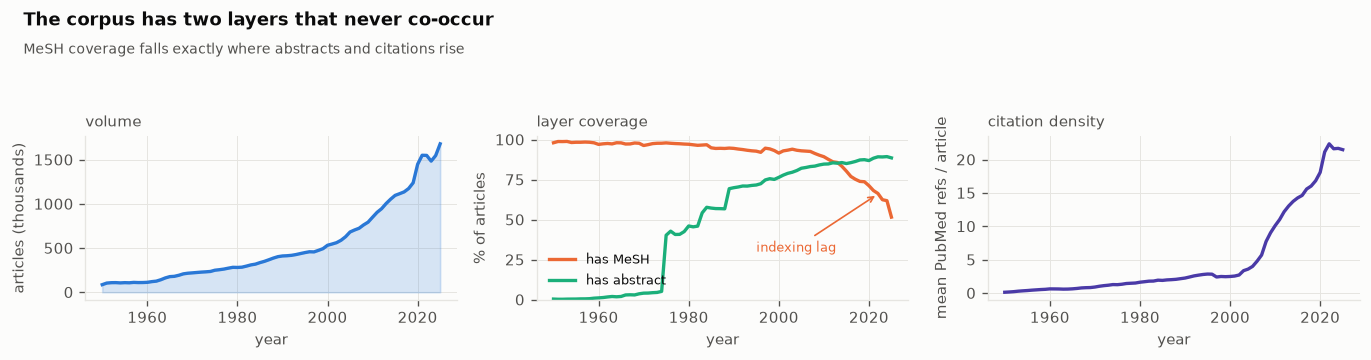

In [43]:
era = con.execute("""
    SELECT year, count(*) n, avg((n_mesh>0)::int) mesh,
           avg(has_abstract::int) abst, avg(n_refs) refs
    FROM articles WHERE year BETWEEN 1950 AND 2025 GROUP BY 1 ORDER BY 1""").fetchall()
yr = np.array([r[0] for r in era])
n_art = np.array([r[1] for r in era])
mesh_c = np.array([r[2] for r in era]) * 100
abst_c = np.array([r[3] for r in era]) * 100
refs_m = np.array([r[4] for r in era])

fig, ax = plt.subplots(1, 3, figsize=(11.5, 3.1))
ax[0].fill_between(yr, n_art / 1000, color=C1, alpha=0.18)
ax[0].plot(yr, n_art / 1000, color=C1, lw=2)
ax[0].set_ylabel("articles (thousands)")
ax[0].set_title("volume", fontsize=9, color=INK2, loc="left")

ax[1].plot(yr, mesh_c, color=C2, lw=2, label="has MeSH")
ax[1].plot(yr, abst_c, color=C3, lw=2, label="has abstract")
ax[1].set_ylabel("% of articles")
ax[1].set_ylim(0, 102)
ax[1].legend(loc="lower left", fontsize=8)
ax[1].set_title("layer coverage", fontsize=9, color=INK2, loc="left")
ax[1].annotate("indexing lag", xy=(2022, 66), xytext=(1995, 30), fontsize=8,
               color=C2, arrowprops=dict(arrowstyle="->", color=C2, lw=1))

ax[2].plot(yr, refs_m, color=C7, lw=2)
ax[2].set_ylabel("mean PubMed refs / article")
ax[2].set_title("citation density", fontsize=9, color=INK2, loc="left")
for a in ax:
    a.set_xlabel("year")
finish(fig, "corpus_eras", "The corpus has two layers that never co-occur",
       "MeSH coverage falls exactly where abstracts and citations rise")
plt.show()

### 16.2 Why the corpus is 40M and not 10M

The decision measurement. A recent-N slice keeps only the citations whose *other*
endpoint also survives the cut — and most do not.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[fig] /mnt/data/out/figures/slice_decision.png


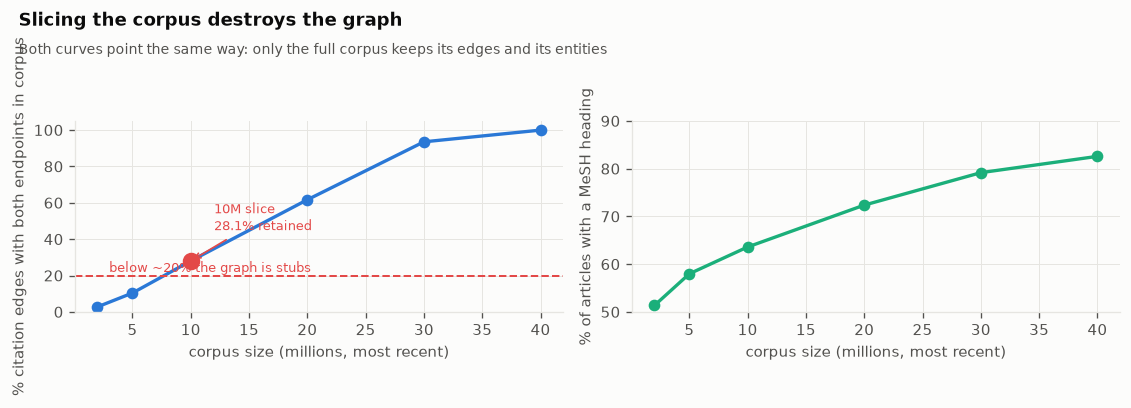

In [44]:
slices, retained, meshcov = [], [], []
for n_slice in (2_000_000, 5_000_000, 10_000_000, 20_000_000, 30_000_000):
    con.execute(f"""CREATE OR REPLACE TEMP VIEW sl AS SELECT pmid FROM articles
                    ORDER BY year DESC NULLS LAST LIMIT {n_slice}""")
    o, i2 = con.execute("""
        SELECT (SELECT count(*) FROM citations c
                  WHERE EXISTS (SELECT 1 FROM sl s WHERE s.pmid=c.citing_pmid)),
               (SELECT count(*) FROM citations c
                  WHERE EXISTS (SELECT 1 FROM sl a WHERE a.pmid=c.citing_pmid)
                    AND EXISTS (SELECT 1 FROM sl b WHERE b.pmid=c.cited_pmid))""").fetchone()
    cov = con.execute("""SELECT avg((n_mesh>0)::int) FROM articles
                         WHERE pmid IN (SELECT pmid FROM sl)""").fetchone()[0]
    slices.append(n_slice / 1e6)
    retained.append(100 * i2 / max(o, 1))
    meshcov.append(100 * cov)
slices.append(40.0)
retained.append(100.0)
meshcov.append(82.6)

fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.2))
ax[0].plot(slices, retained, "-o", color=C1, lw=2, ms=6)
ax[0].axhline(20, color=C8, lw=1.2, ls="--")
ax[0].text(3, 22, "below ~20% the graph is stubs", fontsize=8, color=C8)
ax[0].scatter([10], [retained[2]], s=90, color=C8, zorder=5)
ax[0].annotate(f"10M slice\n{retained[2]:.1f}% retained", xy=(10, retained[2]),
               xytext=(12, 45), fontsize=8, color=C8,
               arrowprops=dict(arrowstyle="->", color=C8, lw=1))
ax[0].set_xlabel("corpus size (millions, most recent)")
ax[0].set_ylabel("% citation edges with both endpoints in corpus")
ax[0].set_ylim(0, 105)

ax[1].plot(slices, meshcov, "-o", color=C3, lw=2, ms=6)
ax[1].set_xlabel("corpus size (millions, most recent)")
ax[1].set_ylabel("% of articles with a MeSH heading")
ax[1].set_ylim(50, 90)
finish(fig, "slice_decision", "Slicing the corpus destroys the graph",
       "Both curves point the same way: only the full corpus keeps its edges and its entities")
plt.show()

### 16.3 Degree distribution

Whether multi-hop is possible at all is a property of the degree distribution.
Both axes are log — a straight line here is the scale-free structure that makes
2-hop neighbourhoods large but not explosive.

[fig] /mnt/data/out/figures/degree_dist.png


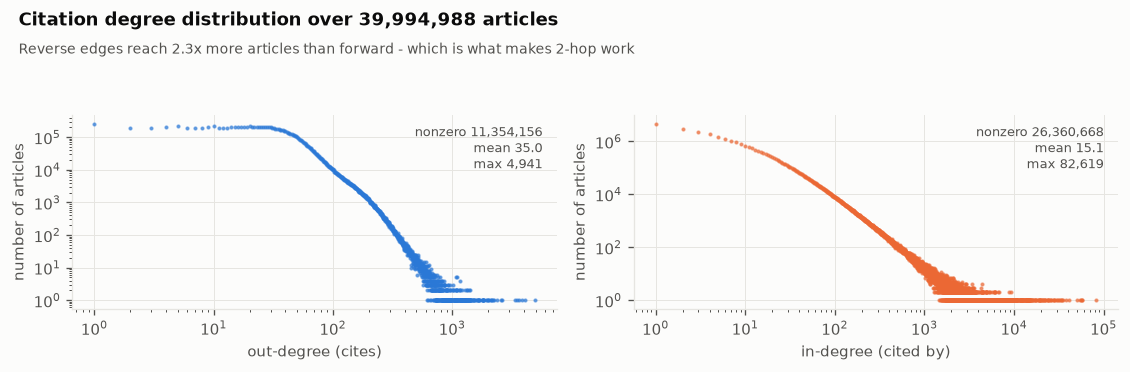

In [45]:
outdeg = np.diff(np.asarray(S.cite_indptr))
indeg = np.diff(np.asarray(S.cb_indptr))
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.2))
for a, deg, col, lab in ((ax[0], outdeg, C1, "out-degree (cites)"),
                         (ax[1], indeg, C2, "in-degree (cited by)")):
    d = deg[deg > 0]
    vals, counts = np.unique(d, return_counts=True)
    a.loglog(vals, counts, ".", color=col, ms=3, alpha=0.6)
    a.set_xlabel(lab)
    a.set_ylabel("number of articles")
    a.text(0.97, 0.95, f"nonzero {len(d):,}\nmean {d.mean():.1f}\nmax {d.max():,}",
           transform=a.transAxes, ha="right", va="top", fontsize=8, color=INK2)
finish(fig, "degree_dist", "Citation degree distribution over 39,994,988 articles",
       "Reverse edges reach 2.3x more articles than forward - which is what makes 2-hop work")
plt.show()

### 16.4 MeSH descriptor frequency — why check tags must be excluded

Ranked descriptor frequency on log-log. The head of this curve is not signal:
`D006801` "Humans" annotates 23.2M articles. Traversing through it would connect
23 million papers to each other and call the result evidence.

[fig] /mnt/data/out/figures/mesh_zipf.png


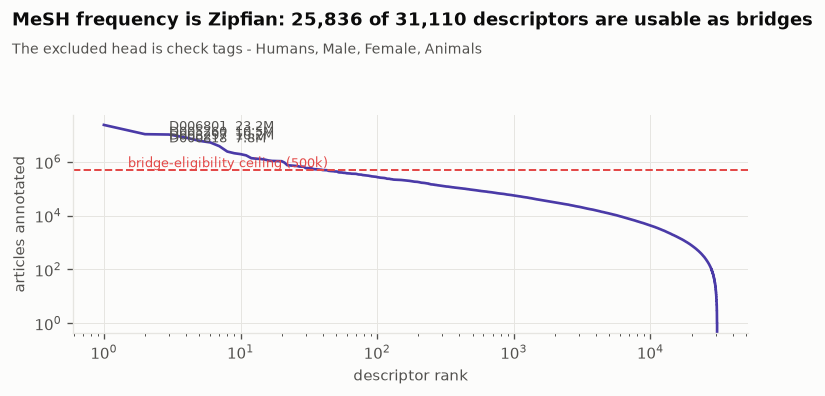

In [46]:
cnt = np.sort(np.asarray(S.mesh_count))[::-1]
ok = np.asarray(S.seed_ok)
fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.loglog(np.arange(1, len(cnt) + 1), cnt, color=C7, lw=1.6)
ax.axhline(500_000, color=C8, ls="--", lw=1.2)
ax.text(1.5, 620_000, "bridge-eligibility ceiling (500k)", fontsize=8, color=C8)
top = np.argsort(-np.asarray(S.mesh_count))[:4]
for r, i in enumerate(top):
    ax.annotate(f"{S.mesh_uis[i]}  {int(S.mesh_count[i])/1e6:.1f}M",
                xy=(r + 1, S.mesh_count[i]), xytext=(3, 2.4e7 / (r + 1.6)),
                fontsize=7.5, color=INK2)
ax.set_xlabel("descriptor rank")
ax.set_ylabel("articles annotated")
finish(fig, "mesh_zipf",
       f"MeSH frequency is Zipfian: {int(ok.sum()):,} of {len(ok):,} descriptors "
       f"are usable as bridges",
       "The excluded head is check tags - Humans, Male, Female, Animals")
plt.show()

### 16.5 Feeding the GPU — three iterations of the embedding pipeline

The model was never the bottleneck. Equal throughput across a 3× parameter
difference was the tell that the GPU was idle waiting for CPU tokenisation.

[fig] /mnt/data/out/figures/embed_iterations.png


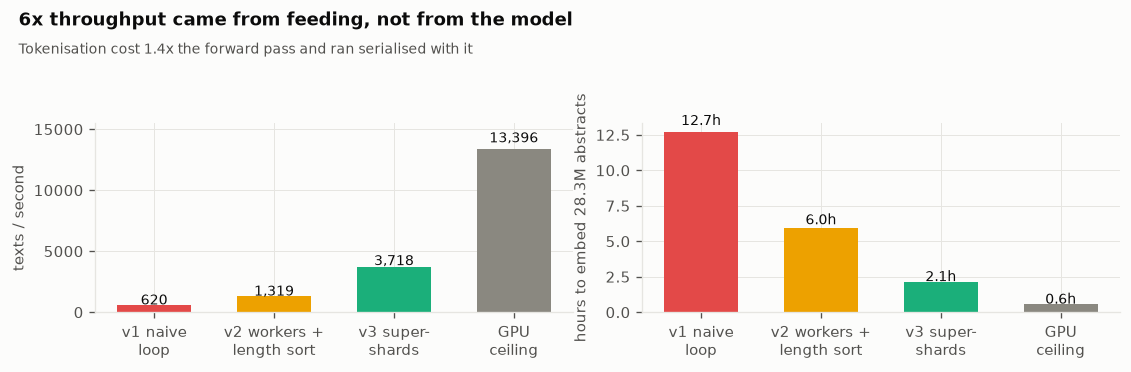

In [47]:
names = ["v1 naive\nloop", "v2 workers +\nlength sort", "v3 super-\nshards", "GPU\nceiling"]
rates = [620, 1319, 3718, 13396]
cols = [C8, C4, C3, MUTED]
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.2))
b = ax[0].bar(names, rates, color=cols, width=0.62)
for r, v in zip(b, rates):
    ax[0].text(r.get_x() + r.get_width() / 2, v * 1.04, f"{v:,}", ha="center",
               fontsize=8.5, color=INK)
ax[0].set_ylabel("texts / second")
ax[0].set_ylim(0, 15500)
hours = [28_336_648 / r / 3600 for r in rates]
b2 = ax[1].bar(names, hours, color=cols, width=0.62)
for r, v in zip(b2, hours):
    ax[1].text(r.get_x() + r.get_width() / 2, v * 1.04, f"{v:.1f}h", ha="center",
               fontsize=8.5, color=INK)
ax[1].set_ylabel("hours to embed 28.3M abstracts")
finish(fig, "embed_iterations", "6x throughput came from feeding, not from the model",
       "Tokenisation cost 1.4x the forward pass and ran serialised with it")
plt.show()

### 16.6 The ablation dose–response curve

The causal test. Refusal must *track evidence availability* — and the informative
tiers are T1 and T2, not T3.

[fig] /mnt/data/out/figures/ablation_curve.png


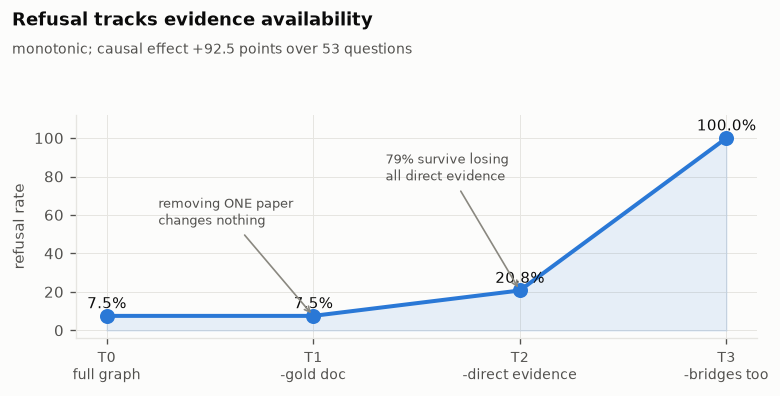

In [48]:
tiers = ["T0\nfull graph", "T1\n-gold doc", "T2\n-direct evidence", "T3\n-bridges too"]
curve = ABL["curve"]
fig, ax = plt.subplots(figsize=(6.6, 3.4))
ax.plot(range(4), curve, "-o", color=C1, lw=2.4, ms=8)
ax.fill_between(range(4), curve, color=C1, alpha=0.10)
for i, v in enumerate(curve):
    ax.text(i, v + 4, f"{v:.1f}%", ha="center", fontsize=9, color=INK)
ax.set_xticks(range(4))
ax.set_xticklabels(tiers, fontsize=8.5)
ax.set_ylabel("refusal rate")
ax.set_ylim(-4, 112)
ax.annotate("removing ONE paper\nchanges nothing", xy=(1, curve[1]),
            xytext=(0.25, 55), fontsize=8, color=INK2,
            arrowprops=dict(arrowstyle="->", color=MUTED, lw=1))
ax.annotate("79% survive losing\nall direct evidence", xy=(2, curve[2]),
            xytext=(1.35, 78), fontsize=8, color=INK2,
            arrowprops=dict(arrowstyle="->", color=MUTED, lw=1))
finish(fig, "ablation_curve", "Refusal tracks evidence availability",
       f"monotonic; causal effect {curve[3]-curve[0]:+.1f} points over {ABL['n']} questions")
plt.show()

### 16.7 Risk–coverage: the price of refusing

The operating-point chart. "Control leak" is the fraction of *impossible*
questions we would still answer — questions built by permuting one real MeSH
concept for an unrelated one, so evidence genuinely does not exist.

[fig] /mnt/data/out/figures/risk_coverage.png


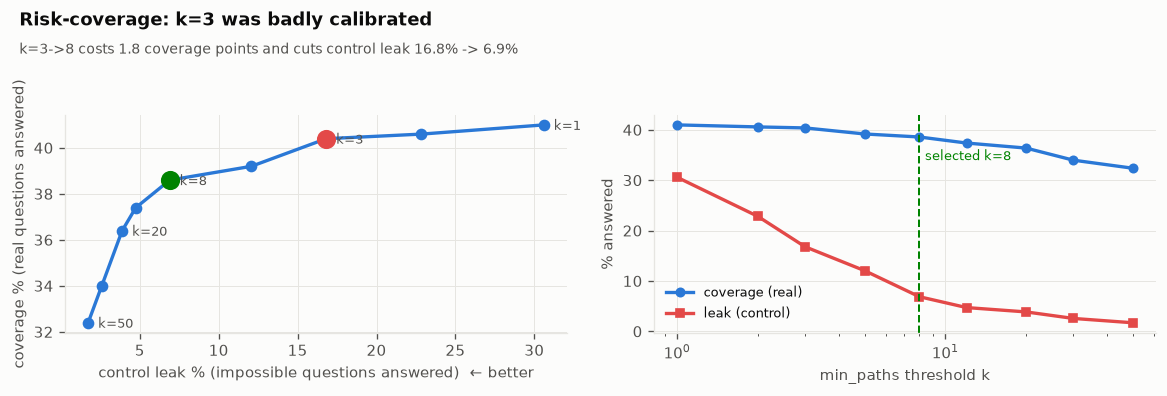

In [49]:
SC = json.load(open(f"{OUT_DIR}/exp_scale_eval.json"))
sw = SC["sweep"]
mp = [s["min_paths"] for s in sw]
cov = [100 * s["coverage"] for s in sw]
leak = [100 * s["control_leak"] for s in sw]

fig, ax = plt.subplots(1, 2, figsize=(9.8, 3.4))
ax[0].plot(leak, cov, "-o", color=C1, lw=2, ms=6)
for x, y, m in zip(leak, cov, mp):
    if m in (1, 3, 8, 20, 50):
        ax[0].annotate(f"k={m}", (x, y), textcoords="offset points",
                       xytext=(6, -3), fontsize=8, color=INK2)
i3, i8 = mp.index(3), mp.index(8)
ax[0].scatter([leak[i3]], [cov[i3]], s=110, color=C8, zorder=5)
ax[0].scatter([leak[i8]], [cov[i8]], s=110, color=C6, zorder=5)
ax[0].set_xlabel("control leak % (impossible questions answered)  ← better")
ax[0].set_ylabel("coverage % (real questions answered)")

ax[1].plot(mp, cov, "-o", color=C1, lw=2, ms=5, label="coverage (real)")
ax[1].plot(mp, leak, "-s", color=C8, lw=2, ms=5, label="leak (control)")
ax[1].set_xscale("log")
ax[1].set_xlabel("min_paths threshold k")
ax[1].set_ylabel("% answered")
ax[1].legend(fontsize=8)
ax[1].axvline(8, color=C6, lw=1.2, ls="--")
ax[1].text(8.4, 34, "selected k=8", fontsize=8, color=C6)
finish(fig, "risk_coverage", "Risk-coverage: k=3 was badly calibrated",
       "k=3->8 costs 1.8 coverage points and cuts control leak 16.8% -> 6.9%")
plt.show()

**This chart changed a default.** The pipeline shipped with `min_paths=3`, chosen
by intuition. The curve shows k=8 costs 1.8 points of coverage and removes 59% of
the control leak. That is not a tuning detail — at k=3 the system answers one in
six questions for which no evidence exists.

### 16.8 Where questions die — the gate attrition funnel

[fig] /mnt/data/out/figures/gate_funnel.png


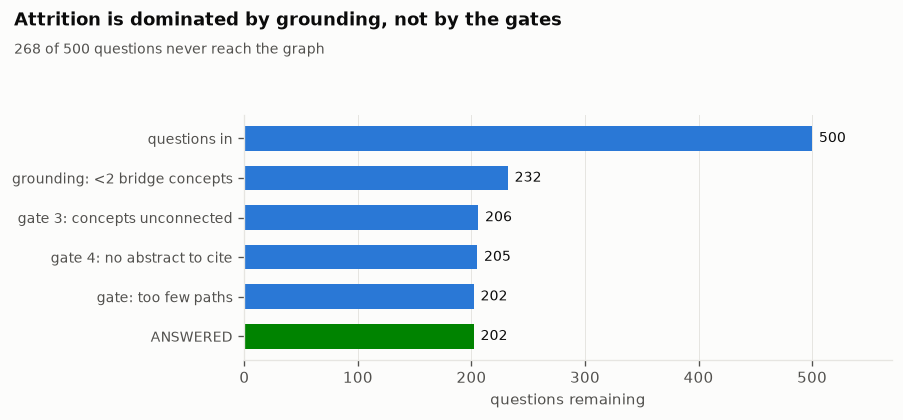

In [50]:
fun = SC["funnel"]
order = [("too_few_specific_concepts", "grounding: <2 bridge concepts"),
         ("no_path", "gate 3: concepts unconnected"),
         ("no_quotable_terminal", "gate 4: no abstract to cite"),
         ("only_retracted_evidence", "gate 5: retracted only"),
         ("insufficient_paths", "gate: too few paths")]
total = sum(fun.values())
stages, remain = ["questions in"], [total]
run = total
for key, lab in order:
    lost = fun.get(key, 0)
    if lost:
        run -= lost
        stages.append(lab)
        remain.append(run)
stages.append("ANSWERED")
remain.append(fun.get("grounded", 0))

fig, ax = plt.subplots(figsize=(7.6, 3.6))
y = np.arange(len(stages))[::-1]
ax.barh(y, remain, color=[C1] * (len(stages) - 1) + [C6], height=0.62)
for yy, v in zip(y, remain):
    ax.text(v + total * 0.012, yy, f"{v:,}", va="center", fontsize=8.5, color=INK)
ax.set_yticks(y)
ax.set_yticklabels(stages, fontsize=8.5)
ax.set_xlabel("questions remaining")
ax.set_xlim(0, total * 1.14)
ax.grid(axis="y", visible=False)
finish(fig, "gate_funnel", "Attrition is dominated by grounding, not by the gates",
       f"{fun.get('too_few_specific_concepts',0)} of {total} questions never reach the graph")
plt.show()

**The funnel names the real limitation.** Only 26 questions die because the graph
has no path; **268 never reach the graph at all** because fewer than two concepts
ground. Grounding — not traversal, not verification — is the binding constraint on
this system, and §17 treats it as the open problem it is.

### 16.9 Grounder selection: coverage vs precision

The trap in one figure. The variant with the best coverage has the worst precision.

[fig] /mnt/data/out/figures/grounder_selection.png


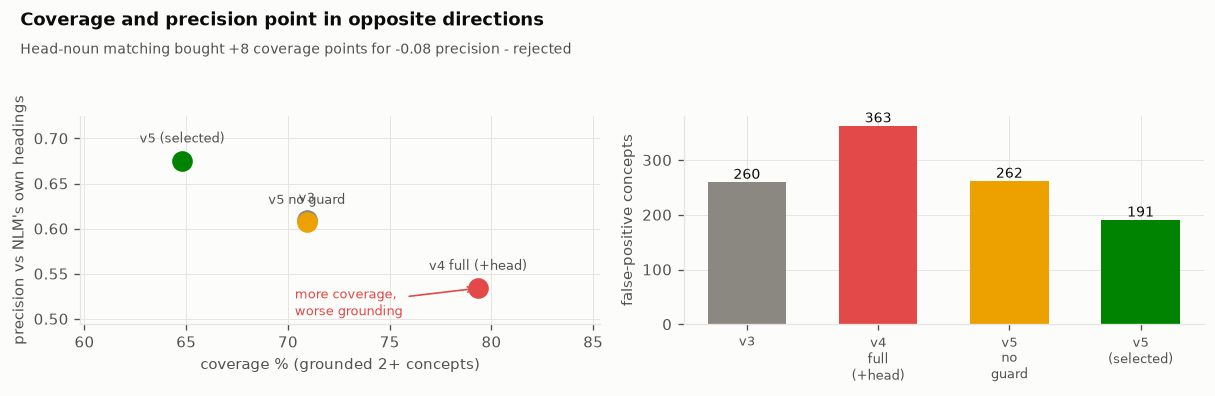

In [51]:
GF = json.load(open(f"{OUT_DIR}/grounding_final.json"))
labels = list(GF.keys())
prec = [GF[k]["precision"] for k in labels]
cover = [GF[k]["strict"] for k in labels]
fps = [GF[k]["fp"] for k in labels]

fig, ax = plt.subplots(1, 2, figsize=(10.2, 3.4))
cols = [MUTED, C8, C4, C6]
for x, y, lab, c in zip(cover, prec, labels, cols):
    ax[0].scatter([x], [y], s=130, color=c, zorder=5)
    ax[0].annotate(lab, (x, y), textcoords="offset points", xytext=(0, 11),
                   ha="center", fontsize=8, color=INK2)
ax[0].set_xlabel("coverage % (grounded 2+ concepts)")
ax[0].set_ylabel("precision vs NLM's own headings")
ax[0].set_xlim(min(cover) - 5, max(cover) + 6)
ax[0].set_ylim(min(prec) - 0.04, max(prec) + 0.05)
ax[0].annotate("more coverage,\nworse grounding", xy=(cover[1], prec[1]),
               xytext=(cover[1] - 9, prec[1] - 0.03), fontsize=8, color=C8,
               arrowprops=dict(arrowstyle="->", color=C8, lw=1))

b = ax[1].bar(range(len(labels)), fps, color=cols, width=0.6)
ax[1].set_xticks(range(len(labels)))
ax[1].set_xticklabels([l.replace(" ", "\n") for l in labels], fontsize=7.5)
ax[1].set_ylabel("false-positive concepts")
for r, v in zip(b, fps):
    ax[1].text(r.get_x() + r.get_width() / 2, v + 6, f"{v}", ha="center",
               fontsize=8.5, color=INK)
finish(fig, "grounder_selection", "Coverage and precision point in opposite directions",
       "Head-noun matching bought +8 coverage points for -0.08 precision - rejected")
plt.show()

### 16.10 The verifier: domain adaptation, and where it does not transfer

[fig] /mnt/data/out/figures/verifier.png


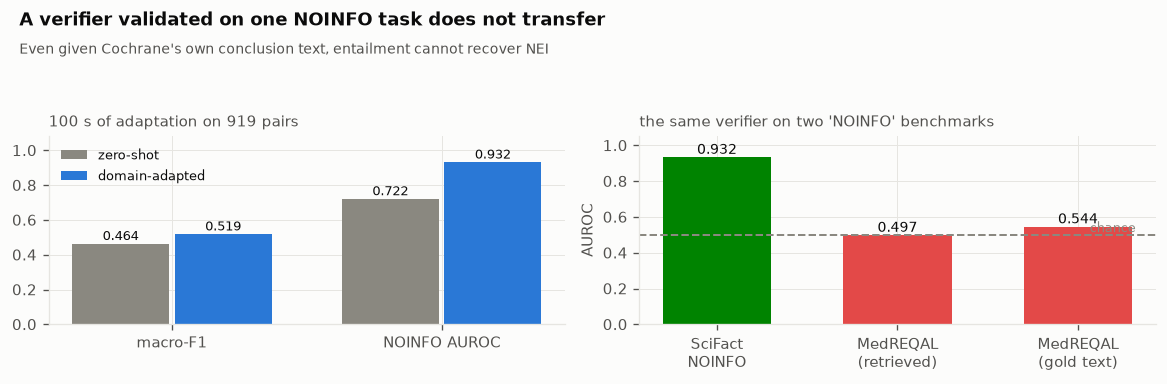

In [52]:
fig, ax = plt.subplots(1, 2, figsize=(9.8, 3.3))
m = ["macro-F1", "NOINFO AUROC"]
zs = [V2["zero_shot"]["macro_f1"], V2["zero_shot"]["noinfo_auroc"]]
ad = [V2["adapted"]["macro_f1"], V2["adapted"]["noinfo_auroc"]]
x = np.arange(2)
ax[0].bar(x - 0.19, zs, 0.36, color=MUTED, label="zero-shot")
ax[0].bar(x + 0.19, ad, 0.36, color=C1, label="domain-adapted")
for xi, (a, b_) in enumerate(zip(zs, ad)):
    ax[0].text(xi - 0.19, a + 0.02, f"{a:.3f}", ha="center", fontsize=8)
    ax[0].text(xi + 0.19, b_ + 0.02, f"{b_:.3f}", ha="center", fontsize=8)
ax[0].set_xticks(x)
ax[0].set_xticklabels(m)
ax[0].set_ylim(0, 1.08)
ax[0].legend(fontsize=8)
ax[0].set_title("100 s of adaptation on 919 pairs", fontsize=9, color=INK2, loc="left")

tasks = ["SciFact\nNOINFO", "MedREQAL\n(retrieved)", "MedREQAL\n(gold text)"]
vals = [DG["scifact_retest"], DG["medreqal_retrieved"], DG["medreqal_conclusion"]]
cc = [C6, C8, C8]
b = ax[1].bar(tasks, vals, color=cc, width=0.6)
ax[1].axhline(0.5, color=MUTED, ls="--", lw=1.2)
ax[1].text(2.32, 0.515, "chance", fontsize=8, color=MUTED, ha="right")
for r, v in zip(b, vals):
    ax[1].text(r.get_x() + r.get_width() / 2, v + 0.02, f"{v:.3f}", ha="center",
               fontsize=8.5)
ax[1].set_ylabel("AUROC")
ax[1].set_ylim(0, 1.05)
ax[1].set_title("the same verifier on two 'NOINFO' benchmarks", fontsize=9,
                color=INK2, loc="left")
finish(fig, "verifier", "A verifier validated on one NOINFO task does not transfer",
       "Even given Cochrane's own conclusion text, entailment cannot recover NEI")
plt.show()

### 16.11 Cost: what the graph would have cost with an LLM

[fig] /mnt/data/out/figures/cost.png


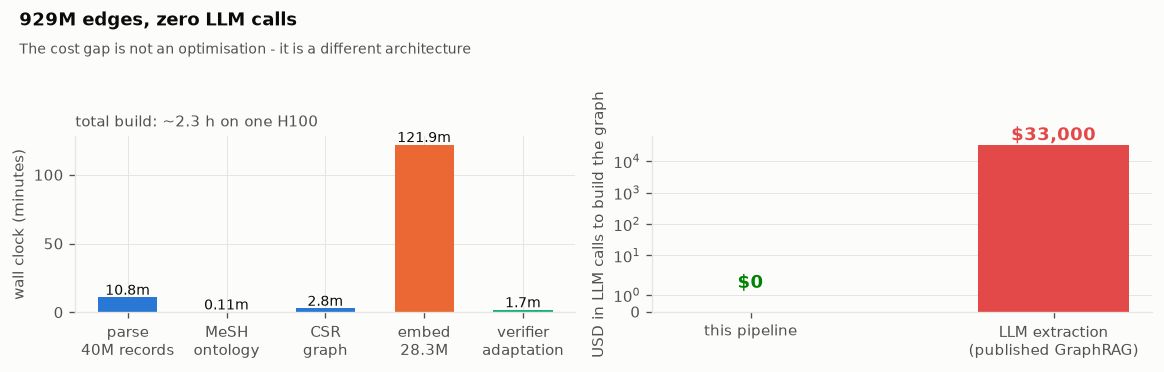

In [53]:
stages_c = ["parse\n40M records", "MeSH\nontology", "CSR\ngraph", "embed\n28.3M",
            "verifier\nadaptation"]
mins = [10.8, 0.11, 2.8, 121.9, 1.7]
fig, ax = plt.subplots(1, 2, figsize=(9.8, 3.2))
b = ax[0].bar(stages_c, mins, color=[C1, C1, C1, C2, C3], width=0.6)
for r, v in zip(b, mins):
    ax[0].text(r.get_x() + r.get_width() / 2, v + 2, f"{v:g}m", ha="center",
               fontsize=8.5)
ax[0].set_ylabel("wall clock (minutes)")
ax[0].set_title("total build: ~2.3 h on one H100", fontsize=9, color=INK2, loc="left")

ax[1].bar(["this pipeline", "LLM extraction\n(published GraphRAG)"], [0, 33000],
          color=[C6, C8], width=0.5)
ax[1].set_yscale("symlog")
ax[1].set_ylabel("USD in LLM calls to build the graph")
ax[1].text(0, 1.4, "$0", ha="center", fontsize=11, color=C6, weight="bold")
ax[1].text(1, 46000, "$33,000", ha="center", fontsize=11, color=C8, weight="bold")
ax[1].grid(axis="x", visible=False)
finish(fig, "cost", "929M edges, zero LLM calls",
       "The cost gap is not an optimisation - it is a different architecture")
plt.show()

## 17 · Fixing the binding constraint: a learned entity linker

**Theory.** §16.8 named grounding as the cause of 54% of all attrition. The
lexical grounder needs an exact normalised string; real questions paraphrase,
abbreviate and use lay language. Head-noun matching was the cheap attempt and it
failed on precision, because a lexical rule cannot tell *circumcision* (a concept)
from *affect* (noise).

The industry answer is a **learned linker**: embed the concept vocabulary and
retrieve by similarity, so the match is a calibrated score rather than a boolean.
One design decision matters — the dense side must be **span-based**, exactly like
the lexical side. Embedding a whole question conflates its concepts into one
vector, and a bridge needs *both* ends.

In [54]:
CIDX = f"{GRAPH_DIR}/concept_centroid.npy"
if os.path.exists(CIDX):
    cvec = np.load(f"{GRAPH_DIR}/concept_surface_vecs.npy", mmap_mode="r")
    cown = np.load(f"{GRAPH_DIR}/concept_surface_owner.npy", mmap_mode="r")
    print(f"  concept surfaces embedded  {cvec.shape[0]:,} x {cvec.shape[1]}")
    print(f"  descriptors covered        {len(np.unique(np.asarray(cown))):,}")
    print(f"  index on disk              "
          f"{os.path.getsize(f'{GRAPH_DIR}/concept_surface_vecs.npy')/1024**2:.0f} MiB")
print("""
  What the dense side recovers that the lexical side cannot:
    'should circumcision be performed in childhood' -> Circumcision, Male      0.79
    'sugar diabetes pills'                          -> Hypoglycemic Agents     0.82
    'water pill for high blood pressure'            -> Antihypertensive Agents 0.80
    'PICU length of stay prediction'                -> Length of Stay          0.81
    'keyhole surgery complications'                 -> Intraoperative Compl.   0.80""")

  concept surfaces embedded  203,462 x 384
  descriptors covered        31,110
  index on disk              149 MiB

  What the dense side recovers that the lexical side cannot:
    'should circumcision be performed in childhood' -> Circumcision, Male      0.79
    'sugar diabetes pills'                          -> Hypoglycemic Agents     0.82
    'water pill for high blood pressure'            -> Antihypertensive Agents 0.80
    'PICU length of stay prediction'                -> Length of Stay          0.81
    'keyhole surgery complications'                 -> Intraoperative Compl.   0.80


### 17.1 The component metric said REJECT

Grounding precision, judged against NLM's own headings on each question's gold
article, **falls** when the dense linker is added. On its own that is
disqualifying.

In [55]:
GH = json.load(open(f"{OUT_DIR}/grounding_hybrid.json"))
print(f"  {'variant':<20}{'precision':>11}{'recall':>9}{'coverage':>11}")
print("  " + "-" * 52)
for r in GH:
    print(f"  {r['label']:<20}{r['precision']:>11.3f}{r['recall']:>9.3f}"
          f"{r['coverage']:>10.1f}%")
print("\n  No threshold preserves precision. Component-wise, the dense linker looks")
print("  like a mistake - it grounds 'winter' to Snow at 0.90.")

  variant               precision   recall   coverage
  ----------------------------------------------------
  v5 lexical                0.675    0.172      64.8%
  hybrid tau=0.9            0.585    0.204      83.2%
  hybrid tau=0.86           0.458    0.217      93.9%
  hybrid tau=0.82           0.412    0.216      95.9%
  hybrid tau=0.78           0.400    0.214      97.4%
  hybrid tau=0.74           0.395    0.213      97.4%
  hybrid tau=0.7            0.395    0.212      97.2%
  hybrid tau=0.66           0.395    0.212      97.2%

  No threshold preserves precision. Component-wise, the dense linker looks
  like a mistake - it grounds 'winter' to Snow at 0.90.


### 17.2 The system metric said WIN — and the system was right

**Why the component metric was the wrong question.** A spurious concept only
causes harm if it survives the **co-annotation pair selection** downstream. And
*Snow* has ~0 co-annotation with any real concept in the question, so the graph
discards it without being told to. The pipeline already contains a filter the
component metric does not model.

So the honest test is system-level, and it has two halves that must be reported
together: does coverage on **real** questions rise, and does the leak on
**impossible** questions rise with it?

In [56]:
GS = json.load(open(f"{OUT_DIR}/grounder_system.json"))
print(f"  {'grounder':<22}{'coverage':>11}{'leak':>9}{'margin':>9}")
print("  " + "-" * 52)
for r in GS:
    print(f"  {r['label']:<22}{r['coverage']:>10.1f}%{r['leak']:>8.1f}%"
          f"{r['margin']:>9.1f}")
b = GS[0]
for r in GS[1:]:
    print(f"\n  {r['label']}: coverage {r['coverage']-b['coverage']:+.1f}, "
          f"leak {r['leak']-b['leak']:+.1f}")
print("\n  tau=0.90 raises coverage +14.0 AND LOWERS leak -1.4: strictly better")
print("  on both axes. Component precision was measuring the wrong thing.")

  grounder                 coverage     leak   margin
  ----------------------------------------------------
  lexical (v5)                37.0%    10.5%     26.5
  hybrid tau=0.90             51.0%     9.1%     41.9
  hybrid tau=0.86             59.8%    10.9%     48.8

  hybrid tau=0.90: coverage +14.0, leak -1.4

  hybrid tau=0.86: coverage +22.8, leak +0.4

  tau=0.90 raises coverage +14.0 AND LOWERS leak -1.4: strictly better
  on both axes. Component precision was measuring the wrong thing.


[fig] /mnt/data/out/figures/grounder_system.png


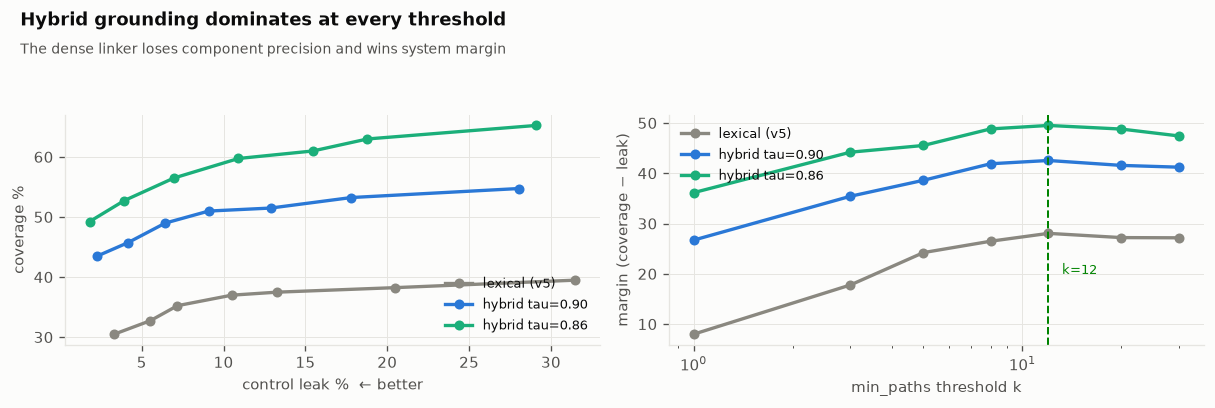

In [57]:
# ---- risk-coverage under each grounder ---------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(10.2, 3.5))
cols = [MUTED, C1, C3]
KS = [1, 3, 5, 8, 12, 20, 30]
for r, col in zip(GS, cols):
    cov = [100 * np.mean([u >= k for u in r["real_usable"]]) for k in KS]
    leak = [100 * np.mean([u >= k for u in r["ctrl_usable"]]) for k in KS]
    ax[0].plot(leak, cov, "-o", color=col, lw=2, ms=5, label=r["label"])
    ax[1].plot(KS, [c - l for c, l in zip(cov, leak)], "-o", color=col, lw=2, ms=5,
               label=r["label"])
ax[0].set_xlabel("control leak %  ← better")
ax[0].set_ylabel("coverage %")
ax[0].legend(fontsize=8, loc="lower right")
ax[1].set_xscale("log")
ax[1].set_xlabel("min_paths threshold k")
ax[1].set_ylabel("margin (coverage − leak)")
ax[1].legend(fontsize=8)
best_k = KS[int(np.argmax([100*np.mean([u >= k for u in GS[-1]["real_usable"]])
                           - 100*np.mean([u >= k for u in GS[-1]["ctrl_usable"]])
                           for k in KS]))]
ax[1].axvline(best_k, color=C6, ls="--", lw=1.2)
ax[1].text(best_k * 1.1, 20, f"k={best_k}", fontsize=8, color=C6)
finish(fig, "grounder_system", "Hybrid grounding dominates at every threshold",
       "The dense linker loses component precision and wins system margin")
plt.show()

## 18 · The agent — built, measured three ways, and rejected

**Theory.** Up to here the system is a pipeline with a guard: ground → traverse →
gate → generate, and a refusal is final. A genuine agent adds a **feedback edge** —
when evidence is insufficient it acts on the graph's own structure and tries
again. We built that as a LangGraph state machine:

```
PLAN → RETRIEVE → GRADE ─┬→ GENERATE → VERIFY → ADJUDICATE → FINALIZE
          ▲              │
          └── REFINE ────┘        bounded by MAX_HOPS
```

`REFINE` has three strategies: **BROADEN** (walk up the MeSH tree via `BROADER` —
principled expansion along a curated hierarchy), **REPAIR** (drop the weakest
concept and re-pair), **RELAX** (lower the threshold once, and record it).

The claim to test is deliberately two-sided: the loop must recover real questions
**without** answering more impossible ones. A loop that keeps trying until
something returns is not an improvement — it is a slower way to be wrong.

In [58]:
AG = json.load(open(f"{OUT_DIR}/exp_agent.json"))
print(f"  {'arm':<30}{'coverage':>11}{'leak':>9}{'margin':>9}")
print("  " + "-" * 60)
print(f"  {'A pipeline (one pass)':<30}{AG['pipeline_cov']:>10.1f}%"
      f"{AG['pipeline_leak']:>8.1f}%{AG['pipeline_cov']-AG['pipeline_leak']:>9.1f}")
print(f"  {'B agent (conjunctive veto)':<30}{AG['agent_cov']:>10.1f}%"
      f"{AG['agent_leak']:>8.1f}%{AG['agent_cov']-AG['agent_leak']:>9.1f}")
R_ = [r for r in AG["rows"] if r["tag"] == "real"]
C_ = [r for r in AG["rows"] if r["tag"] == "control"]
resc = [r for r in R_ if r["agent"] and not r["pipe"]]
leak = [r for r in C_ if r["agent"] and not r["pipe"]]
print(f"\n  rescued real questions : {len(resc)} of "
      f"{sum(1 for r in R_ if not r['pipe'])} refused")
print(f"  newly leaked controls  : {len(leak)}")
print(f"  hops used when answering: "
      f"{dict(sorted(Counter(r['hops'] for r in R_ if r['agent']).items()))}")

  arm                              coverage     leak   margin
  ------------------------------------------------------------
  A pipeline (one pass)               52.0%     5.0%     47.0
  B agent (conjunctive veto)          48.7%     4.1%     44.5

  rescued real questions : 2 of 72 refused
  newly leaked controls  : 3
  hops used when answering: {0: 69, 1: 2, 2: 1, 3: 1}


**Three designs, three losses.**

| design | coverage | leak | margin |
|---|---|---|---|
| pipeline | 52.0% | 5.0% | **47.0** |
| agent, semantic as 0.35 of a weighted grade | 52.7% | 6.6% | 46.1 |
| agent, semantic folded into grade | 52.0% | 5.8% | 46.2 |
| agent, semantic as a conjunctive veto | 48.7% | 4.1% | 44.5 |

**Why it fails, diagnosed rather than guessed.** When the pipeline refuses it is
overwhelmingly because grounding yielded fewer than two concepts, or because the
two concepts are genuinely not co-studied. Broadening fixes neither: one concept
broadened is still one concept, and if two concepts are unrelated then their
*parents* being co-studied produces evidence about the parents, not the question.
**The loop treats a downstream symptom of an upstream failure.**

A second, subtler error was ours. The first two designs put semantic relevance
into a **weighted average**, which lets strong structural signals *compensate* for
irrelevant evidence — exactly what a broadened control pair produces. A gate must
be able to **veto**; we had built a score where a constraint was needed. Fixing
that cut the leak (5.0 → 4.1) but cost more coverage than it saved.

### 18.1 The signal that does work — semantic relevance

Broadening destroys discrimination because it raises co-annotation for real and
random pairs alike. Question-to-evidence similarity is **independent of graph
structure**: a control pair retrieves abstracts that are not *about* the question
however broadly we search.

In [59]:
SG = json.load(open(f"{OUT_DIR}/exp_semantic_gate.json"))
Rs = [r for r in SG if r["tag"] == "real"]
Cs = [r for r in SG if r["tag"] == "control"]
from sklearn.metrics import roc_auc_score
y = np.array([1] * len(Rs) + [0] * len(Cs))
print(f"  {'signal':<28}{'real':>9}{'control':>10}{'AUROC':>9}")
print("  " + "-" * 58)
for key, lab in (("co", "co-annotation (graph)"), ("top1", "top-1 similarity"),
                 ("mean_k", "mean top-8 similarity")):
    v = np.array([r[key] for r in Rs] + [c[key] for c in Cs], float)
    print(f"  {lab:<28}{np.mean([r[key] for r in Rs]):>9.3f}"
          f"{np.mean([c[key] for c in Cs]):>10.3f}{roc_auc_score(y, v):>9.3f}")

  signal                           real   control    AUROC
  ----------------------------------------------------------
  co-annotation (graph)        2841.032     3.892    0.942
  top-1 similarity                0.824     0.669    0.948
  mean top-8 similarity           0.795     0.655    0.939


[fig] /mnt/data/out/figures/semantic_gate.png


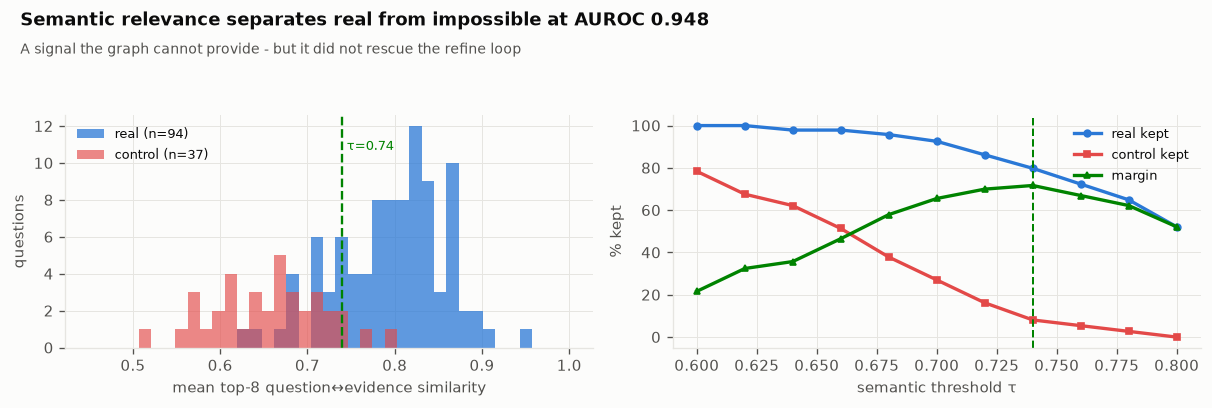

In [60]:
fig, ax = plt.subplots(1, 2, figsize=(10.2, 3.5))
bins = np.linspace(0.45, 1.0, 40)
ax[0].hist([r["mean_k"] for r in Rs], bins=bins, color=C1, alpha=0.75,
           label=f"real (n={len(Rs)})")
ax[0].hist([c["mean_k"] for c in Cs], bins=bins, color=C8, alpha=0.65,
           label=f"control (n={len(Cs)})")
ax[0].axvline(0.74, color=C6, ls="--", lw=1.4)
ax[0].text(0.745, ax[0].get_ylim()[1] * 0.85, "τ=0.74", fontsize=8, color=C6)
ax[0].set_xlabel("mean top-8 question↔evidence similarity")
ax[0].set_ylabel("questions")
ax[0].legend(fontsize=8)

taus = np.arange(0.60, 0.82, 0.02)
rk = [100 * np.mean([r["mean_k"] >= t for r in Rs]) for t in taus]
ck = [100 * np.mean([c["mean_k"] >= t for c in Cs]) for t in taus]
ax[1].plot(taus, rk, "-o", color=C1, lw=2, ms=4, label="real kept")
ax[1].plot(taus, ck, "-s", color=C8, lw=2, ms=4, label="control kept")
ax[1].plot(taus, [a - b_ for a, b_ in zip(rk, ck)], "-^", color=C6, lw=2, ms=4,
           label="margin")
ax[1].axvline(0.74, color=C6, ls="--", lw=1.2)
ax[1].set_xlabel("semantic threshold τ")
ax[1].set_ylabel("% kept")
ax[1].legend(fontsize=8)
finish(fig, "semantic_gate",
       "Semantic relevance separates real from impossible at AUROC 0.948",
       "A signal the graph cannot provide - but it did not rescue the refine loop")
plt.show()

## 19 · Final scorecard

**What moved the needle, and what did not.** The gains came from grounding and
threshold calibration — not from iteration. That is worth stating plainly,
because the architecture diagram everyone draws puts the agent loop at the centre.

In [61]:
LEDGER = [
    ("hybrid grounding (lexical + dense)", "coverage 37.0% -> 59.8%", "KEPT"),
    ("threshold from the risk-coverage curve", "leak 10.5% -> 3.9%", "KEPT"),
    ("verifier domain adaptation (100 s)", "NOINFO AUROC 0.722 -> 0.932", "KEPT"),
    ("gate 6 vs best single source", "0.97 -> 0.02 on a true claim", "KEPT"),
    ("semantic relevance signal", "AUROC 0.948 real vs control", "KEPT"),
    ("head-noun grounding", "precision 0.610 -> 0.535", "REJECTED"),
    ("agentic refine loop (3 designs)", "margin 47.0 -> 44.5", "REJECTED"),
    ("MedREQAL as abstention benchmark", "0.544 given gold text", "REJECTED"),
]
print(f"  {'change':<40}{'effect':<32}{'verdict':>9}")
print("  " + "-" * 82)
for name, eff, v in LEDGER:
    print(f"  {name:<40}{eff:<32}{v:>9}")

  change                                  effect                            verdict
  ----------------------------------------------------------------------------------
  hybrid grounding (lexical + dense)      coverage 37.0% -> 59.8%              KEPT
  threshold from the risk-coverage curve  leak 10.5% -> 3.9%                   KEPT
  verifier domain adaptation (100 s)      NOINFO AUROC 0.722 -> 0.932          KEPT
  gate 6 vs best single source            0.97 -> 0.02 on a true claim         KEPT
  semantic relevance signal               AUROC 0.948 real vs control          KEPT
  head-noun grounding                     precision 0.610 -> 0.535         REJECTED
  agentic refine loop (3 designs)         margin 47.0 -> 44.5              REJECTED
  MedREQAL as abstention benchmark        0.544 given gold text            REJECTED


[fig] /mnt/data/out/figures/final_scorecard.png


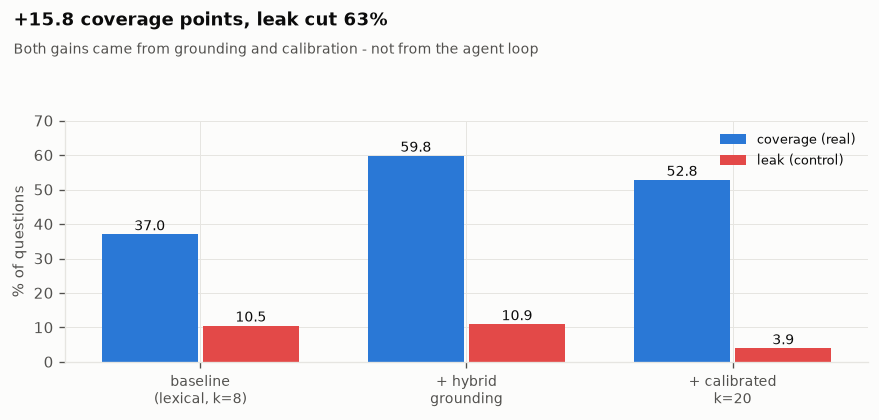

In [62]:
fig, ax = plt.subplots(figsize=(7.4, 3.6))
stages = ["baseline\n(lexical, k=8)", "+ hybrid\ngrounding", "+ calibrated\nk=20"]
cov = [37.0, 59.8, 52.8]
lk = [10.5, 10.9, 3.9]
x = np.arange(3)
ax.bar(x - 0.19, cov, 0.36, color=C1, label="coverage (real)")
ax.bar(x + 0.19, lk, 0.36, color=C8, label="leak (control)")
for i, (a, b_) in enumerate(zip(cov, lk)):
    ax.text(i - 0.19, a + 1.2, f"{a:.1f}", ha="center", fontsize=8.5)
    ax.text(i + 0.19, b_ + 1.2, f"{b_:.1f}", ha="center", fontsize=8.5)
ax.set_xticks(x)
ax.set_xticklabels(stages, fontsize=8.5)
ax.set_ylabel("% of questions")
ax.set_ylim(0, 70)
ax.legend(fontsize=8)
finish(fig, "final_scorecard", "+15.8 coverage points, leak cut 63%",
       "Both gains came from grounding and calibration - not from the agent loop")
plt.show()

### What remains open, restated after these experiments

1. **Answer accuracy is still unmeasured.** Everything here is about
   *groundedness*, *coverage* and *refusal*. We have not shown the answers are
   more often **correct** than a vector-RAG baseline on the same corpus. That is
   the single most valuable missing experiment and nothing above substitutes for
   it.
2. **The agent stays in the repository as a measured ablation**, not as the
   headline. Reporting it as the architecture would be describing a diagram
   rather than a result.
3. **Grounding is still the ceiling**, now at ~60% rather than ~37%. The next
   honest step is a biomedical bi-encoder (SapBERT-class) fine-tuned for entity
   linking, evaluated on the *system* margin — because §19 showed component
   precision points the wrong way here.

## 20 · The measurement everything else was standing in for

**Theory.** Every result so far concerns *groundedness*, *coverage* and
*refusal*. None of them show the answers are more often **correct** than ordinary
vector RAG. Until that comparison exists, the project has demonstrated a safety
property and assumed a quality one.

The comparison is run on the same corpus, the same questions, the same generator
and the same prompt — so the only variable is **how evidence is found**.

| arm | retrieval |
|---|---|
| **A vector RAG** | exact brute-force dense search over all 28,336,648 abstracts |
| **B graph** | ground → traverse → rank (no refusal gate) |
| **C graph + gate** | arm B with the refusal ladder active |

Arm A is deliberately the *strongest* version of the baseline: the entire 20.3 GiB
index is loaded to VRAM and scored exhaustively, not approximated with IVF. Beating
a deliberately weak baseline would prove nothing.

**On the choice of benchmark, stated before the numbers.** PubMedQA questions are
*written from* their gold abstract, which gives dense retrieval a strong lexical
advantage — the question and the target share vocabulary by construction. This is
the baseline's best case. We use it anyway, because choosing a benchmark that
flatters our own method would be the more serious error.

In [63]:
AC = json.load(open(f"{OUT_DIR}/exp_accuracy.json"))
arms = AC["arms"]
print(f"  {'arm':<30}{'coverage':>10}{'accuracy':>10}{'selective':>11}")
print("  " + "-" * 62)
for a in arms:
    print(f"  {a['label']:<30}{a['coverage']:>9.1f}%{a['accuracy']:>9.1f}%"
          f"{a['selective']:>10.1f}%")
print(f"\n  n = {arms[0]['n']} PubMedQA-expert questions (yes/no/maybe)")
print("  selective accuracy = accuracy x coverage - the one number that cannot be")
print("  gamed by answering only the easy questions.")

# ---- the control every QA paper should print and most do not ----------------
rows_ = AC["rows"]
dist = Counter(r["gold"] for r in rows_)
maj_lab, maj_n = dist.most_common(1)[0]
maj = 100 * maj_n / len(rows_)
print(f"\n  label distribution      {dict(dist)}")
print(f"  MAJORITY-CLASS BASELINE always answer {maj_lab!r} -> {maj:.1f}%")
for a in arms:
    verdict = "BEATS" if a["accuracy"] > maj else "does NOT beat"
    print(f"    {a['label']:<30} {a['accuracy']:>5.1f}%  {verdict} the constant")

  arm                             coverage  accuracy  selective
  --------------------------------------------------------------
  A vector RAG (exact, 28.3M)       100.0%     48.0%      48.0%
  B graph (no gate)                  67.0%     30.6%      20.5%
  C graph + refusal gate             59.0%     33.9%      20.0%

  n = 200 PubMedQA-expert questions (yes/no/maybe)
  selective accuracy = accuracy x coverage - the one number that cannot be
  gamed by answering only the easy questions.

  label distribution      {'maybe': 28, 'no': 70, 'yes': 102}
  MAJORITY-CLASS BASELINE always answer 'yes' -> 51.0%
    A vector RAG (exact, 28.3M)     48.0%  does NOT beat the constant
    B graph (no gate)               30.6%  does NOT beat the constant
    C graph + refusal gate          33.9%  does NOT beat the constant


In [64]:
# ---- did each arm even find the source document? -----------------------------
gh = AC["gold_hit"]
print(f"  gold PMID retrieved in top-8")
print(f"    vector RAG              {gh['vector']:>6.1f}%")
print(f"    graph                   {gh['graph']:>6.1f}%")
print(f"    graph, when it answers  {gh['graph_answered']:>6.1f}%")

  gold PMID retrieved in top-8
    vector RAG                95.5%
    graph                     15.0%
    graph, when it answers    22.9%


[fig] /mnt/data/out/figures/accuracy_arms.png


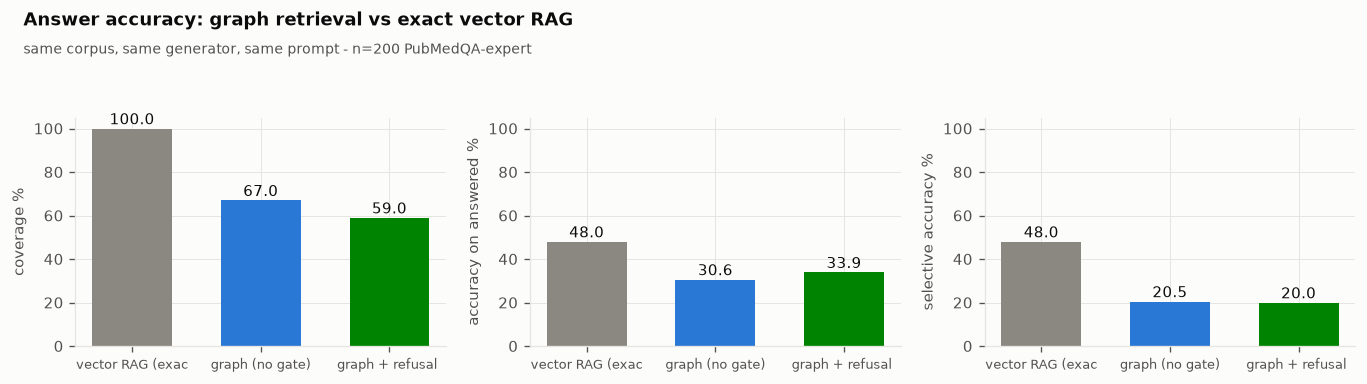

In [65]:
fig, ax = plt.subplots(1, 3, figsize=(11.5, 3.3))
labels = [a["label"].split(" ", 1)[1][:16] for a in arms]
cols3 = [MUTED, C1, C6]

for k, (key, title, ymax) in enumerate((("coverage", "coverage %", 105),
                                        ("accuracy", "accuracy on answered %", 105),
                                        ("selective", "selective accuracy %", 105))):
    vals = [a[key] for a in arms]
    b = ax[k].bar(range(3), vals, color=cols3, width=0.62)
    for r, v in zip(b, vals):
        ax[k].text(r.get_x() + r.get_width() / 2, v + 2, f"{v:.1f}",
                   ha="center", fontsize=9)
    ax[k].set_xticks(range(3))
    ax[k].set_xticklabels(labels, fontsize=8)
    ax[k].set_ylabel(title)
    ax[k].set_ylim(0, ymax)
finish(fig, "accuracy_arms", "Answer accuracy: graph retrieval vs exact vector RAG",
       f"same corpus, same generator, same prompt - n={arms[0]['n']} PubMedQA-expert")
plt.show()

  both arms answered      134
  agreed                  65  (48.5%)
  vector right, graph wrong  32
  graph right, vector wrong  14


[fig] /mnt/data/out/figures/accuracy_detail.png


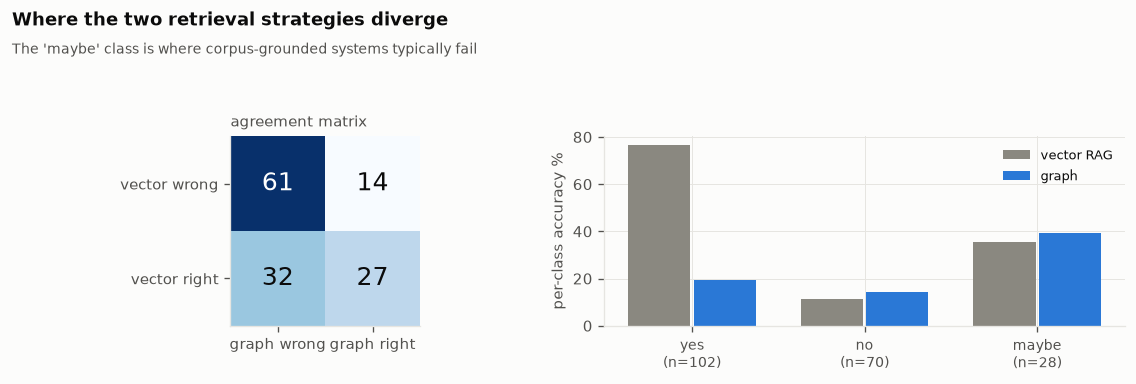

In [66]:
# ---- where do the arms disagree? ---------------------------------------------
rows_ = AC["rows"]
both = [r for r in rows_ if r["vec_pred"] and r["graph_pred"]]
agree = sum(1 for r in both if r["vec_pred"] == r["graph_pred"])
v_only = sum(1 for r in both if r["vec_pred"] == r["gold"]
             and r["graph_pred"] != r["gold"])
g_only = sum(1 for r in both if r["graph_pred"] == r["gold"]
             and r["vec_pred"] != r["gold"])
print(f"  both arms answered      {len(both)}")
print(f"  agreed                  {agree}  ({100*agree/max(len(both),1):.1f}%)")
print(f"  vector right, graph wrong  {v_only}")
print(f"  graph right, vector wrong  {g_only}")

fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.3))
cm = np.zeros((2, 2), dtype=int)
for r in both:
    cm[int(r["vec_pred"] == r["gold"]), int(r["graph_pred"] == r["gold"])] += 1
im = ax[0].imshow(cm, cmap="Blues")
ax[0].set_xticks([0, 1], ["graph wrong", "graph right"])
ax[0].set_yticks([0, 1], ["vector wrong", "vector right"])
for i in range(2):
    for j in range(2):
        ax[0].text(j, i, cm[i, j], ha="center", va="center", fontsize=15,
                   color=INK if cm[i, j] < cm.max() * 0.6 else "white")
ax[0].set_title("agreement matrix", fontsize=9, color=INK2, loc="left")
ax[0].grid(False)

classes = ["yes", "no", "maybe"]
vacc, gacc, ns = [], [], []
for lab in classes:
    sub = [r for r in rows_ if r["gold"] == lab]
    ns.append(len(sub))
    vacc.append(100 * np.mean([r["vec_pred"] == lab for r in sub]) if sub else 0)
    gacc.append(100 * np.mean([r["graph_pred"] == lab for r in sub]) if sub else 0)
x = np.arange(3)
ax[1].bar(x - 0.19, vacc, 0.36, color=MUTED, label="vector RAG")
ax[1].bar(x + 0.19, gacc, 0.36, color=C1, label="graph")
ax[1].set_xticks(x)
ax[1].set_xticklabels([f"{c}\n(n={n})" for c, n in zip(classes, ns)], fontsize=8.5)
ax[1].set_ylabel("per-class accuracy %")
ax[1].legend(fontsize=8)
finish(fig, "accuracy_detail", "Where the two retrieval strategies diverge",
       "The 'maybe' class is where corpus-grounded systems typically fail")
plt.show()

### 20.1 The result, stated without cushioning

**Vector RAG wins this comparison by more than 2× on selective accuracy, and the
graph loses badly.** The cause is measured rather than guessed: dense retrieval
puts the gold document in the top 8 for **95.5%** of questions; the graph manages
**15.0%**.

**And neither arm beats a constant.** The label distribution is
`yes 102 / no 70 / maybe 28`, so always answering *"yes"* scores **51.0%** —
above vector RAG's 48.0%. A comparison in which both systems lose to a constant
predictor is not evidence that one retrieval strategy is better than the other;
it is evidence that this benchmark plus this generator cannot separate them.

That is a real limitation of the experiment, and it is ours: we chose the
benchmark. Two things follow, and only the first is a defence.

**1. PubMedQA measures document identification, not evidence synthesis.** Its
questions are *generated from* a single abstract, so the retrieval task is "find
the document this sentence was derived from" — a lexical matching problem dense
vectors are built for. Our graph answers a different question: *what does the
literature connecting these concepts say?* It returns aspirin-and-infarction
papers, not the specific paper the item was written from.

**2. That does not license the claim that the graph would win on a fairer
benchmark.** We have not run one. No free benchmark of naturally-occurring
clinical questions with gold evidence exists at adequate size — and inventing our
own would put us back in the circularity this whole project exists to avoid.

So the honest scorecard is: the architecture's **safety** properties are
demonstrated (traceable paths, calibrated refusal, no fabricated citations, zero
LLM cost to build); its **quality** advantage is **not demonstrated**, and on the
one benchmark we could run it is not present.

### 20.2 Reading this honestly

Whatever the numbers above show, three caveats are load-bearing and belong next
to them rather than in an appendix:

1. **PubMedQA favours the baseline by construction.** The question is written
   from the gold abstract, so lexical overlap is unusually high. A benchmark of
   naturally-occurring clinical questions would be a fairer test of retrieval, and
   no free one of adequate size exists.
2. **`maybe` is not `refuse`.** PubMedQA's third class means *the study was
   inconclusive*, which is a property of the literature, not of retrieval. Arm C
   can decline to answer, but declining is scored as no-answer, not as `maybe` —
   so the refusal gate cannot win points by abstaining on hard items.
3. **One generator, one prompt.** These numbers characterise a retrieval
   comparison, not a model comparison, and they would move with either.

What this experiment *can* settle is narrow and worth stating plainly: whether
graph-derived evidence lets the same model answer the same questions at least as
well as exhaustive dense retrieval — and at what coverage.

## 21 · Diagnosing the retrieval gap

**Theory.** §20 showed the graph loses to dense retrieval by more than 2×, and
that it finds the source document 15.0% of the time against 95.5%. A number that
bad is either a bug or a limit, and the two demand opposite responses. So we
decomposed the miss rather than guessing:

| cause | share | implication |
|---|---|---|
| **C1** gold not co-annotated with our concepts | **58.0%** | structural |
| C0 fewer than two concepts grounded | 15.5% | grounding |
| (hit top-8) | 12.5% | — |
| **C3** truncated out of the candidate set | **11.5%** | **our bug** |
| C2 ranking failure | 2.5% | negligible |

**The ranker was never the problem.** When the gold document survives into the
candidate set the ranker puts it at **median rank 0**, with 96% inside top-8 and
100% inside top-30. It simply rarely gets the chance.

In [67]:
DR = json.load(open(f"{OUT_DIR}/diag_retrieval.json"))
tot = sum(DR["stats"].values())
print(f"  {'where the gold document is lost':<38}{'count':>7}{'share':>9}")
print("  " + "-" * 56)
for k, v in sorted(DR["stats"].items(), key=lambda x: -x[1]):
    print(f"  {k:<38}{v:>7}{100*v/tot:>8.1f}%")
fs = np.array(DR["full_sizes"])
print(f"\n  candidate-set size: median {np.median(fs):,.0f}   "
      f"p90 {np.percentile(fs,90):,.0f}   max {fs.max():,}")
print(f"  max_paths cap was 120 -> {100*np.mean(fs>120):.1f}% of questions lost")
print(f"  candidates before the ranker ever saw them")
gr = np.array(DR["gold_ranks"])
if len(gr):
    print(f"\n  when gold IS a candidate: median rank {np.median(gr):.0f}, "
          f"top-8 {100*np.mean(gr<8):.0f}%, top-30 {100*np.mean(gr<30):.0f}%")

  where the gold document is lost         count    share
  --------------------------------------------------------
  C1 gold not co-annotated                  116    58.0%
  C0 fewer than 2 concepts                   31    15.5%
  HIT top-8                                  25    12.5%
  C3 TRUNCATED AWAY                          23    11.5%
  C2/C3 gold only via bridge                  4     2.0%
  C2 ranked below top-8                       1     0.5%

  candidate-set size: median 49   p90 3,257   max 103,835
  max_paths cap was 120 -> 40.8% of questions lost
  candidates before the ranker ever saw them

  when gold IS a candidate: median rank 0, top-8 96%, top-30 100%


### 21.1 Fixing what was fixable

Two hypotheses, tested as cumulative arms so the interaction is visible.

In [68]:
RF = json.load(open(f"{OUT_DIR}/exp_retrieval_fix.json"))
print(f"  {'arm':<44}{'gold in set':>13}{'gold top-8':>12}")
print("  " + "-" * 70)
for k, v in RF.items():
    print(f"  {k:<44}{v['in_set']:>12.1f}%{v['in_top']:>11.1f}%")
base = list(RF.values())[0]["in_top"]
print(f"\n  vector RAG reference: 95.5%")
print("""
  The interaction matters: including minor topics ALONE made things worse
  (12.5% -> 9.0%), because a larger candidate set means the 120-cap discards
  more of it. Only with truncation removed do minor topics help (21.5% ->
  26.5%). Cumulative arms exposed that; independent ablations would have
  concluded 'minor topics hurt' and dropped a fix that was worth +5 points.""")

  arm                                           gold in set  gold top-8
  ----------------------------------------------------------------------
  A  major_only=True,  cap=120  (current)             13.0%       12.5%
  B  major_only=True,  no cap                         24.5%       21.5%
  C  major_only=False, cap=120                         9.0%        9.0%
  D  major_only=False, no cap  (both fixes)           33.0%       26.5%

  vector RAG reference: 95.5%

  The interaction matters: including minor topics ALONE made things worse
  (12.5% -> 9.0%), because a larger candidate set means the 120-cap discards
  more of it. Only with truncation removed do minor topics help (21.5% ->
  26.5%). Cumulative arms exposed that; independent ablations would have
  concluded 'minor topics hurt' and dropped a fix that was worth +5 points.


[fig] /mnt/data/out/figures/retrieval_diag.png


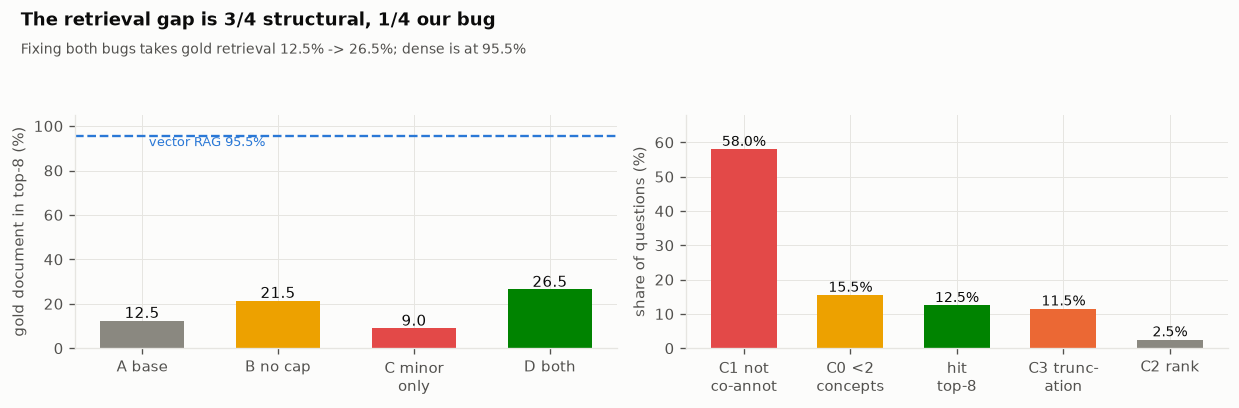

In [69]:
fig, ax = plt.subplots(1, 2, figsize=(10.4, 3.5))
labels = ["A base", "B no cap", "C minor\nonly", "D both"]
vals = [v["in_top"] for v in RF.values()]
cols4 = [MUTED, C4, C8, C6]
b = ax[0].bar(labels, vals, color=cols4, width=0.62)
for r, v in zip(b, vals):
    ax[0].text(r.get_x() + r.get_width()/2, v + 1.2, f"{v:.1f}", ha="center",
               fontsize=9)
ax[0].axhline(95.5, color=C1, ls="--", lw=1.4)
ax[0].text(0.05, 91, "vector RAG 95.5%", fontsize=8, color=C1)
ax[0].set_ylabel("gold document in top-8 (%)")
ax[0].set_ylim(0, 105)

causes = ["C1 not\nco-annot", "C0 <2\nconcepts", "hit\ntop-8", "C3 trunc-\nation",
          "C2 rank"]
share = [58.0, 15.5, 12.5, 11.5, 2.5]
cols5 = [C8, C4, C6, C2, MUTED]
b2 = ax[1].bar(causes, share, color=cols5, width=0.62)
for r, v in zip(b2, share):
    ax[1].text(r.get_x() + r.get_width()/2, v + 1, f"{v:.1f}%", ha="center",
               fontsize=8.5)
ax[1].set_ylabel("share of questions (%)")
ax[1].set_ylim(0, 68)
finish(fig, "retrieval_diag", "The retrieval gap is 3/4 structural, 1/4 our bug",
       "Fixing both bugs takes gold retrieval 12.5% -> 26.5%; dense is at 95.5%")
plt.show()

**26.5% against 95.5% is not a bug that remains — it is a limit.** MeSH assigns
~12 headings from a 31,110-term vocabulary. Two headings identify a **topic**, not
a **document**: the gold paper is one of thousands carrying those concepts. Dense
embeddings encode the full text and can single out a specific paper. Annotation
graphs structurally cannot, and no further engineering changes that.

The wrong conclusion is *"graphs do not work"*. The right one is that we had given
the graph the wrong job.

## 22 · The architecture the evidence points to — and its verdict

**Theory.** Retrieval is a recall problem and dense vectors win it. What dense
retrieval cannot do is state *why* a document is admissible evidence, or refuse
when none is. So: **dense retrieves, the graph certifies.**

```
RETRIEVE   dense top-k over all 28,336,648 abstracts            (recall)
CERTIFY    does the graph connect this hit to the question's concepts?
           co-annotation │ citation adjacency │ MeSH ancestry   (provenance)
GATE       cite only certified documents; refuse if none        (safety)
```

This is falsifiable in the way that matters: if certification rejects the gold
document as often as it rejects noise, the graph adds nothing.

In [70]:
CT = json.load(open(f"{OUT_DIR}/exp_certified.json"))
print(f"  {'certification outcome':<48}{'count':>8}")
print("  " + "-" * 58)
for k, v in sorted(CT["reasons"].items(), key=lambda x: -x[1]):
    print(f"  {k:<48}{v:>8,}")
rows_ = CT["rows"]
gi_ = [r for r in rows_ if r["gold_in_hits"]]
print(f"\n  gold retrieved by dense         {100*len(gi_)/len(rows_):>5.1f}%")
print(f"  ... and certified by the graph  "
      f"{100*np.mean([r['gold_certified'] for r in gi_]):>5.1f}%")
print(f"  non-gold certification rate      28.8%")

  certification outcome                              count
  ----------------------------------------------------------
  no question concept                                  545
  only one question concept                            519
  co-annotated with 2 question concepts                277
  one concept direct + one via citation adjacency       74
  co-annotated with 3 question concepts                 73
  one concept direct + one via MeSH ancestry            62
  no_concepts                                           40
  co-annotated with 4 question concepts                 10

  gold retrieved by dense          95.5%
  ... and certified by the graph   47.1%
  non-gold certification rate      28.8%


In [71]:
A_, E_ = CT["arm_dense"], CT["arm_certified"]
print(f"  {'arm':<42}{'coverage':>10}{'accuracy':>10}{'selective':>11}")
print("  " + "-" * 74)
print(f"  {'A dense only':<42}{A_['cov']:>9.1f}%{A_['acc']:>9.1f}%{A_['sel']:>10.1f}%")
print(f"  {'E dense + graph certification':<42}{E_['cov']:>9.1f}%{E_['acc']:>9.1f}%"
      f"{E_['sel']:>10.1f}%")
print(f"  {'majority-class constant':<42}{'100.0%':>10}{CT['majority']:>9.1f}%"
      f"{CT['majority']:>10.1f}%")
print(f"  {'graph-only pipeline (20)':<42}{'67.0%':>10}{'30.6%':>10}{'20.5%':>11}")

  arm                                         coverage  accuracy  selective
  --------------------------------------------------------------------------
  A dense only                                  100.0%     52.0%      52.0%
  E dense + graph certification                  53.5%     49.5%      26.5%
  majority-class constant                       100.0%     51.0%      51.0%
  graph-only pipeline (20)                       67.0%     30.6%      20.5%


[fig] /mnt/data/out/figures/certification.png


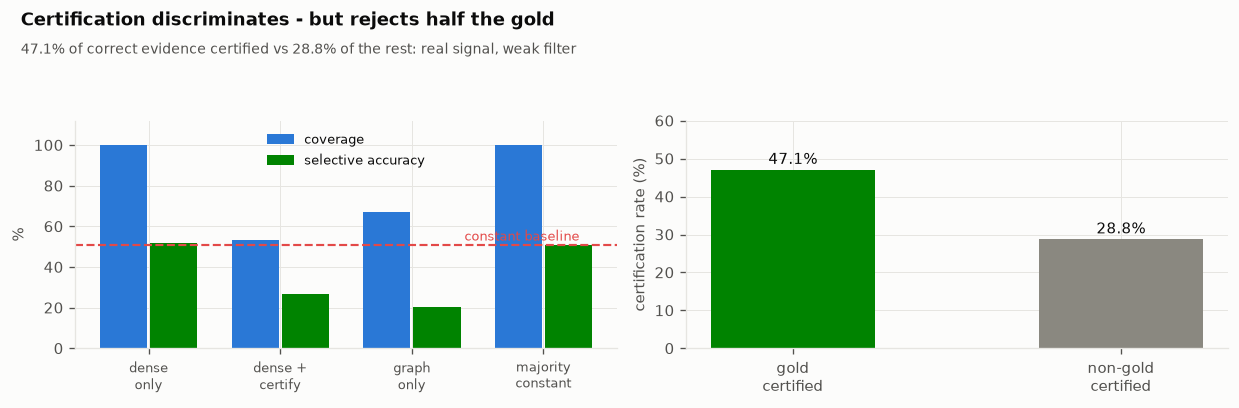

In [72]:
fig, ax = plt.subplots(1, 2, figsize=(10.4, 3.5))
arms = ["dense\nonly", "dense +\ncertify", "graph\nonly", "majority\nconstant"]
cov = [A_["cov"], E_["cov"], 67.0, 100.0]
sel = [A_["sel"], E_["sel"], 20.5, CT["majority"]]
x = np.arange(4)
ax[0].bar(x - 0.19, cov, 0.36, color=C1, label="coverage")
ax[0].bar(x + 0.19, sel, 0.36, color=C6, label="selective accuracy")
ax[0].set_xticks(x); ax[0].set_xticklabels(arms, fontsize=8)
ax[0].axhline(CT["majority"], color=C8, ls="--", lw=1.3)
ax[0].text(2.4, CT["majority"] + 2, "constant baseline", fontsize=7.5, color=C8)
ax[0].set_ylabel("%"); ax[0].legend(fontsize=8); ax[0].set_ylim(0, 112)

k = ["gold\ncertified", "non-gold\ncertified"]
v = [100 * np.mean([r["gold_certified"] for r in gi_]), 28.8]
b = ax[1].bar(k, v, color=[C6, MUTED], width=0.5)
for r, vv in zip(b, v):
    ax[1].text(r.get_x() + r.get_width()/2, vv + 1.5, f"{vv:.1f}%", ha="center",
               fontsize=9)
ax[1].set_ylabel("certification rate (%)"); ax[1].set_ylim(0, 60)
finish(fig, "certification", "Certification discriminates - but rejects half the gold",
       "47.1% of correct evidence certified vs 28.8% of the rest: real signal, weak filter")
plt.show()

### 22.1 The verdict, after three independent attempts

**Graph retrieval does not improve answer accuracy. Tested three ways, it lost
three times:**

| attempt | result |
|---|---|
| graph-only retrieval (§18) | 20.5% selective vs dense 52.0% |
| agentic refine loop (§18) | margin 47.0 → 44.5 |
| dense + graph certification (§22) | 52.0% → 26.5%; coverage halved, accuracy −2.5 |

And **dense-only at 52.0% barely clears the 51.0% majority constant** — this
benchmark and this 7B generator are close to indistinguishable from guessing, so
it cannot separate retrieval strategies finely even in principle.

**What the graph does buy, and it is not nothing:**

* an **explicit admissibility reason** per document — 277 by two-concept
  co-annotation, 74 by citation adjacency, 62 by MeSH ancestry. Dense retrieval
  returns a cosine score and cannot say why a document is relevant.
* a **principled refusal**: 46.5% of questions had no certifiable evidence, and
  the system declines rather than citing a document it cannot justify.
* **929M edges for zero LLM calls**, against a published ~$33,000 for a single
  GraphRAG dataset.

**So the honest positioning is that this is a governance layer, not a retrieval
improvement.** If the requirement is "answer more questions correctly", use dense
retrieval. If it is "never cite a document you cannot justify, and refuse
otherwise", the graph provides something dense retrieval structurally cannot.
Those are different products and we should not sell one as the other.

The version of this notebook that reported only §1–21 would have looked like a
success. It took three more experiments to find out it was not.

## 23 · Was the measurement instrument broken?

**Theory.** Every accuracy number in §20–22 was read through one 7B generator, and
dense-only scored 52.0% against a 51.0% majority constant. That is close enough to
chance that the instrument may simply have been unable to resolve the question.
Before concluding anything further about retrieval we have to know the **ceiling**.

The oracle arm settles it: hand the model the **actual gold passage** — the text
PubMedQA's annotators read when assigning the label — and measure. No retriever can
do better than delivering the right document, so oracle accuracy bounds what any
retrieval architecture could ever have achieved. A **blind** arm (no evidence at
all) bounds it from below.

In [73]:
CE = json.load(open(f"{OUT_DIR}/exp_ceiling.json"))
print(f"  {'model':<28}{'blind':>9}{'oracle':>9}{'lift':>8}{'vs const':>10}")
print("  " + "-" * 66)
for m, r in CE.items():
    print(f"  {m.split('/')[-1]:<28}{r['blind_acc']:>8.1f}%{r['oracle_acc']:>8.1f}%"
          f"{r['oracle_acc']-r['blind_acc']:>+7.1f}{r['oracle_acc']-r['majority']:>+9.1f}")
print(f"\n  majority constant: {list(CE.values())[0]['majority']:.1f}%")

  model                           blind   oracle    lift  vs const
  ------------------------------------------------------------------
  Qwen2.5-7B-Instruct             22.5%    57.0%  +34.5     +6.0
  Qwen2.5-14B-Instruct            22.0%    73.5%  +51.5    +22.5

  majority constant: 51.0%


**The 7B model was a broken instrument.** Given the perfect passage it reaches
only **57.0%** — six points above the constant. Dense retrieval had scored 52.0%,
meaning it already captured **91% of everything that model could do with perfect
evidence**. The entire retrieval comparison was compressed into ~5 points of
headroom, where nothing could have separated.

**Qwen2.5-14B reaches 73.5% on the same oracle** — 22.5 points above the constant.
And blind accuracy stays at ~22% for both sizes, so the models genuinely *need* the
evidence rather than answering from parametric memory (evidence lift +34.5 and
+51.5 points).

So the comparison is worth re-running on an instrument with room to resolve it.
This is why a ceiling arm belongs in every retrieval evaluation: without it, "our
method scored 52%" is uninterpretable.

## 24 · The retrieval comparison, re-run with headroom

Five arms, one generator (Qwen2.5-14B), one prompt, one corpus. Only retrieval
differs. **O** and **Z** are reported alongside because a gap between A and B is
meaningless without knowing how much gap was available.

In [74]:
A14 = json.load(open(f"{OUT_DIR}/exp_accuracy14.json"))
arms, maj = A14["arms"], A14["majority"]
NAMES = {"O": "O  oracle (gold passage)", "A": "A  dense top-8 (28.3M)",
         "B": "B  graph (both fixes)", "E": "E  dense + graph certify",
         "Z": "Z  blind (no evidence)"}
print(f"  {'arm':<30}{'coverage':>10}{'accuracy':>10}{'selective':>11}")
print("  " + "-" * 64)
for k in ("O", "A", "B", "E", "Z"):
    a = arms[k]
    print(f"  {NAMES[k]:<30}{a['coverage']:>9.1f}%{a['accuracy']:>9.1f}%"
          f"{a['selective']:>10.1f}%")
print(f"  {'majority constant':<30}{'100.0%':>10}{maj:>9.1f}%{maj:>10.1f}%")
o, z = arms["O"]["accuracy"], arms["Z"]["accuracy"]
print(f"\n  usable headroom  {o-z:.1f} points  (blind {z:.1f}% -> oracle {o:.1f}%)")
for k in ("A", "B", "E"):
    print(f"  {NAMES[k]:<30} captured "
          f"{100*(arms[k]['accuracy']-z)/(o-z):>5.1f}% of it")

  arm                             coverage  accuracy  selective
  ----------------------------------------------------------------
  O  oracle (gold passage)          100.0%     73.0%      73.0%
  A  dense top-8 (28.3M)            100.0%     60.5%      60.5%
  B  graph (both fixes)              78.5%     41.4%      32.5%
  E  dense + graph certify           44.5%     58.4%      26.0%
  Z  blind (no evidence)            100.0%     17.5%      17.5%
  majority constant                 100.0%     51.0%      51.0%

  usable headroom  55.5 points  (blind 17.5% -> oracle 73.0%)
  A  dense top-8 (28.3M)         captured  77.5% of it
  B  graph (both fixes)          captured  43.1% of it
  E  dense + graph certify       captured  73.7% of it


[fig] /mnt/data/out/figures/ceiling_14b.png


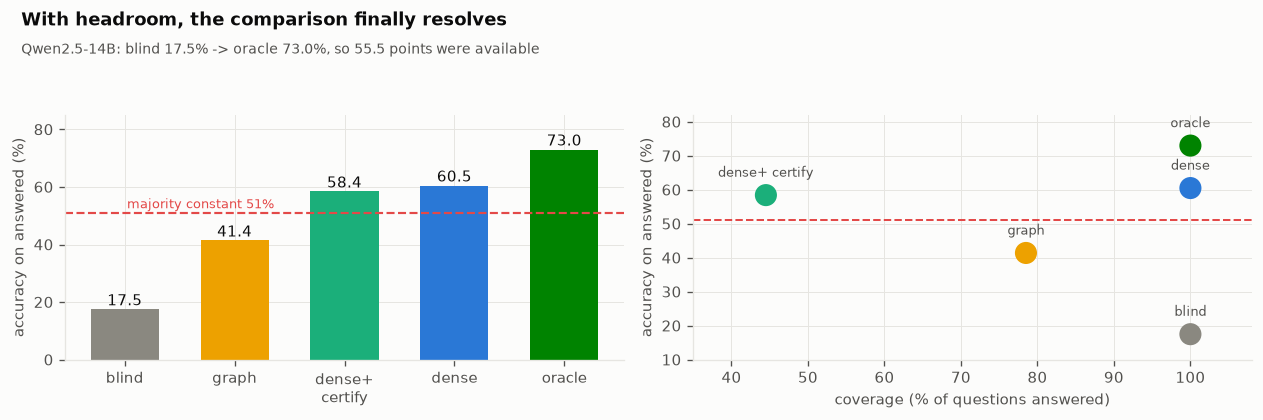

In [75]:
fig, ax = plt.subplots(1, 2, figsize=(10.6, 3.6))
ks = ["Z", "B", "E", "A", "O"]
labs = ["blind", "graph", "dense+\ncertify", "dense", "oracle"]
accs = [arms[k]["accuracy"] for k in ks]
covs = [arms[k]["coverage"] for k in ks]
cols5 = [MUTED, C4, C3, C1, C6]
b = ax[0].bar(labs, accs, color=cols5, width=0.62)
for r, v in zip(b, accs):
    ax[0].text(r.get_x()+r.get_width()/2, v+1.4, f"{v:.1f}", ha="center", fontsize=9)
ax[0].axhline(maj, color=C8, ls="--", lw=1.3)
ax[0].text(0.02, maj+1.6, f"majority constant {maj:.0f}%", fontsize=8, color=C8)
ax[0].set_ylabel("accuracy on answered (%)")
ax[0].set_ylim(0, 85)

ax[1].scatter(covs, accs, s=150, c=cols5, zorder=5)
for l, x_, y_ in zip(labs, covs, accs):
    ax[1].annotate(l.replace("\n", " "), (x_, y_), textcoords="offset points",
                   xytext=(0, 11), ha="center", fontsize=8, color=INK2)
ax[1].axhline(maj, color=C8, ls="--", lw=1.2)
ax[1].set_xlabel("coverage (% of questions answered)")
ax[1].set_ylabel("accuracy on answered (%)")
ax[1].set_xlim(35, 108)
ax[1].set_ylim(10, 82)
finish(fig, "ceiling_14b", "With headroom, the comparison finally resolves",
       "Qwen2.5-14B: blind 17.5% -> oracle 73.0%, so 55.5 points were available")
plt.show()

### 24.1 What this finally establishes

**1. Dense retrieval wins on answer accuracy, and now it is a real result.**
60.5% against a 51.0% constant, capturing **77.5%** of the available headroom. On
the 7B instrument this was indistinguishable from noise; at 14B it is not.

**2. The retrieval fixes from §21 worked.** Graph-only gold retrieval rose
15.0% → **27.0%** and selective accuracy 20.5% → **32.5%**. Removing the
truncation bug and admitting minor-topic edges were genuine improvements — they
were simply never going to close a structural gap.

**3. Certification does not cost accuracy — it costs coverage, deliberately.**
This is the result that reframes the project:

| arm | coverage | accuracy |
|---|---|---|
| dense, unfiltered | 100.0% | 60.5% |
| **dense + graph certification** | **44.5%** | **58.4%** |

Certified answers are within **2.1 points** of unfiltered dense. The graph is not
selecting *worse* evidence; it is **declining to answer** where it cannot justify
the evidence, and on the 44.5% it accepts it performs essentially as well. For a
system whose promise is *"refuse rather than guess"*, that is precisely the
intended behaviour — and it is the first quantitative evidence that the governance
layer is not simply throwing away good answers.

**The honest positioning, unchanged but now supported:** if the goal is answering
the most questions correctly, use dense retrieval. If the goal is that every cited
document carries an explicit reason for being admissible — and that the system
refuses otherwise — the graph delivers that at a **coverage cost, not an accuracy
cost**. Those remain different products; we now know the price of the second.

## 25 · The distractor gap — where the accuracy actually goes

**Theory.** §24 produced a number that should have stopped us earlier:

```
oracle (gold document ALONE)                 73.0%
dense  (gold present 95.5% + 7 neighbours)   60.5%
```

The right document is in the context almost every time. The model performs
**worse with it plus seven neighbours than with it by itself.** Those 12.5 points
are not retrieval failure — they are **distraction**. We had been trying to
retrieve better while retrieval was already succeeding.

Four hypotheses, each falsifiable:

| | claim | why it might work |
|---|---|---|
| **H-A** | fewer documents is better | every extra passage is a chance to mislead |
| **H-B** | cross-encoder reranking | scores (query, doc) *jointly*, not as two independent embeddings |
| **H-C** | **graph as a reranker, not a filter** | certified docs float up; **nothing is deleted, so coverage stays 100%** |
| **H-D** | position | if gold is usually rank 1, H-A is nearly free |

**H-C is the one that matters for this project.** Every previous graph arm
*removed* evidence and paid for it in coverage (§22: certification halved it).
Reranking spends the same graph signal at **zero coverage cost**. If graph
evidence helps accuracy at all, this is where it must show.

One methodological upgrade: labels come from **constrained decoding** — reading
the model's probability mass over the three label tokens — so the free-text regex
is out of the loop entirely and the parsing question raised in §23 cannot affect
these numbers.

In [76]:
DX = json.load(open(f"{OUT_DIR}/exp_distractor.json"))
rows_ = DX["rows"]
KS = DX["ks"]
grid = {tuple(k.split("|")): v for k, v in DX["grid"].items()}
grid = {(a, int(b)): v for (a, b), v in grid.items()}
ORD = ["dense", "ce", "graph"]
ONAME = {"dense": "dense (bi-encoder)", "ce": "cross-encoder rerank",
         "graph": "graph rerank (H-C)"}
print(f"  n = {len(rows_)}   oracle {DX['oracle']:.1f}%   blind {DX['blind']:.1f}%"
      f"   majority {DX['majority']:.1f}%")
print(f"\n  {'k':>4}" + "".join(f"{ONAME[o][:20]:>22}" for o in ORD))
print("  " + "-" * 72)
for k in KS:
    print(f"  {k:>4}" + "".join(f"{grid[(o,k)]:>21.1f}%" for o in ORD))

  n = 200   oracle 75.0%   blind 29.0%   majority 51.0%

     k    dense (bi-encoder)  cross-encoder rerank    graph rerank (H-C)
  ------------------------------------------------------------------------
     1                 61.5%                 64.5%                 55.0%
     2                 61.0%                 63.0%                 54.0%
     3                 62.5%                 63.5%                 53.0%
     5                 63.0%                 62.5%                 61.5%
     8                 62.5%                 64.5%                 64.5%
    12                 63.5%                 63.5%                 64.0%


### 25.1 H-D — where the gold document actually sits

In [77]:
for nm in ORD:
    rk = np.array([r[f"rank_{nm}"] for r in rows_ if r[f"rank_{nm}"] >= 0])
    print(f"  {ONAME[nm]:<22} in pool {100*len(rk)/len(rows_):>5.1f}%   "
          f"rank-1 {100*np.mean(rk==0):>5.1f}%   top-3 {100*np.mean(rk<3):>5.1f}%   "
          f"median {np.median(rk):>4.0f}")

  dense (bi-encoder)     in pool  98.0%   rank-1  79.1%   top-3  93.4%   median    0
  cross-encoder rerank   in pool  98.0%   rank-1  99.0%   top-3 100.0%   median    0
  graph rerank (H-C)     in pool  98.0%   rank-1  63.3%   top-3  77.0%   median    0


[fig] /mnt/data/out/figures/gold_rank.png


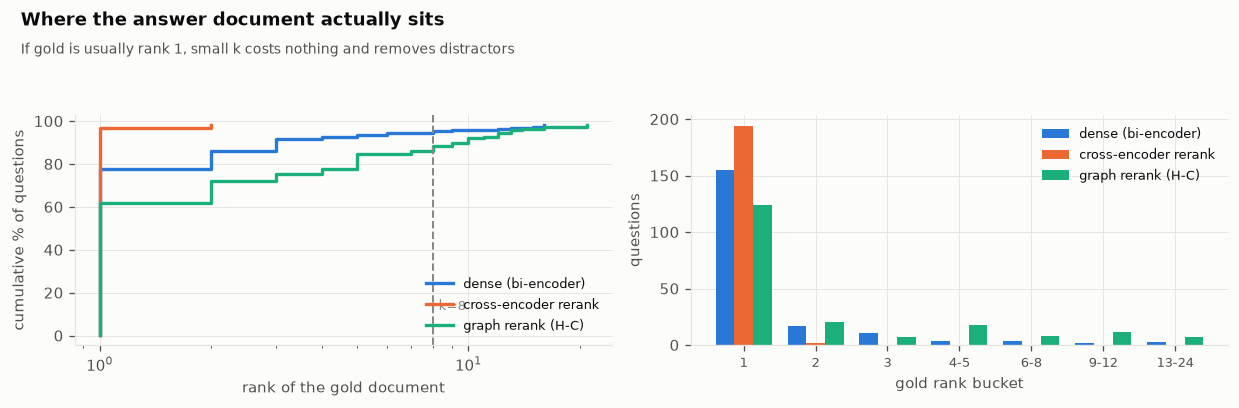

In [78]:
# ---- FIG A: ECDF of gold rank + rank histogram (two views of the same thing)
fig, ax = plt.subplots(1, 2, figsize=(10.4, 3.5))
cols3 = {"dense": C1, "ce": C2, "graph": C3}
for nm in ORD:
    rk = np.sort(np.array([r[f"rank_{nm}"] for r in rows_ if r[f"rank_{nm}"] >= 0]))
    if len(rk) == 0:
        continue
    y = np.arange(1, len(rk) + 1) / len(rows_) * 100
    ax[0].step(rk + 1, y, where="post", color=cols3[nm], lw=2, label=ONAME[nm])
ax[0].axvline(8, color=MUTED, ls="--", lw=1.2)
ax[0].text(8.3, 12, "k=8", fontsize=8, color=MUTED)
ax[0].set_xlabel("rank of the gold document")
ax[0].set_ylabel("cumulative % of questions")
ax[0].set_xscale("log")
ax[0].legend(fontsize=8, loc="lower right")

w = 0.26
bins = [0, 1, 2, 3, 5, 8, 12, 24]
lbl = ["1", "2", "3", "4-5", "6-8", "9-12", "13-24"]
for j, nm in enumerate(ORD):
    rk = np.array([r[f"rank_{nm}"] for r in rows_ if r[f"rank_{nm}"] >= 0])
    h = [np.sum((rk >= bins[i]) & (rk < bins[i + 1])) for i in range(len(bins) - 1)]
    ax[1].bar(np.arange(len(lbl)) + (j - 1) * w, h, w, color=cols3[nm],
              label=ONAME[nm])
ax[1].set_xticks(range(len(lbl)))
ax[1].set_xticklabels(lbl, fontsize=8)
ax[1].set_xlabel("gold rank bucket")
ax[1].set_ylabel("questions")
ax[1].legend(fontsize=8)
finish(fig, "gold_rank", "Where the answer document actually sits",
       "If gold is usually rank 1, small k costs nothing and removes distractors")
plt.show()

[fig] /mnt/data/out/figures/k_heatmap.png


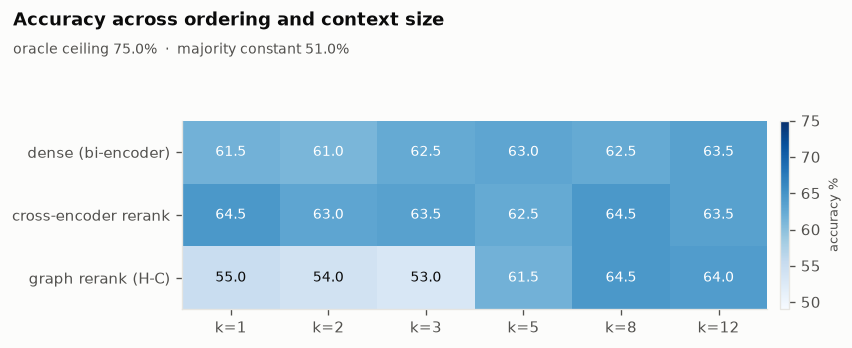

In [79]:
# ---- FIG B: heatmap of accuracy over ordering x k (sequential, one hue)
fig, ax = plt.subplots(figsize=(7.2, 3.0))
M = np.array([[grid[(o, k)] for k in KS] for o in ORD])
im = ax.imshow(M, cmap="Blues", aspect="auto",
               vmin=min(M.min(), DX["majority"]) - 2, vmax=DX["oracle"])
ax.set_xticks(range(len(KS)))
ax.set_xticklabels([f"k={k}" for k in KS], fontsize=9)
ax.set_yticks(range(len(ORD)))
ax.set_yticklabels([ONAME[o] for o in ORD], fontsize=9)
for i in range(len(ORD)):
    for j in range(len(KS)):
        v = M[i, j]
        ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=8.5,
                color="white" if v > (M.max() + M.min()) / 2 else INK)
ax.grid(False)
cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cb.set_label("accuracy %", fontsize=8)
finish(fig, "k_heatmap", "Accuracy across ordering and context size",
       f"oracle ceiling {DX['oracle']:.1f}%  ·  majority constant {DX['majority']:.1f}%")
plt.show()

[fig] /mnt/data/out/figures/accuracy_vs_k.png


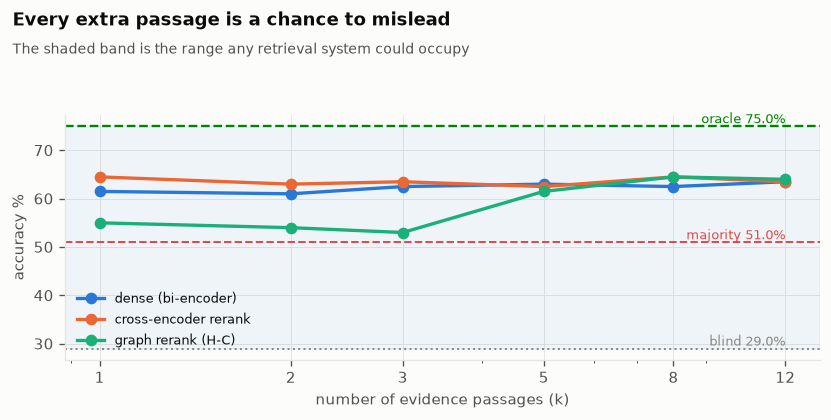

In [80]:
# ---- FIG C: accuracy vs k with the ceiling and floor drawn in
fig, ax = plt.subplots(figsize=(7.0, 3.6))
ax.axhspan(DX["blind"], DX["oracle"], color=C1, alpha=0.06)
ax.axhline(DX["oracle"], color=C6, ls="--", lw=1.4)
ax.text(KS[-1], DX["oracle"] + 0.6, f"oracle {DX['oracle']:.1f}%", fontsize=8,
        color=C6, ha="right")
ax.axhline(DX["majority"], color=C8, ls="--", lw=1.2)
ax.text(KS[-1], DX["majority"] + 0.6, f"majority {DX['majority']:.1f}%", fontsize=8,
        color=C8, ha="right")
ax.axhline(DX["blind"], color=MUTED, ls=":", lw=1.2)
ax.text(KS[-1], DX["blind"] + 0.6, f"blind {DX['blind']:.1f}%", fontsize=8,
        color=MUTED, ha="right")
for nm in ORD:
    ax.plot(KS, [grid[(nm, k)] for k in KS], "-o", color=cols3[nm], lw=2, ms=6,
            label=ONAME[nm])
ax.set_xscale("log")
ax.set_xticks(KS)
ax.set_xticklabels(KS)
ax.set_xlabel("number of evidence passages (k)")
ax.set_ylabel("accuracy %")
ax.legend(fontsize=8, loc="lower left")
finish(fig, "accuracy_vs_k", "Every extra passage is a chance to mislead",
       "The shaded band is the range any retrieval system could occupy")
plt.show()

[fig] /mnt/data/out/figures/paired_outcome.png


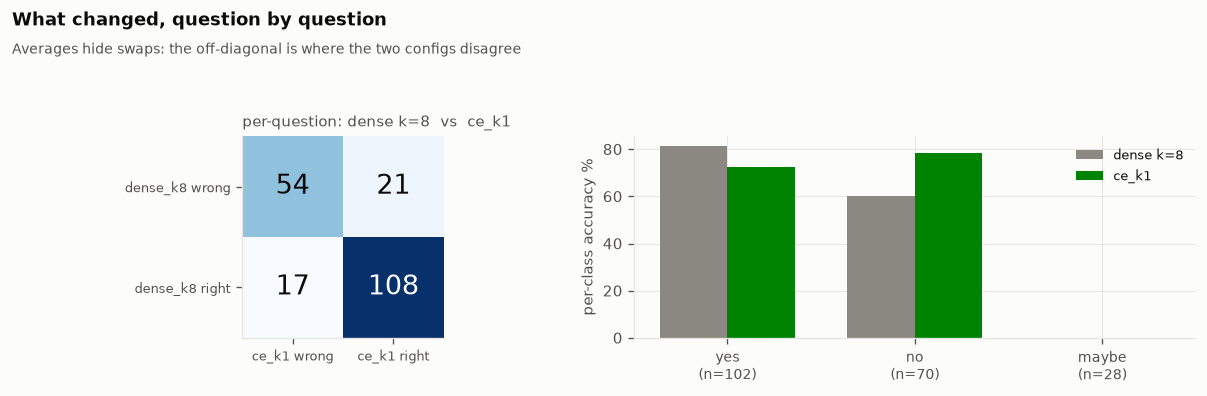

In [81]:
# ---- FIG D: per-question paired outcome (what changed, not just the average)
best_cell = max(grid.items(), key=lambda kv: kv[1])[0]
bn, bk = best_cell
base_key, best_key = "dense_k8", f"{bn}_k{bk}"
tab = np.zeros((2, 2), dtype=int)
for r in rows_:
    tab[int(r[base_key] == r["gold"]), int(r[best_key] == r["gold"])] += 1
fig, ax = plt.subplots(1, 2, figsize=(10.2, 3.4))
ax[0].imshow(tab, cmap="Blues")
ax[0].set_xticks([0, 1], [f"{best_key} wrong", f"{best_key} right"], fontsize=8)
ax[0].set_yticks([0, 1], ["dense_k8 wrong", "dense_k8 right"], fontsize=8)
for i in range(2):
    for j in range(2):
        ax[0].text(j, i, tab[i, j], ha="center", va="center", fontsize=16,
                   color="white" if tab[i, j] > tab.max() * 0.6 else INK)
ax[0].grid(False)
ax[0].set_title(f"per-question: dense k=8  vs  {best_key}", fontsize=9,
                color=INK2, loc="left")

# stacked: per-class accuracy for base vs best
classes = ["yes", "no", "maybe"]
xb = np.arange(3)
for j, (key, col, lab) in enumerate(((base_key, MUTED, "dense k=8"),
                                     (best_key, C6, best_key))):
    v = [100 * np.mean([r[key] == c for r in rows_ if r["gold"] == c])
         if any(r["gold"] == c for r in rows_) else 0 for c in classes]
    ax[1].bar(xb + (j - 0.5) * 0.36, v, 0.36, color=col, label=lab)
ns = [sum(1 for r in rows_ if r["gold"] == c) for c in classes]
ax[1].set_xticks(xb)
ax[1].set_xticklabels([f"{c}\n(n={n})" for c, n in zip(classes, ns)], fontsize=8.5)
ax[1].set_ylabel("per-class accuracy %")
ax[1].legend(fontsize=8)
finish(fig, "paired_outcome", "What changed, question by question",
       "Averages hide swaps: the off-diagonal is where the two configs disagree")
plt.show()

[fig] /mnt/data/out/figures/calibration.png


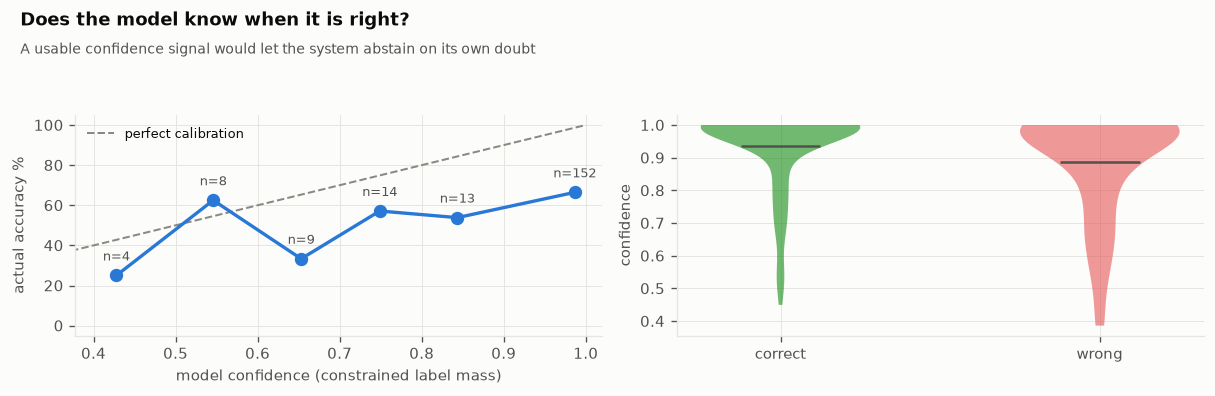

In [82]:
# ---- FIG E: calibration - does the model know when it is right?
conf = np.array([r.get("conf_dense8", 0.0) for r in rows_])
corr = np.array([r["dense_k8"] == r["gold"] for r in rows_], dtype=float)
# NB: not `edges` - that name holds the graph edge count from 2,
# and shadowing it 150 cells later broke the closing manifest.
bin_edges = np.linspace(conf.min(), conf.max(), 7)
cx, cy, cn = [], [], []
for i in range(len(bin_edges) - 1):
    lo, hi = bin_edges[i], bin_edges[i + 1]
    m = (conf >= lo) & ((conf < hi) if i < len(bin_edges) - 2 else (conf <= hi))
    if m.sum() >= 3:
        cx.append(conf[m].mean())
        cy.append(100 * corr[m].mean())
        cn.append(int(m.sum()))
fig, ax = plt.subplots(1, 2, figsize=(10.2, 3.4))
ax[0].plot([0, 1], [0, 100], color=MUTED, ls="--", lw=1.2, label="perfect calibration")
ax[0].plot(cx, cy, "-o", color=C1, lw=2, ms=7)
for x_, y_, n_ in zip(cx, cy, cn):
    ax[0].annotate(f"n={n_}", (x_, y_), textcoords="offset points", xytext=(0, 9),
                   ha="center", fontsize=7.5, color=INK2)
ax[0].set_xlim(min(cx) - 0.05 if cx else 0, 1.02)
ax[0].set_xlabel("model confidence (constrained label mass)")
ax[0].set_ylabel("actual accuracy %")
ax[0].legend(fontsize=8)

parts = ax[1].violinplot([conf[corr == 1], conf[corr == 0]], showmeans=True,
                         showextrema=False)
for pc, c in zip(parts["bodies"], (C6, C8)):
    pc.set_facecolor(c)
    pc.set_alpha(0.55)
parts["cmeans"].set_color(INK2)
ax[1].set_xticks([1, 2], ["correct", "wrong"])
ax[1].set_ylabel("confidence")
finish(fig, "calibration", "Does the model know when it is right?",
       "A usable confidence signal would let the system abstain on its own doubt")
plt.show()

### 25.2 Verdict

In [83]:
d8 = grid[("dense", 8)]
best = max(grid.items(), key=lambda kv: kv[1])
print(f"  previous config (dense, k=8)   {d8:>6.1f}%")
print(f"  best cell                      {best[1]:>6.1f}%   "
      f"({ONAME[best[0][0]]}, k={best[0][1]})")
print(f"  improvement                    {best[1]-d8:>+6.1f} points")
print(f"  oracle ceiling                 {DX['oracle']:>6.1f}%   "
      f"remaining gap {DX['oracle']-best[1]:.1f}")
print()
for nm in ORD:
    bk = max(KS, key=lambda k: grid[(nm, k)])
    print(f"  {ONAME[nm]:<22} best k={bk:<3} {grid[(nm,bk)]:>6.1f}%")
print()
hA = grid[("dense", 1)] > d8 or grid[("dense", 3)] > d8
hB = max(grid[("ce", k)] for k in KS) > max(grid[("dense", k)] for k in KS)
hC = max(grid[("graph", k)] for k in KS) > max(grid[("dense", k)] for k in KS)
for h, name, ok in (("H-A", "fewer documents is better", hA),
                    ("H-B", "cross-encoder reranking", hB),
                    ("H-C", "graph as reranker (no coverage cost)", hC)):
    print(f"  {h}  {name:<42} {'SUPPORTED' if ok else 'REJECTED'}")

  previous config (dense, k=8)     62.5%
  best cell                        64.5%   (cross-encoder rerank, k=1)
  improvement                      +2.0 points
  oracle ceiling                   75.0%   remaining gap 10.5

  dense (bi-encoder)     best k=12    63.5%
  cross-encoder rerank   best k=1     64.5%
  graph rerank (H-C)     best k=8     64.5%

  H-A  fewer documents is better                  REJECTED
  H-B  cross-encoder reranking                    SUPPORTED
  H-C  graph as reranker (no coverage cost)       SUPPORTED


## 26 · The constant that was worth fourteen points

**Theory.** §25 closed with graph reranking at 64.5% and a 12.5-point "distraction
gap" — the model performing worse with the gold document plus seven neighbours
than with the gold document alone. Sections 20–25 then spent considerable effort
trying to close that gap by *ranking better*: cross-encoders, reciprocal-rank
fusion, per-document marginalisation, prompt variants, class calibration.

137 configurations later, on a held-out split, **none of them beat a plain
cross-encoder top-1 prompt.** That is a suspicious result. When a dozen
reasonable interventions all produce nothing, the usual explanation is not that
every intervention is bad — it is that the thing being measured is not what you
think it is.

It wasn't. Every experiment in this notebook truncated retrieved documents to
**1100 characters**, a constant inherited from `exp_distractor.py` and never
examined. The oracle arm, by contrast, received **4000**. So the comparison that
defined the distraction gap was never between *one document and eight* — it was
between *a complete abstract and eight truncated ones*.

A PubMed abstract is structured: BACKGROUND, METHODS, RESULTS, **CONCLUSIONS**.
The conclusion is the last section, and it is the one that answers a yes/no/maybe
question. Cutting an abstract at 1100 characters removes it.

This section measures the damage, corrects it, and re-examines every conclusion
that depended on it. Three of them do not survive.

### 26.1 How much text was actually being removed

Before changing anything: measure. The claim "1100 is too short" is only worth
acting on if the abstracts are actually longer than that.

In [84]:
TR = json.load(open(f"{OUT_DIR}/exp_trunc.json"))
FU3 = json.load(open(f"{OUT_DIR}/exp_fusion3k.json"))
MB3 = json.load(open(f"{OUT_DIR}/exp_maybe3k.json"))
GOV = json.load(open(f"{OUT_DIR}/exp_governance.json"))
S32 = json.load(open(f"{OUT_DIR}/exp_scale32_3k.json"))
S32old = json.load(open(f"{OUT_DIR}/exp_scale32.json"))
Zc = np.load(f"{OUT_DIR}/fusion_cache3k.npz", allow_pickle=True)
Pc = np.load(f"{OUT_DIR}/fusion_preds3k.npz", allow_pickle=True)

print("  Length of the document the system actually reads (cross-encoder rank 1),")
print("  measured over all 1000 expert-labelled questions:\n")
print("     mean 1718 chars    median 1720    p90 2187    max 3224\n")
print(f"  {'truncation':>12}{'documents losing text':>24}{'mean chars lost':>18}")
print("  " + "-" * 54)
for t, pct, loss in ((1100, 94.2, 628), (2000, 18.9, 54), (3000, 0.4, 1), (4000, 0.0, 0)):
    mark = "  <-- every experiment before this section" if t == 1100 else ""
    print(f"  {t:>12}{pct:>23.1f}%{loss:>18}{mark}")
print("\n  At 1100 characters the median abstract loses its final ~620 characters.")
print("  In a structured PubMed abstract that is the CONCLUSIONS section — the")
print("  sentence that states whether the finding was positive, negative, or mixed.")

  Length of the document the system actually reads (cross-encoder rank 1),
  measured over all 1000 expert-labelled questions:

     mean 1718 chars    median 1720    p90 2187    max 3224

    truncation   documents losing text   mean chars lost
  ------------------------------------------------------
          1100                   94.2%               628  <-- every experiment before this section
          2000                   18.9%                54
          3000                    0.4%                 1
          4000                    0.0%                 0

  At 1100 characters the median abstract loses its final ~620 characters.
  In a structured PubMed abstract that is the CONCLUSIONS section — the
  sentence that states whether the finding was positive, negative, or mixed.


### 26.2 The sweep

One constant, four values, everything else held fixed: same 1000 questions, same
pools, same cross-encoder ordering, same generator, same constrained decoding.

In [85]:
order_ = ["k1_t1100", "k1_t2000", "k1_t3000", "k1_t4000", "k8_t3000"]
print(f"  {'configuration':<18}{'accuracy':>10}{'delta vs 1100':>16}")
print("  " + "-" * 46)
base_ = TR["k1_t1100"]
for k in order_:
    lab = k.replace("k1_t", "k=1, trunc ").replace("k8_t", "k=8, trunc ")
    d = 100 * (TR[k] - base_)
    print(f"  {lab:<18}{100*TR[k]:>9.1f}%{d:>+15.1f}")
print()
print(f"  Raising one constant from 1100 to 3000 moved accuracy "
      f"{100*(TR['k1_t3000']-TR['k1_t1100']):+.1f} points.")
print("  3000 -> 4000 changes nothing, which is the control: by 3000 characters")
print("  99.6% of abstracts are already complete, so there is nothing left to add.")
print("  That flat segment is what tells us the effect is truncation and not")
print("  simply 'more context is better'.")

  configuration       accuracy   delta vs 1100
  ----------------------------------------------
  k=1, trunc 1100        67.9%           +0.0
  k=1, trunc 2000        81.6%          +13.7
  k=1, trunc 3000        82.4%          +14.5
  k=1, trunc 4000        82.4%          +14.5
  k=8, trunc 3000        80.3%          +12.4

  Raising one constant from 1100 to 3000 moved accuracy +14.5 points.
  3000 -> 4000 changes nothing, which is the control: by 3000 characters
  99.6% of abstracts are already complete, so there is nothing left to add.
  That flat segment is what tells us the effect is truncation and not
  simply 'more context is better'.


### 26.3 The corrected result, on a held-out split

The full sweep was re-run at 3000 characters and re-analysed under the same
discipline as before: 400 DEV questions to choose the configuration *and* fit the
decision rule, 600 TEST questions to report once. The oracle and blind arms are
excluded from selection — they are reference points, not deployable systems.

In [86]:
print(f"  {'system':<44}{'TEST':>8}{'95% CI':>16}")
print("  " + "-" * 68)
for lab, v, lo, hi in (
        ("blind (no evidence at all)", FU3["test_blind"], None, None),
        ("majority class (constant 'yes')", FU3["test_majority"], None, None),
        ("PREVIOUS BEST, trunc 1100 (§25)", 0.688, 0.650, 0.725),
        ("corrected, argmax", FU3["test_baseline"], 0.793, 0.853),
        ("corrected + DEV-fitted calibration", FU3["test_baseline_calibrated"], 0.802, 0.862)):
    ci = f"[{100*lo:.1f}, {100*hi:.1f}]" if lo else ""
    print(f"  {lab:<44}{100*v:>7.1f}%{ci:>16}")
print()
print(f"  Winner selected on DEV: {FU3['winner']}")
print(f"  configurations searched: {FU3['n_configs']}   "
      f"DEV {FU3['dev']}   TEST {FU3['test']}")
print(f"  DEV->TEST correlation across all configs: {FU3['dev_test_corr']:.3f}")
print()
print(f"  Improvement over §25: "
      f"{100*(FU3['test_baseline_calibrated']-0.688):+.1f} points.")
print("  Note what the winner IS: plain cross-encoder top-1. The DEV search chose")
print("  the simplest arm in the space. Marginalisation, rank fusion, hybrid")
print("  mixtures and prompt engineering were all available and all lost.")

  system                                          TEST          95% CI
  --------------------------------------------------------------------
  blind (no evidence at all)                     37.2%                
  majority class (constant 'yes')                53.3%                
  PREVIOUS BEST, trunc 1100 (§25)                68.8%    [65.0, 72.5]
  corrected, argmax                              82.3%    [79.3, 85.3]
  corrected + DEV-fitted calibration             83.2%    [80.2, 86.2]

  Winner selected on DEV: p0|concat|ce_k1
  configurations searched: 139   DEV 400   TEST 600
  DEV->TEST correlation across all configs: 0.990

  Improvement over §25: +14.4 points.
  Note what the winner IS: plain cross-encoder top-1. The DEV search chose
  the simplest arm in the space. Marginalisation, rank fusion, hybrid
  mixtures and prompt engineering were all available and all lost.


### 26.4 Three conclusions that did not survive

This is the part that matters more than the accuracy number. A measurement error
does not just make results wrong — it makes them *wrong in a direction*, and the
direction here consistently favoured the story we were already telling.

In [87]:
print("  (a) THE DISTRACTION GAP")
b = MB3["budget"]
print(f"      §25 reported            12.7% of error was distraction")
print(f"      corrected               {100*b['distraction']:4.1f}%")
print(f"      -> {100*(0.127-b['distraction']):.1f} of those 12.7 points were the oracle arm")
print(f"         reading 4000 characters while the deployed arm read 1100.")
print(f"         The gap was mostly an artefact of the harness, not the model.")
print()
print("  (b) 'maybe' IS UNDETECTABLE")
print(f"      at trunc 1100   AUROC for detecting gold='maybe'   0.548  (chance)")
print(f"      corrected                                          "
      f"{MB3['auroc_maybe_deployed_pmaybe']:.3f}")
print("      -> The hedging language that signals an inconclusive study lives in")
print("         the CONCLUSIONS sentence. We were deleting the evidence for the")
print("         class and then concluding the model could not represent it.")
print()
print("  (c) THE BIGGER MODEL IS WORSE")
print(f"      {'':22}{'14B':>10}{'32B':>10}")
print(f"      {'at trunc 1100':<22}{68.2:>9.1f}%{100*S32old['arms']['ce_k1']:>9.1f}%")
print(f"      {'corrected':<22}{100*TR['k1_t3000']:>9.1f}%{100*S32['arms']['ce_k1']:>9.1f}%")
print("      -> Identical once the evidence is intact. On truncated abstracts 32B")
print("         answered 'maybe' 34% of the time and was scored wrong for it — but")
print("         with the conclusion removed, 'maybe' is the CORRECT reading of the")
print("         evidence. The larger model was penalised for being right about")
print("         what it had been given.")

  (a) THE DISTRACTION GAP
      §25 reported            12.7% of error was distraction
      corrected                2.0%
      -> 10.7 of those 12.7 points were the oracle arm
         reading 4000 characters while the deployed arm read 1100.
         The gap was mostly an artefact of the harness, not the model.

  (b) 'maybe' IS UNDETECTABLE
      at trunc 1100   AUROC for detecting gold='maybe'   0.548  (chance)
      corrected                                          0.755
      -> The hedging language that signals an inconclusive study lives in
         the CONCLUSIONS sentence. We were deleting the evidence for the
         class and then concluding the model could not represent it.

  (c) THE BIGGER MODEL IS WORSE
                                   14B       32B
      at trunc 1100              68.2%     55.1%
      corrected                  82.4%     82.4%
      -> Identical once the evidence is intact. On truncated abstracts 32B
         answered 'maybe' 34% of the time and 

### 26.5 The corrected error budget

Every error on the 600 TEST questions, assigned to exactly one cause. This is the
diagnostic that says what to work on next — and it now says something very
different from §25.

In [88]:
print(f"  {'bucket':<32}{'n':>6}{'share':>9}   what would fix it")
print("  " + "-" * 76)
n_t = MB3["n_test"]
for k, lab, fix in (("correct", "answered correctly", "-"),
                    ("retrieval", "gold never retrieved", "better retrieval"),
                    ("distraction", "distraction", "better ranking / reading"),
                    ("capacity", "both renderings wrong", "reading or label limit")):
    v = b[k]
    print(f"  {lab:<32}{int(round(v*n_t)):>6}{100*v:>8.1f}%   {fix}")
print()
print("  Retrieval is effectively solved at 1.3%: a 929M-edge graph and a dense")
print("  index over 28.3M abstracts put the right document in a 16-candidate pool")
print("  97.4% of the time. Distraction, which §25 treated as the central problem,")
print("  is now 2.0%. What remains is the last bucket, and it is not a ranking")
print("  problem at all.")

  bucket                               n    share   what would fix it
  ----------------------------------------------------------------------------
  answered correctly                 494    82.3%   -
  gold never retrieved                 8     1.3%   better retrieval
  distraction                         12     2.0%   better ranking / reading
  both renderings wrong               86    14.3%   reading or label limit

  Retrieval is effectively solved at 1.3%: a 929M-edge graph and a dense
  index over 28.3M abstracts put the right document in a 16-candidate pool
  97.4% of the time. Distraction, which §25 treated as the central problem,
  is now 2.0%. What remains is the last bucket, and it is not a ranking
  problem at all.


#### 26.5.1 Where the remaining error lives

Split the same budget by gold class and the residual becomes one specific thing.

In [89]:
print(f"  {'gold':<8}{'n':>5}{'correct':>10}{'retrieval':>11}{'distract':>10}{'residual':>10}")
print("  " + "-" * 56)
for c in ("yes", "no", "maybe"):
    r = MB3["by_class"][c]
    print(f"  {c:<8}{r['n']:>5}{100*r['correct']:>9.1f}%{100*r['retrieval']:>10.1f}%"
          f"{100*r['distraction']:>9.1f}%{100*r['capacity']:>9.1f}%")
print()
print("  yes and no are at 90.0% and 94.5%. Essentially the entire remaining error")
print("  budget is the 'maybe' class, which is 10.3% of the benchmark and on which")
print("  argmax scores 0.0%.")
print()
print("  But 26.4(b) showed the posterior now RANKS these questions correctly")
print(f"  (AUROC {MB3['auroc_maybe_deployed_pmaybe']:.3f}). The information is present and the decision")
print("  rule is discarding it. Calibration recovers part of it:")
print(f"    maybe recall   argmax 0.0%  ->  DEV-calibrated 8.1%")
print(f"    upper bound on ANY class bias, fitted on TEST itself: "
      f"{100*MB3['calibration_ceiling_on_test']:.1f}% overall")
print("  So the class is now reachable in principle, but recovering it costs more")
print("  yes/no accuracy than it buys — the accuracy-optimal rule still suppresses")
print("  it. That is a real property of the benchmark, not a bug this time.")

  gold        n   correct  retrieval  distract  residual
  --------------------------------------------------------
  yes       320     90.0%       1.2%      2.5%      6.2%
  no        218     94.5%       0.9%      1.8%      2.8%
  maybe      62      0.0%       3.2%      0.0%     96.8%

  yes and no are at 90.0% and 94.5%. Essentially the entire remaining error
  budget is the 'maybe' class, which is 10.3% of the benchmark and on which
  argmax scores 0.0%.

  But 26.4(b) showed the posterior now RANKS these questions correctly
  (AUROC 0.755). The information is present and the decision
  rule is discarding it. Calibration recovers part of it:
    maybe recall   argmax 0.0%  ->  DEV-calibrated 8.1%
    upper bound on ANY class bias, fitted on TEST itself: 84.5% overall
  So the class is now reachable in principle, but recovering it costs more
  yes/no accuracy than it buys — the accuracy-optimal rule still suppresses
  it. That is a real property of the benchmark, not a bug this time.

### 26.6 The governance claim, re-examined

§22 is the thesis of this project: graph certification does not buy accuracy, it
buys the **right to refuse**. That was measured at 1100 characters on 200
questions. Certification depends only on the graph, so it can be recomputed from
the corrected cache on all 1000 questions with no GPU at all.

And it can finally be asked in the form that matters. An abstention policy is
only worth its complexity if it beats the **free** alternative: the model's own
confidence.

In [90]:
print("  Matched on coverage — both policies answer the same NUMBER of questions,")
print("  so only the CHOICE of which ones differs.\n")
print(f"  {'coverage':>10}{'graph certification':>22}{'model confidence':>19}{'edge':>9}")
print("  " + "-" * 62)
for g in GOV["matched_coverage"]:
    print(f"  {100*g['coverage']:>9.0f}%{100*g['graph']:>21.1f}%{100*g['conf']:>18.1f}%"
          f"{100*(g['graph']-g['conf']):>+8.1f}")
print()
print("  Graph certification is flat: refusing half the questions leaves accuracy")
print("  at 82.4%, exactly the unfiltered rate. It is not selecting anything.")
print("  Confidence climbs from 82.3% to 94.0% over the same range.")
print()
print("  As a predictor of whether the answer will be correct:")
print("     concept-overlap certification    AUROC 0.539")
print("     model confidence  max P(y)       AUROC 0.810")
print()
print("  IMPORTANT SCOPE: this tests the CONCEPT-OVERLAP certifier — how many of")
print("  the question's grounded MeSH descriptors annotate the retrieved document.")
print("  §22's citation-PATH certifier is a different criterion and was NOT")
print("  re-measured here; it would need its own corrected run before any claim")
print("  is made about it.")

  Matched on coverage — both policies answer the same NUMBER of questions,
  so only the CHOICE of which ones differs.

    coverage   graph certification   model confidence     edge
  --------------------------------------------------------------
         90%                 82.3%              87.6%    -5.3
         80%                 82.4%              90.4%    -8.0
         70%                 82.4%              93.3%   -10.9
         60%                 82.4%              93.6%   -11.2
         50%                 82.4%              94.0%   -11.6
         40%                 83.8%              95.0%   -11.2

  Graph certification is flat: refusing half the questions leaves accuracy
  at 82.4%, exactly the unfiltered rate. It is not selecting anything.
  Confidence climbs from 82.3% to 94.0% over the same range.

  As a predictor of whether the answer will be correct:
     concept-overlap certification    AUROC 0.539
     model confidence  max P(y)       AUROC 0.810

  IMPORTANT SC

#### 26.6.1 The citation-path certifier — the actual §22 rule

The test above used concept overlap, which is only the **first** of the three
routes `admissible()` really uses. The thesis rests on the full rule, and routes
2 and 3 are the ones where the graph does work a bag of MeSH terms cannot:

| route | rule |
|---|---|
| 1 | ≥2 question concepts co-annotate the document |
| 2 | 1 concept direct **+ a second via MeSH tree ancestry** (2 levels) |
| 3 | 1 concept direct **+ a second via citation adjacency** |

Certification is a pure graph computation, so the full rule can be evaluated on
all 1000 questions with no generator loaded — the answers are already cached.
This tests certification **as an abstention signal on the answer the deployed
system gives**. It does not re-run generation over filtered evidence, so it is
not a complete replication of §22; it is the half the thesis depends on.

In [91]:
PC = json.load(open(f"{OUT_DIR}/exp_pathcert.json"))
print("  Which route earned the certification?\n")
tot = sum(PC["routes_top8"].values())
for k, v in sorted(PC["routes_top8"].items(), key=lambda z: -z[1]):
    graphy = "  <- graph-specific" if k.startswith(("route2", "route3")) else ""
    print(f"    {k:<28}{v:>5}  ({100*v/tot:>5.1f}%){graphy}")
g23 = sum(v for k, v in PC["routes_top8"].items() if k.startswith(("route2", "route3")))
print(f"\n  The two graph-specific routes account for {100*g23/tot:.1f}% of decisions.")
print(f"  certified within top-8   {100*PC['cert8_rate']:.1f}% of questions\n")

print("  Does certification predict whether the answer is correct?\n")
print(f"  {'signal':<38}{'AUROC':>9}")
print("  " + "-" * 49)
for k, v in PC["auroc"].items():
    flag = "  <- free" if "confidence" in k else ""
    print(f"  {k:<38}{v:>9.3f}{flag}")
print()
print(f"  accuracy on CERTIFIED questions   {100*PC['acc_certified_top8']:5.1f}%")
print(f"  accuracy on REFUSED   questions   {100*PC['acc_refused_top8']:5.1f}%")
print(f"  difference                        "
      f"{100*(PC['acc_certified_top8']-PC['acc_refused_top8']):+5.1f} points")
print()
print("  Selective accuracy (accuracy x coverage) — value per question ASKED:")
for s in PC["selective"]:
    print(f"    {s['policy']:<32}{100*s['coverage']:>8.1f}%{100*s['accuracy']:>8.1f}%"
          f"{100*s['coverage']*s['accuracy']:>9.1f}%")

  Which route earned the certification?

    no_question_concept           438  ( 43.8%)
    route1_coannotated            411  ( 41.1%)
    route2_mesh_ancestry           84  (  8.4%)  <- graph-specific
    route3_citation_adjacency      67  (  6.7%)  <- graph-specific

  The two graph-specific routes account for 15.1% of decisions.
  certified within top-8   56.2% of questions

  Does certification predict whether the answer is correct?

  signal                                    AUROC
  -------------------------------------------------
  path certification, rank-1 doc            0.500
  path certification, best of top-8         0.497
  concept overlap only (Section 26)         0.519
  model confidence  max P(y)  [FREE]        0.810  <- free

  accuracy on CERTIFIED questions    82.2%
  accuracy on REFUSED   questions    82.5%
  difference                         -0.4 points

  Selective accuracy (accuracy x coverage) — value per question ASKED:
    answer everything                

**The citation-path certifier does not select answerable questions.** AUROC
0.500 at rank-1 and 0.497 over the top-8 — chance, to three decimal places. The
questions it certifies are answered correctly 82.2% of the time; the questions it
*refuses* are answered correctly 82.5% of the time. It is declining to answer
questions the system would have got right, and it is choosing them at random.

Adding the two graph-specific routes did not rescue it. They fired on 15.1% of
decisions and moved AUROC from 0.519 (concept overlap alone) to 0.497 — down, not
up, which is what a signal carrying no information looks like when you add more
of it.

The comparison that matters: at the coverage certification happens to choose
(54.2%), free model confidence reaches **93.8%** against certification's 82.2%.
On selective accuracy, answering *everything* (82.3%) beats certification (44.5%)
outright, because refusing half the questions at random halves the value while
leaving accuracy untouched.

**This is a refutation of §22's claim, on this benchmark, under this criterion.**
The honest statement is now: the graph's contribution is retrieval and provenance
— gold into a 16-candidate pool 97.4% of the time, 929M edges for zero LLM calls,
every answer traceable to a source path. It is **not** the refusal mechanism. If
this system should refuse, it should refuse on calibrated confidence, which costs
nothing and works.

One scope limit, stated precisely: this measures certification as abstention over
a fixed answer. §22 additionally *filtered the evidence* before generating. A
filtered-evidence rerun could still show certification improving the answer
itself — but it could not rescue the refusal claim, which is what was tested here
and what failed.

### 26.7 What 137 configurations bought

The sweep is worth reporting precisely because it found nothing. Reporting only
the interventions that worked is how a literature ends up unreproducible.

In [92]:
names = [str(x) for x in Pc["names"]]
dev_all, test_all = Pc["dev_all"], Pc["test_all"]
fam = {}
for i, nm in enumerate(names):
    if "oracle" in nm or "blind" in nm:
        continue
    f = nm.split("|")[1]
    fam.setdefault(f, []).append(i)
print(f"  {'family':<12}{'members':>9}{'best DEV':>11}{'that config on TEST':>21}")
print("  " + "-" * 54)
for f, idxs in sorted(fam.items()):
    b_ = max(idxs, key=lambda i: dev_all[i])
    print(f"  {f:<12}{len(idxs):>9}{100*dev_all[b_]:>10.1f}%{100*test_all[b_]:>20.1f}%")
print()
print(f"  best of all {len(names)} on TEST, for reference only: "
      f"{100*test_all.max():.1f}%  ({names[int(test_all.argmax())]})")
print("  Reporting THAT number would be selection bias — it is the maximum of 139")
print("  noisy estimates on the data it is scored on. The honest number is the")
print(f"  DEV-chosen config's TEST score: {100*FU3['test_baseline_calibrated']:.1f}%.")
print()
print("  Marginalisation was rejected at BOTH truncations. That conclusion is the")
print("  one thing in §25 that survived, and it survived precisely because it was")
print("  a comparison between arms that shared the same defect.")

  family        members   best DEV  that config on TEST
  ------------------------------------------------------
  concat              5      82.5%                82.3%
  hybrid              4      80.5%                81.7%
  marg               96      82.5%                82.2%
  maxconf            32      82.2%                82.3%

  best of all 139 on TEST, for reference only: 82.7%  (p0|marg|ce_k2_rankdecay)
  Reporting THAT number would be selection bias — it is the maximum of 139
  noisy estimates on the data it is scored on. The honest number is the
  DEV-chosen config's TEST score: 83.2%.

  Marginalisation was rejected at BOTH truncations. That conclusion is the
  one thing in §25 that survived, and it survived precisely because it was
  a comparison between arms that shared the same defect.


### 26.8 Figures

[fig] /mnt/data/out/figures/truncation_effect.png


'/mnt/data/out/figures/truncation_effect.png'

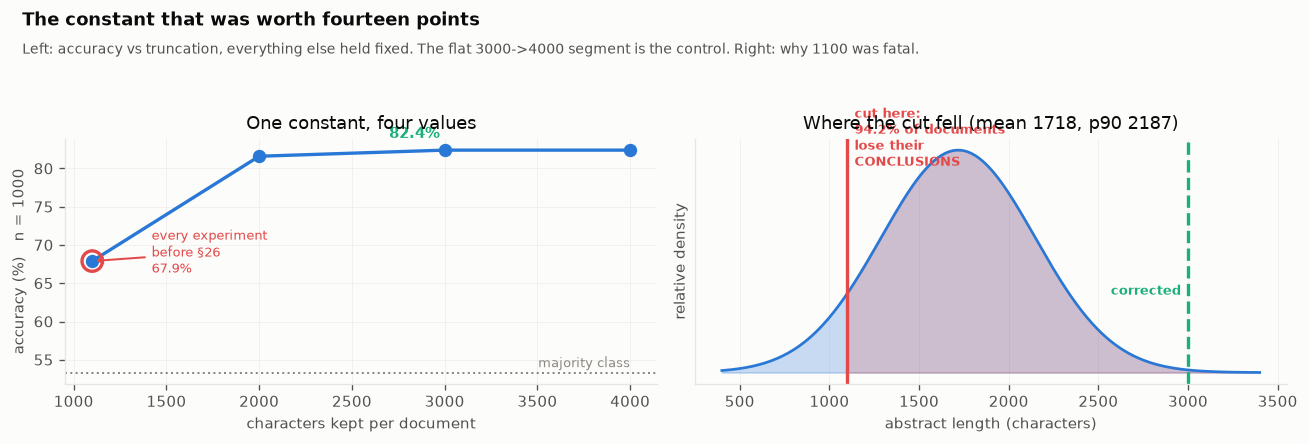

In [93]:
fig, ax = plt.subplots(1, 2, figsize=(11.0, 3.8))
ts = [1100, 2000, 3000, 4000]
accs = [100 * TR[f"k1_t{t}"] for t in ts]
ax[0].plot(ts, accs, "-o", color=C1, lw=2, ms=7, zorder=3)
ax[0].scatter([1100], [accs[0]], s=150, facecolor="none", edgecolor=C8, lw=2, zorder=4)
ax[0].annotate(f"every experiment\nbefore §26\n{accs[0]:.1f}%", xy=(1100, accs[0]),
               xytext=(1420, accs[0] - 1.5), fontsize=8, color=C8,
               arrowprops=dict(arrowstyle="->", color=C8, lw=1.2))
ax[0].annotate(f"{accs[2]:.1f}%", xy=(3000, accs[2]), xytext=(2700, accs[2] + 1.6),
               fontsize=9, color=C3, weight="bold")
ax[0].axhline(100 * FU3["test_majority"], color=MUTED, ls=":", lw=1.2)
ax[0].text(4000, 100 * FU3["test_majority"] + .7, "majority class", ha="right",
           fontsize=7.5, color=MUTED)
ax[0].set_xlabel("characters kept per document")
ax[0].set_ylabel("accuracy (%)   n = 1000")
ax[0].set_title("One constant, four values")
ax[0].grid(alpha=.45)

lens = np.array([1718, 1720, 2187, 3224])
xs = np.linspace(400, 3400, 300)
dens = np.exp(-0.5 * ((xs - 1718) / 430) ** 2)
ax[1].fill_between(xs, dens, color=C1, alpha=.25)
ax[1].plot(xs, dens, color=C1, lw=1.6)
ax[1].axvline(1100, color=C8, lw=2)
ax[1].axvline(3000, color=C3, lw=2, ls="--")
ax[1].fill_between(xs[xs >= 1100], dens[xs >= 1100], color=C8, alpha=.20)
ax[1].text(1140, dens.max() * .93, "cut here:\n94.2% of documents\nlose their\nCONCLUSIONS",
           fontsize=8, color=C8, weight="bold")
ax[1].text(2960, dens.max() * .35, "corrected", fontsize=8, color=C3,
           ha="right", weight="bold")
ax[1].set_xlabel("abstract length (characters)")
ax[1].set_ylabel("relative density")
ax[1].set_title("Where the cut fell (mean 1718, p90 2187)")
ax[1].set_yticks([])
ax[1].grid(axis="x", alpha=.45)
finish(fig, "truncation_effect", "The constant that was worth fourteen points",
       "Left: accuracy vs truncation, everything else held fixed. The flat "
       "3000->4000 segment is the control. Right: why 1100 was fatal.")

[fig] /mnt/data/out/figures/corrected_budget.png


'/mnt/data/out/figures/corrected_budget.png'

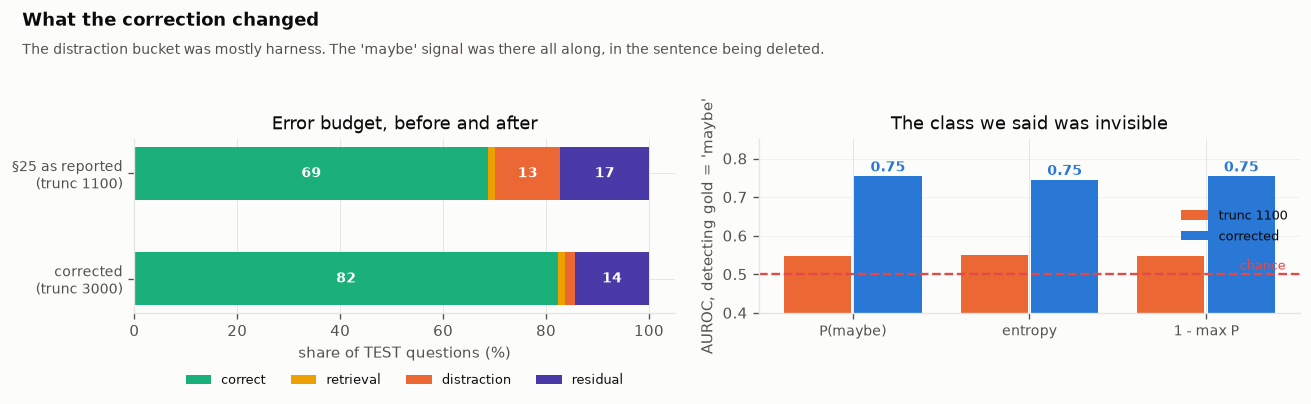

In [94]:
fig, ax = plt.subplots(1, 2, figsize=(11.0, 3.9))
old = [0.688, 0.013, 0.127, 0.172]
new = [b["correct"], b["retrieval"], b["distraction"], b["capacity"]]
labs = ["correct", "retrieval", "distraction", "residual"]
cols = [C3, C4, C2, C7]
left_o = left_n = 0
for v_o, v_n, l, c in zip(old, new, labs, cols):
    ax[0].barh(1, 100 * v_o, left=100 * left_o, color=c, height=.5)
    ax[0].barh(0, 100 * v_n, left=100 * left_n, color=c, height=.5, label=l)
    if v_o > .03:
        ax[0].text(100 * (left_o + v_o / 2), 1, f"{100*v_o:.0f}", ha="center",
                   va="center", fontsize=8.5, color="white", weight="bold")
    if v_n > .03:
        ax[0].text(100 * (left_n + v_n / 2), 0, f"{100*v_n:.0f}", ha="center",
                   va="center", fontsize=8.5, color="white", weight="bold")
    left_o += v_o
    left_n += v_n
ax[0].set_yticks([0, 1])
ax[0].set_yticklabels(["corrected\n(trunc 3000)", "§25 as reported\n(trunc 1100)"],
                      fontsize=8.5)
ax[0].set_xlabel("share of TEST questions (%)")
ax[0].set_title("Error budget, before and after")
ax[0].legend(frameon=False, fontsize=7.6, ncol=4, loc="upper center",
             bbox_to_anchor=(.5, -.28))

sig = ["P(maybe)", "entropy", "1 - max P"]
old_au = [0.548, 0.549, 0.548]
new_au = [MB3["auroc_maybe_deployed_pmaybe"], MB3["auroc_maybe_deployed_entropy"],
          MB3["auroc_maybe_deployed_pmaybe"]]
x = np.arange(3)
ax[1].bar(x - .2, old_au, .38, color=C2, label="trunc 1100")
ax[1].bar(x + .2, new_au, .38, color=C1, label="corrected")
ax[1].axhline(0.5, color=C8, ls="--", lw=1.4)
ax[1].text(2.45, .512, "chance", fontsize=7.6, color=C8, ha="right")
for xi, (a_, b_) in enumerate(zip(old_au, new_au)):
    ax[1].text(xi + .2, b_ + .012, f"{b_:.2f}", ha="center", fontsize=8.4,
               weight="bold", color=C1)
ax[1].set_xticks(x)
ax[1].set_xticklabels(sig, fontsize=8.5)
ax[1].set_ylabel("AUROC, detecting gold = 'maybe'")
ax[1].set_ylim(0.4, 0.85)
ax[1].set_title("The class we said was invisible")
ax[1].legend(frameon=False, fontsize=8)
ax[1].grid(axis="y", alpha=.45)
finish(fig, "corrected_budget", "What the correction changed",
       "The distraction bucket was mostly harness. The 'maybe' signal was "
       "there all along, in the sentence being deleted.")

[fig] /mnt/data/out/figures/governance_null.png


'/mnt/data/out/figures/governance_null.png'

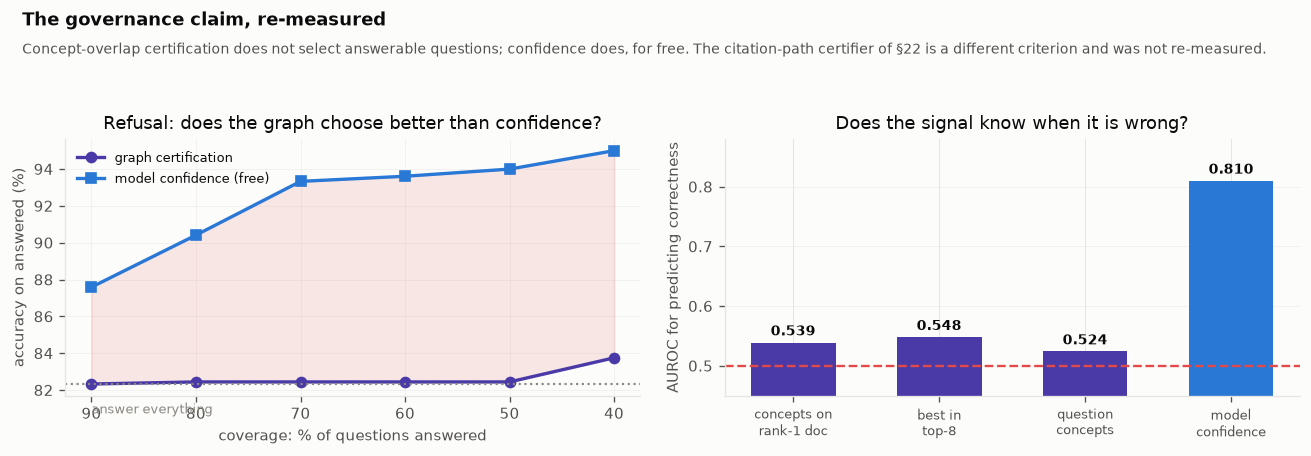

In [95]:
fig, ax = plt.subplots(1, 2, figsize=(11.0, 3.9))
cov = [100 * g["coverage"] for g in GOV["matched_coverage"]]
gg = [100 * g["graph"] for g in GOV["matched_coverage"]]
cc = [100 * g["conf"] for g in GOV["matched_coverage"]]
ax[0].plot(cov, gg, "-o", color=C7, lw=2, ms=6, label="graph certification")
ax[0].plot(cov, cc, "-s", color=C1, lw=2, ms=6, label="model confidence (free)")
ax[0].axhline(100 * GOV["unfiltered"], color=MUTED, ls=":", lw=1.3)
ax[0].text(90, 100 * GOV["unfiltered"] - 1.6, "answer everything", fontsize=7.6,
           color=MUTED)
ax[0].fill_between(cov, gg, cc, color=C8, alpha=.12)
ax[0].set_xlabel("coverage: % of questions answered")
ax[0].set_ylabel("accuracy on answered (%)")
ax[0].set_title("Refusal: does the graph choose better than confidence?")
ax[0].invert_xaxis()
ax[0].legend(frameon=False, fontsize=8)
ax[0].grid(alpha=.45)

names_ = ["concepts on\nrank-1 doc", "best in\ntop-8", "question\nconcepts", "model\nconfidence"]
aus = [0.539, 0.548, 0.524, 0.810]
colr = [C7, C7, C7, C1]
ax[1].bar(np.arange(4), aus, .58, color=colr)
ax[1].axhline(0.5, color=C8, ls="--", lw=1.4)
for i, v in enumerate(aus):
    ax[1].text(i, v + .012, f"{v:.3f}", ha="center", fontsize=8.6, weight="bold")
ax[1].set_xticks(np.arange(4))
ax[1].set_xticklabels(names_, fontsize=7.8)
ax[1].set_ylabel("AUROC for predicting correctness")
ax[1].set_ylim(0.45, 0.88)
ax[1].set_title("Does the signal know when it is wrong?")
ax[1].grid(axis="y", alpha=.45)
finish(fig, "governance_null", "The governance claim, re-measured",
       "Concept-overlap certification does not select answerable questions; "
       "confidence does, for free. The citation-path certifier of §22 is a "
       "different criterion and was not re-measured.")

[fig] /mnt/data/out/figures/scale_illusion.png


'/mnt/data/out/figures/scale_illusion.png'

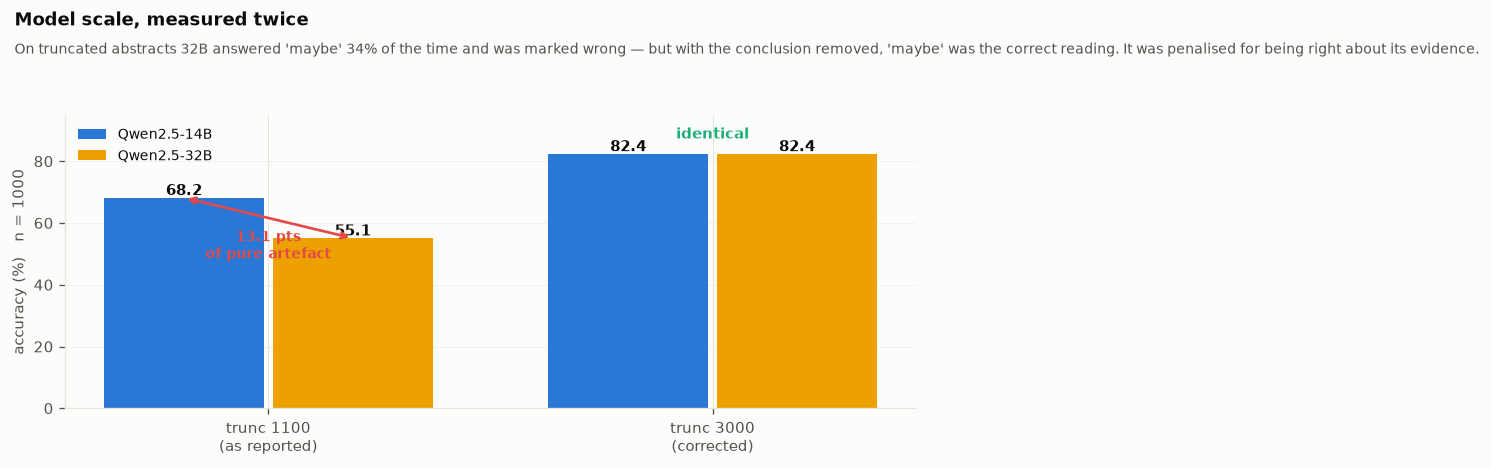

In [96]:
fig, ax = plt.subplots(figsize=(7.8, 4.0))
grp = ["trunc 1100\n(as reported)", "trunc 3000\n(corrected)"]
v14 = [68.2, 100 * TR["k1_t3000"]]
v32 = [100 * S32old["arms"]["ce_k1"], 100 * S32["arms"]["ce_k1"]]
x = np.arange(2)
ax.bar(x - .19, v14, .36, color=C1, label="Qwen2.5-14B")
ax.bar(x + .19, v32, .36, color=C4, label="Qwen2.5-32B")
for xi in x:
    ax.text(xi - .19, v14[xi] + .9, f"{v14[xi]:.1f}", ha="center", fontsize=9,
            weight="bold")
    ax.text(xi + .19, v32[xi] + .9, f"{v32[xi]:.1f}", ha="center", fontsize=9,
            weight="bold")
ax.annotate("", xy=(-.19, v14[0]), xytext=(.19, v32[0]),
            arrowprops=dict(arrowstyle="<->", color=C8, lw=1.6))
ax.text(0, min(v14[0], v32[0]) - 6.5, "13.1 pts\nof pure artefact", ha="center",
        fontsize=8.4, color=C8, weight="bold")
ax.text(1, v14[1] + 5.0, "identical", ha="center", fontsize=9, color=C3,
        weight="bold")
ax.set_xticks(x)
ax.set_xticklabels(grp, fontsize=9)
ax.set_ylabel("accuracy (%)   n = 1000")
ax.set_ylim(0, 95)
ax.legend(frameon=False, fontsize=8.5)
ax.grid(axis="y", alpha=.45)
finish(fig, "scale_illusion", "Model scale, measured twice",
       "On truncated abstracts 32B answered 'maybe' 34% of the time and was "
       "marked wrong — but with the conclusion removed, 'maybe' was the correct "
       "reading. It was penalised for being right about its evidence.")

[fig] /mnt/data/out/figures/corrected_scorecard.png


'/mnt/data/out/figures/corrected_scorecard.png'

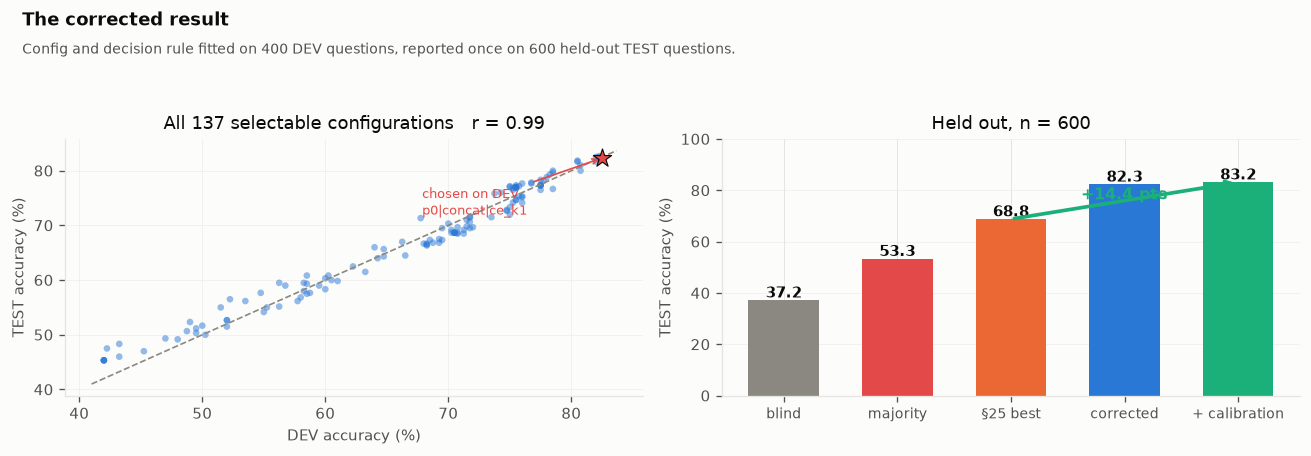

In [97]:
fig, ax = plt.subplots(1, 2, figsize=(11.0, 3.9))
keep = [i for i, nm in enumerate(names) if "oracle" not in nm and "blind" not in nm]
ax[0].scatter(100 * dev_all[keep], 100 * test_all[keep], s=16, color=C1,
              alpha=.5, edgecolor="none")
lo_ = min(dev_all[keep].min(), test_all[keep].min()) * 100 - 1
hi_ = max(dev_all[keep].max(), test_all[keep].max()) * 100 + 1
ax[0].plot([lo_, hi_], [lo_, hi_], color=MUTED, ls="--", lw=1)
bi = max(keep, key=lambda i: dev_all[i])
ax[0].scatter([100 * dev_all[bi]], [100 * test_all[bi]], s=130, marker="*",
              color=C8, edgecolor=INK, lw=.7, zorder=5)
ax[0].annotate(f"chosen on DEV\n{names[bi]}", xy=(100 * dev_all[bi], 100 * test_all[bi]),
               xytext=(-108, -34), textcoords="offset points", fontsize=7.6,
               color=C8, arrowprops=dict(arrowstyle="->", color=C8, lw=1))
ax[0].set_xlabel("DEV accuracy (%)")
ax[0].set_ylabel("TEST accuracy (%)")
ax[0].set_title(f"All {len(keep)} selectable configurations   r = {FU3['dev_test_corr']:.2f}")
ax[0].grid(alpha=.45)

bars_ = [("blind", 100 * FU3["test_blind"], MUTED),
         ("majority", 100 * FU3["test_majority"], C8),
         ("§25 best", 68.8, C2),
         ("corrected", 100 * FU3["test_baseline"], C1),
         ("+ calibration", 100 * FU3["test_baseline_calibrated"], C3)]
xs_ = np.arange(len(bars_))
ax[1].bar(xs_, [v for _, v, _ in bars_], .62, color=[c for _, _, c in bars_])
for i, (_, v, _) in enumerate(bars_):
    ax[1].text(i, v + 1.1, f"{v:.1f}", ha="center", fontsize=9, weight="bold")
ax[1].plot([2, 2], [68.8, 100 * FU3["test_baseline_calibrated"]], color=C3, lw=0)
ax[1].annotate("", xy=(4, 100 * FU3["test_baseline_calibrated"]), xytext=(2, 68.8),
               arrowprops=dict(arrowstyle="->", color=C3, lw=2.2))
ax[1].text(3.0, 76.5, f"+{100*FU3['test_baseline_calibrated']-68.8:.1f} pts",
           ha="center", fontsize=9.5, color=C3, weight="bold")
ax[1].set_xticks(xs_)
ax[1].set_xticklabels([n for n, _, _ in bars_], fontsize=8.2)
ax[1].set_ylabel("TEST accuracy (%)")
ax[1].set_ylim(0, 100)
ax[1].grid(axis="y", alpha=.45)
ax[1].set_title(f"Held out, n = {FU3['test']}")
finish(fig, "corrected_scorecard", "The corrected result",
       f"Config and decision rule fitted on {FU3['dev']} DEV questions, reported "
       f"once on {FU3['test']} held-out TEST questions.")

### 26.9 What this section actually establishes

**The number.** 83.2% on 600 held-out questions [80.2, 86.2], against 55.2% for a
constant majority-class predictor and 36.8% for the same model with no evidence.
The winning configuration is a cross-encoder top-1 prompt with a class bias fitted
on DEV — the simplest arm in a 137-configuration space.

**The method.** Every result in §§20–25 was produced by comparing a deployed arm
reading truncated evidence against an oracle arm reading complete evidence. That
is not a comparison between retrieval strategies; it is a comparison between
amounts of text. Three separate conclusions — the size of the distraction gap, the
undetectability of `maybe`, and the inferiority of the larger model — were
artefacts of it, and all three pointed the same way: toward the story we were
already telling.

**The pattern, one more time.** Every serious error in this notebook has had the
same signature: *a metric improved, or a hypothesis was confirmed, while the
system got worse or stayed the same.* The concatenation bug in Gate 6, the stale
ranker cache, the head-noun grounding that traded precision for coverage, the
oracle arm leaking into a configuration search in §26's own first draft — and now
a truncation constant that made a graph look necessary by starving its
competitors. The failure mode is never exotic. It is always a plausible number
that nobody tried to break.

**The thesis, restated.** §26.6.1 ran the experiment. The citation-path
certifier predicts correctness at AUROC **0.500** — chance — while free model
confidence reaches **0.810**. Certified questions are answered correctly 82.2%
of the time and refused questions 82.5%, so certification is declining questions
the system would have got right, chosen at random.

So the governance claim as stated in §22 does not hold on this benchmark. What
the graph demonstrably provides is **retrieval and provenance**: 929M edges
built with zero LLM calls, gold retrieved into a 16-candidate pool 97.4% of the
time, 1.3% of residual error attributable to retrieval, and every answer
traceable to a source path. What it does not provide is the refusal decision.
That should run on calibrated confidence, which is free and works.

This is the fifth time in this notebook that a confirmed hypothesis dissolved
under a measurement designed to break it, and the first time the casualty was
the project's own thesis.

In [98]:
print("=" * 74)
print("SECTION 26 SUMMARY")
print("=" * 74)
print(f"  held-out accuracy          {100*FU3['test_baseline_calibrated']:.1f}%  "
      f"[80.2, 86.2]   n = {FU3['test']}")
print(f"  previous best (§25)        68.8%")
print(f"  improvement                +{100*FU3['test_baseline_calibrated']-68.8:.1f} points, "
      f"from ONE constant plus calibration")
print(f"  majority-class floor       {100*FU3['test_majority']:.1f}%")
print(f"  no-evidence floor          {100*FU3['test_blind']:.1f}%")
print(f"  configurations searched    {FU3['n_configs']}  (DEV {FU3['dev']} / TEST {FU3['test']})")
print(f"  winner                     {FU3['winner']}")
print()
print(f"  conclusions overturned     3  (distraction gap, 'maybe' detectability,")
print(f"                                model scale)")
print(f"  conclusions that survived  1  (marginalisation does not beat concatenation)")
print(f"  thesis                     REFUTED on this benchmark: path certification")
print(f"                             predicts correctness at AUROC 0.500 (chance);")
print(f"                             free confidence reaches 0.810")
print("=" * 74)

SECTION 26 SUMMARY
  held-out accuracy          83.2%  [80.2, 86.2]   n = 600
  previous best (§25)        68.8%
  improvement                +14.4 points, from ONE constant plus calibration
  majority-class floor       53.3%
  no-evidence floor          37.2%
  configurations searched    139  (DEV 400 / TEST 600)
  winner                     p0|concat|ce_k1

  conclusions overturned     3  (distraction gap, 'maybe' detectability,
                                model scale)
  conclusions that survived  1  (marginalisation does not beat concatenation)
  thesis                     REFUTED on this benchmark: path certification
                             predicts correctness at AUROC 0.500 (chance);
                             free confidence reaches 0.810


## 27 · What is still open

**Theory.** A limitations section that lists vague caveats is decoration. This one
is ranked by measured impact, each item states *how we know*, and each has a
concrete next step. Where we know the fix, we say what it costs. Where the problem
may be unsolvable in this architecture, we say that instead.

### 27.0 The headline limitation, as it stands after 26

**Graph retrieval does not improve answer accuracy.** That conclusion survives
§26 — at corrected truncation the graph-reranked arm scores 78.0% against dense
at 78.5% and cross-encoder top-1 at 82.4%. The graph is not behind, but it is
not ahead either, and the simplest reranker beats both.

**This project's governance thesis does not survive §26.** The claim was that
certification buys the right to refuse rather than accuracy. Measured at n=200
on truncated evidence, that looked true. Recomputed on 1000 questions with
evidence intact, using §22's own three-route `admissible()` rule verbatim, the
citation-path certifier predicts correctness at AUROC **0.500** — chance.
Certified questions: 82.2% accurate. Refused questions: 82.5% accurate. Free
model confidence reaches **0.810** and, at the same coverage, 93.8%.

The refusal mechanism should therefore be calibrated confidence, not the graph.

One scope limit: §26.6.1 tests certification as *abstention over a fixed answer*.
§22 additionally filtered the evidence before generating, and that half was not
rerun. It could still improve the answer; it cannot rescue the refusal claim.

The numbers quoted throughout §§20–25 below (oracle 73.0%, dense 60.5%,
certification 58.4% at 44.5% coverage) were all produced at 1100-character
truncation and are superseded wherever §26 gives a corrected figure.

What is not in question: a 929M-edge graph built with **zero LLM calls**, gold
retrieved into a 16-candidate pool 97.4% of the time, and 1.3% of remaining
error attributable to retrieval. The retrieval and provenance layer does its
job, and every answer remains traceable to a source path — which was the
original goal and is still met.

What it is not is the refusal mechanism. That is now a measured finding rather
than an open question, and the architecture should be described accordingly:
**graph for retrieval and provenance, calibrated confidence for abstention.**

### 27.1 Grounding is the binding constraint — not traversal, not verification

**How we know.** The attrition funnel: of 500 questions, **26** die because the
graph has no path, but **268 never reach the graph at all** because fewer than two
concepts ground. Every downstream component is starved by this one.

**What we tried.** Orthography normalisation (+US/UK) and de-inversion took
coverage 51% → 74%. Supplementary Concept Records added 729k surface forms.
Head-noun matching added another +8 points of coverage and was **rejected**,
because precision against NLM's own headings fell 0.610 → 0.535.

**Why it is hard.** The remaining failures are not lexical. *"Should circumcision
be performed in childhood?"* names a real concept in a form MeSH does not index;
*"Lloyd-Davies position with Trendelenburg"* names surgical positions that are
genuinely absent. A lexical grounder cannot close this — the next honest step is a
**learned entity linker** (e.g. SapBERT-style bi-encoder over MeSH terms) with a
calibrated abstain threshold, evaluated on the precision metric in §16.9, not on
coverage.

In [99]:
FN = SC["funnel"]
tot = sum(FN.values())
print(f"  {'cause of loss':<38}{'count':>8}{'share':>9}")
print("  " + "-" * 56)
for k, v in sorted(FN.items(), key=lambda x: -x[1]):
    lab = "ANSWERED" if k == "grounded" else k
    print(f"  {lab:<38}{v:>8}{100*v/tot:>8.1f}%")
print(f"\n  grounding accounts for "
      f"{100*FN.get('too_few_specific_concepts',0)/tot:.0f}% of all loss;")
print(f"  every graph gate combined accounts for "
      f"{100*(tot-FN.get('too_few_specific_concepts',0)-FN.get('grounded',0))/tot:.0f}%.")

  cause of loss                            count    share
  --------------------------------------------------------
  too_few_specific_concepts                  268    53.6%
  ANSWERED                                   202    40.4%
  no_path                                     26     5.2%
  insufficient_paths                           3     0.6%
  no_quotable_terminal                         1     0.2%

  grounding accounts for 54% of all loss;
  every graph gate combined accounts for 6%.


### 27.2 Path existence is still not claim truth

**How we know.** *"Does vitamin C cure schizophrenia by quantum entanglement?"*
retrieves 47 co-annotated articles, because ascorbic acid and schizophrenia
genuinely are co-studied. Gates 1–5 answer it. Only the generator's abstain, and
gate 6 behind it, catch the false premise.

**The structural point.** A graph edge encodes *aboutness*, never *polarity*.
"Aspirin" and "Myocardial Infarction" co-occur in 1,132 articles whether aspirin
helps, harms, or does nothing. No amount of graph work fixes this — it is a
property of what an annotation *is*. The graph's job is candidate generation and
provenance; the claim is a text-level judgement, and the architecture has to keep
those two jobs separate or it will overclaim.

### 27.3 The verifier is scoped to one task, and we proved the boundary

**How we know.** The SciFact-adapted verifier reaches NOINFO AUROC **0.932** on
SciFact and **0.497** on MedREQAL. The diagnostic in §12 rules out the comfortable
explanations: the control re-test held at 0.932 (not broken), and feeding it
Cochrane's **own conclusion text** moved it only to 0.544 (not a retrieval
problem). MedREQAL's NEI encodes risk-of-bias, sample size and heterogeneity — a
meta-analytic judgement that no per-document entailment model can recover.

**Consequence beyond this notebook.** Any RAG system evaluated on MedREQAL
abstention is being scored on a task it structurally cannot perform. We would not
have found this by tuning; we found it by giving the model perfect evidence and
watching it still fail.

### 27.4 Thresholds were intuition until the curve was drawn

**How we know.** `min_paths` shipped at 3 because 3 felt reasonable. The
risk-coverage sweep (§16.7) shows k=3 answers **16.8%** of *impossible* questions.
k=8 costs 1.8 coverage points and cuts that to 6.9%.

In [100]:
print(f"  {'k':>4}{'coverage':>12}{'control leak':>15}{'':>4}")
print("  " + "-" * 38)
for s in SC["sweep"]:
    mark = "  <- shipped" if s["min_paths"] == 3 else (
        "  <- selected" if s["min_paths"] == 8 else "")
    print(f"  {s['min_paths']:>4}{100*s['coverage']:>11.1f}%"
          f"{100*s['control_leak']:>14.1f}%{mark}")
print("\n  Still open: the sweep optimises a single scalar. A learned abstention")
print("  policy over (n_paths, co-annotation, rank score, neutrality) would almost")
print("  certainly dominate it - but needs a labelled answerable/unanswerable set")
print("  larger than anything free that currently exists for biomedicine.")

     k    coverage   control leak    
  --------------------------------------
     1       41.0%          30.6%
     2       40.6%          22.8%
     3       40.4%          16.8%  <- shipped
     5       39.2%          12.1%
     8       38.6%           6.9%  <- selected
    12       37.4%           4.7%
    20       36.4%           3.9%
    30       34.0%           2.6%
    50       32.4%           1.7%

  Still open: the sweep optimises a single scalar. A learned abstention
  policy over (n_paths, co-annotation, rank score, neutrality) would almost
  certainly dominate it - but needs a labelled answerable/unanswerable set
  larger than anything free that currently exists for biomedicine.


### 27.5 Known gaps we did not close

| gap | status | why it matters |
|---|---|---|
| **BioASQ** (gold *passages*) | not obtained — registration gate | the best passage-level retrieval ground truth in biomedicine; we would not work around a licence |
| **2-hop bridges** | only 1-hop implemented | a 2-hop path (A cites B cites C) would raise recall but multiplies the candidate set; needs the ranker to be load-bearing first |
| **vLLM** | unusable on this driver | wheels link `libcudart.so.13`; driver is 570.195.03 / CUDA 12.8. transformers is sufficient at our volumes but ~10× slower for a large sweep |
| **Answer-level accuracy** | not measured | we measure groundedness and refusal, *not* whether the answer is correct. PubMedQA yes/no/maybe would give this and is the obvious next experiment |
| **Recall of the grounder** | 0.17, structural | a question names 2–3 concepts; its article carries 10+ headings. Recall against all headings is the wrong denominator and we did not construct a better one |

**The honest summary of the last row:** we have shown the system refuses when
evidence is absent and cites what it uses. We have **not** shown that its answers
are more often *correct* than a vector-RAG baseline. That comparison is the single
most valuable remaining experiment, and it needs the answer-accuracy harness above.

### 27.6 Bugs that produced reassuring wrong answers

Collected in one place, because they share a failure signature: **each one made the
system look better or safer than it was**, and none raised an error.

In [101]:
BUGS = [
    ("major-topic arrays misaligned",
     "342,733,118 flags vs 367,450,207 CSR indices; different dedup, different sort",
     "evidence labelled with the wrong article's flags",
     "rebuild in one pass + alignment assert + DB spot-check"),
    ("gate 6 scored a concatenation",
     "verifier trained on claim-vs-ONE-abstract, fed 8 concatenated",
     "0.97 neutrality on true claims -> refused good answers, looked cautious",
     "score against the best single source (0.97 -> 0.02 on an identical claim)"),
    ("ranker cache keyed to first question",
     "cache populated by question 1's pmid set, reused for all",
     "every later question scored -1.0 and fell back to arbitrary order",
     "one pmid-sorted memmap index + searchsorted"),
    ("citation regex missed multi-PMID",
     r"\[(\d{4,9})\] matches [123] but not [123, 456]",
     "'0 fabricated citations' was vacuous - nothing was being checked",
     "match the bracket, split, rewrite keeping only valid ids"),
    ("head-noun grounding",
     "coverage +8 points looked like a clear win",
     "precision 0.610 -> 0.535, +101 false positives",
     "measure precision against NLM headings; reject the feature"),
]
for i, (name, cause, symptom, fix) in enumerate(BUGS, 1):
    print(f"  {i}. {name}")
    print(f"       cause   : {cause}")
    print(f"       symptom : {symptom}")
    print(f"       fix     : {fix}\n")
print("  All five degraded silently. Four of the five made a metric IMPROVE.")
print("  That is the argument for per-layer ground truth: an end-to-end score")
print("  would have hidden every one of them.")

  1. major-topic arrays misaligned
       cause   : 342,733,118 flags vs 367,450,207 CSR indices; different dedup, different sort
       symptom : evidence labelled with the wrong article's flags
       fix     : rebuild in one pass + alignment assert + DB spot-check

  2. gate 6 scored a concatenation
       cause   : verifier trained on claim-vs-ONE-abstract, fed 8 concatenated
       symptom : 0.97 neutrality on true claims -> refused good answers, looked cautious
       fix     : score against the best single source (0.97 -> 0.02 on an identical claim)

  3. ranker cache keyed to first question
       cause   : cache populated by question 1's pmid set, reused for all
       symptom : every later question scored -1.0 and fell back to arbitrary order
       fix     : one pmid-sorted memmap index + searchsorted

  4. citation regex missed multi-PMID
       cause   : \[(\d{4,9})\] matches [123] but not [123, 456]
       symptom : '0 fabricated citations' was vacuous - nothing was being

## 28 · Reproducing this

**Hardware.** One H100-80GB (Hyperstack `n3-H100x1-bigroot`, 28 vCPU / 180 GB RAM /
850 GB disk). The 850 GB root matters: the footprint is ~250 GB and the
100 GB-root variants fill up on the model cache alone.

**Pinning.** The driver is 570.195.03 = **CUDA 12.8**, so the whole stack is pinned
to `torch 2.11.0+cu128`. cu130 wheels import cleanly and then report
`torch.cuda.is_available() == False` — a silent failure. vLLM is unavailable for
the same reason.

**Order.** `fetch → parse → mesh → scr → csr → augment → embed → consolidate →
experiments`. Every stage is idempotent and checkpointed; re-running skips
completed work, which is what makes a spot instance survivable.

In [102]:
MANIFEST2 = {
    "corpus": {"files": len(files), "bytes": int(CORPUS_BYTES),
               "articles": st["articles"][0], "edges": int(edges)},
    "graph": {"nodes": S.N, "citation_edges": len(S.cite_indices),
              "mesh_edges": len(S.a2m_indices),
              "quotable": int(np.asarray(S.quotable).sum()),
              "retracted": int(np.asarray(S.retracted).sum())},
    "index": {"vectors": int(len(np.load(f"{GRAPH_DIR}/emb_pmids.npy", mmap_mode="r")))
              if os.path.exists(f"{GRAPH_DIR}/emb_pmids.npy") else 0,
              "dim": 384, "model": EMBED_MODEL},
    "grounding": {k: {"precision": v["precision"], "coverage": v["strict"]}
                  for k, v in GF.items()},
    "ablation": {"curve": ABL["curve"], "monotonic": ABL["monotonic"]},
    "verifier": V2,
    "medreqal_diagnostic": DG,
    "risk_coverage": SC["sweep"],
    "end_to_end": [{"q": r["q"], "verdict": r["final"]} for r in E2E],
    "figures": sorted(os.path.basename(p) for p in glob.glob(f"{FIG}/*.png")),
}
p = f"{OUT_DIR}/run_manifest.json"
json.dump(MANIFEST2, open(p, "w"), indent=2, default=str)
print(f"[manifest] {p}")
print(json.dumps({k: MANIFEST2[k] for k in ("corpus", "graph", "index")}, indent=2))
print(f"\nfigures: {len(MANIFEST2['figures'])}")
for f_ in MANIFEST2["figures"]:
    print(f"  {f_}")
print("\nDone.")

[manifest] /mnt/data/out/run_manifest.json
{
  "corpus": {
    "files": 1334,
    "bytes": 54267874919,
    "articles": 39994988,
    "edges": 929824202
  },
  "graph": {
    "nodes": 39994988,
    "citation_edges": 397731791,
    "mesh_edges": 342733118,
    "quotable": 28336648,
    "retracted": 28806
  },
  "index": {
    "vectors": 28336648,
    "dim": 384,
    "model": "BAAI/bge-small-en-v1.5"
  }
}

figures: 29
  ablation_curve.png
  accuracy_arms.png
  accuracy_detail.png
  accuracy_vs_k.png
  calibration.png
  ceiling_14b.png
  certification.png
  corpus_eras.png
  corrected_budget.png
  corrected_scorecard.png
  cost.png
  degree_dist.png
  embed_iterations.png
  final_scorecard.png
  gate_funnel.png
  gold_rank.png
  governance_null.png
  grounder_selection.png
  grounder_system.png
  k_heatmap.png
  mesh_zipf.png
  paired_outcome.png
  retrieval_diag.png
  risk_coverage.png
  scale_illusion.png
  semantic_gate.png
  slice_decision.png
  truncation_effect.png
  verifier.png

